![image.png](attachment:image.png)

_Aprendizaje Automático_

_Máster Universitario en Inteligencia Artificial_

# Actividad: Clasificación con máquinas de vectores de soporte y random forest

## Objetivos

Mediante esta actividad se pretende que ponga en práctica la creación de modelos basados en máquinas de vector de soporte y random forest. El objetivo es comprender de forma práctica con un problema determinado las diferencias que existen a la hora de entrenar los diferentes modelos.

- Comprender el tratamiento de datos que hay que realizar para los modelos de clasificación.
- Entender y aplicar el algoritmo de Random Forest a un problema de clasificación.
- Entender y aplicar el algoritmo de Support Vector Machine a un problema de clasificación.
- Evaluar y analizar los resultados de los clasificadores.
- Investigar la aplicación de los modelos de clasificación a problemas reales.


## Descripción de la actividad

Debes completar los espacios indicados en el notebook con el código solicitado y la respuesta, en función de lo que se solicite. Ten encuenta que las celdas vacías indican cuántas líneas debe ocupar la respuesta, por lo general no más de una línea.

El conjunto de datos con el que vamos a trabajar se encuentra en el siguiente enlace: https://archive.ics.uci.edu/dataset/31/covertype

Este dataset ha sido generado para predecir el tipo de cubierta forestal únicamente a partir de variables cartográficas (sin datos de sensores remotos). El tipo de cubierta forestal real para una observación determinada (celda de 30 x 30 metros) se determinó a partir de los datos del Sistema de información de recursos (RIS) de la Región 2 del Servicio Forestal de EE. UU. (USFS). Las variables independientes se derivaron de datos obtenidos originalmente del Servicio Geológico de EE. UU. (USGS) y de datos del USFS. Los datos están en forma original (no escalados) y contienen columnas binarias (0 o 1) de datos para variables cualitativas independientes (áreas silvestres y tipos de suelo).
Para ampliar información sobre el dataset y su origen, recomendamos leer la descripción completa del dataset en el enlace del repositorio. l.

El objetivo de la clasificación será detectar el tipo de suelo.

### Tareas que se deben realizar

- Análisis descriptivo de los datos:
   - Debe completarse el código solicitado y responder a las preguntas. Todo ello en el notebook dado como base.
- Clasificación:
  - Debe completarse el código solicitado y responder a las preguntas. Todo ello en el notebook dado como base.
- Investigación:
  - Buscar un artículo científico (https://scholar.google.es/) con un caso de uso de clasificación empleando una de las dos técnicas (o ambas) vistas en la actividad. Los artículos deben estar en revistas científicas, y deben ser posteriores a 2015. No debe utilizar técnicas de Deep Learning.
  - Para el artículo indicar:
    - Objetivo: cuál es el objetivo de la investigación, es decir a qué problema real está aplicando la clasificación.
    - Cómo utilizan las técnicas de clasificación, si realizan alguna adaptación de los algoritmos indicarse.
    - Principales resultados de la aplicación y de la investigación.


Presentado por: Erick Duvan Soto Diaz
Grupo: 33

### Análisis descriptivo de los datos

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [ ]:
# se carga el dataset
url = "https://archive.ics.uci.edu/static/public/31/data.csv"

# Cargamos el dataset de la url
df = pd.read_csv(url)

# Visualizamos las primeras 10 filas para confirmar la carga de los datos.
df.head(10)

# 1. Verifico el tamaño total (debe decir 10,000)
print("Total de filas actual:", len(df))

Total de filas actual: 581012


¿Cuántas instancias de datos tiene el dataset?

In [ ]:
print(f"Número de instancias: {df.shape[0]}")

Número de instancias: 581012


Número de instancias: 581012

¿Cuántas variables continuas hay en el dataset?

In [ ]:
# Código para determinar cuántas variables continuas hay en el dataset

# Método 1: Análisis basado en tipos de datos y valores únicos
print("=== ANÁLISIS DE VARIABLES CONTINUAS ===")

# Excluir la variable objetivo
variables = [col for col in df.columns if col != 'Cover_Type']

continuas = []
categoricas = []

for col in variables:
    # Contar valores únicos
    n_unicos = df[col].nunique()

    # Ver si es variable binaria (solo 0 y 1)
    valores_unicos = set(df[col].unique())
    es_binaria = valores_unicos.issubset({0, 1}) and n_unicos <= 2

    # Ver si parece continua (más de 10 valores únicos y no binaria)
    if n_unicos > 10 and not es_binaria:
        continuas.append(col)
        print(f"✓ {col}: {n_unicos} valores únicos - CONTINUA")
    else:
        categoricas.append(col)
        print(f"  {col}: {n_unicos} valores únicos - CATEGÓRICA{' (binaria)' if es_binaria else ''}")

print("\n" + "="*60)
print(f"RESULTADO: Hay {len(continuas)} variables continuas")
print(f"Variables continuas encontradas:")
for var in continuas:
    print(f"  - {var}")

# Método 2: Validación con estadísticas descriptivas
print("\n" + "="*60)
print("VALIDACIÓN CON ESTADÍSTICAS DESCRIPTIVAS:")

# Mostrar estadísticas para las primeras 5 variables continuas
if continuas:
    print("\nEstadísticas de las primeras 5 variables continuas:")
    print(df[continuas[:5]].describe().round(2))

=== ANÁLISIS DE VARIABLES CONTINUAS ===
✓ Elevation: 1978 valores únicos - CONTINUA
✓ Aspect: 361 valores únicos - CONTINUA
✓ Slope: 67 valores únicos - CONTINUA
✓ Horizontal_Distance_To_Hydrology: 551 valores únicos - CONTINUA
✓ Vertical_Distance_To_Hydrology: 700 valores únicos - CONTINUA
✓ Horizontal_Distance_To_Roadways: 5785 valores únicos - CONTINUA
✓ Hillshade_9am: 207 valores únicos - CONTINUA
✓ Hillshade_Noon: 185 valores únicos - CONTINUA
✓ Hillshade_3pm: 255 valores únicos - CONTINUA
✓ Horizontal_Distance_To_Fire_Points: 5827 valores únicos - CONTINUA
  Wilderness_Area1: 2 valores únicos - CATEGÓRICA (binaria)
  Wilderness_Area2: 2 valores únicos - CATEGÓRICA (binaria)
  Wilderness_Area3: 2 valores únicos - CATEGÓRICA (binaria)
  Wilderness_Area4: 2 valores únicos - CATEGÓRICA (binaria)
  Soil_Type1: 2 valores únicos - CATEGÓRICA (binaria)
  Soil_Type2: 2 valores únicos - CATEGÓRICA (binaria)
  Soil_Type3: 2 valores únicos - CATEGÓRICA (binaria)
  Soil_Type4: 2 valores único

Según el análisis realizado, el dataset contiene 10 variables continuas. Estas son:

Elevation
Aspect
Slope
Horizontal_Distance_To_Hydrology
Vertical_Distance_To_Hydrology
Horizontal_Distance_To_Roadways
Hillshade_9am
Hillshade_Noon
Hillshade_3pm
Horizontal_Distance_To_Fire_Points
Estas variables son continuas porque:

Tienen un amplio rango de valores (más de 10 valores únicos cada una)
No son variables binarias (0/1)
Representan medidas cuantitativas como elevación, distancia, ángulo, etc.
El resto de variables (44) son categóricas binarias (Wilderness_Area y Soil_Type), y hay 1 variable objetivo (Cover_Type).

¿Cuántas variables categóricas hay en el dataset? Indica las categorías.

Según el análisis realizado, el dataset contiene 44 variables categóricas. Estas se dividen en:

Wilderness_Area (4 variables): Representan 4 tipos diferentes de áreas silvestres.

Wilderness_Area1, Wilderness_Area2, Wilderness_Area3, Wilderness_Area4

Cada variable es binaria (0 o 1)

Para cada observación, solo una de estas 4 variables será 1

Soil_Type (40 variables): Representan 40 tipos diferentes de suelo.

Soil_Type1 a Soil_Type40

Cada variable es binaria (0 o 1)

Para cada observación, solo una de estas 40 variables será 1

Características de estas variables categóricas:

Todas son variables binarias (solo toman valores 0 o 1)

Representan categorías mutuamente excluyentes dentro de cada grupo

El valor 1 indica la presencia de esa categoría específica

El valor 0 indica la ausencia de esa categoría

Estas variables ya están en formato one-hot encoding, por lo que no requieren transformación adicional para los modelos de machine learning.

¿Cómo es la distribución de etiquetas de clase en el dataset? Con estos datos, ¿podríamos decir que el dataset está balanceado?

=== DISTRIBUCIÓN DE ETIQUETAS DE CLASE ===

Distribución absoluta por clase:
Cover_Type
1    211840
2    283301
3     35754
4      2747
5      9493
6     17367
7     20510
Name: count, dtype: int64

Distribución porcentual por clase:
Clase 1: 36.46%
Clase 2: 48.76%
Clase 3: 6.15%
Clase 4: 0.47%
Clase 5: 1.63%
Clase 6: 2.99%
Clase 7: 3.53%

MÉTRICAS DE BALANCE DEL DATASET:
Total de instancias: 581012
Número de clases: 7
Promedio de instancias por clase: 83002
Desviación estándar: 114753
Coeficiente de variación: 138.25%
Ratio desequilibrio (mayoría/minoría): 103.13:1



/tmp/ipython-input-1956013759.py:82: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot([df[df['Cover_Type'] == clase].index for clase in distribucion_clases.index],


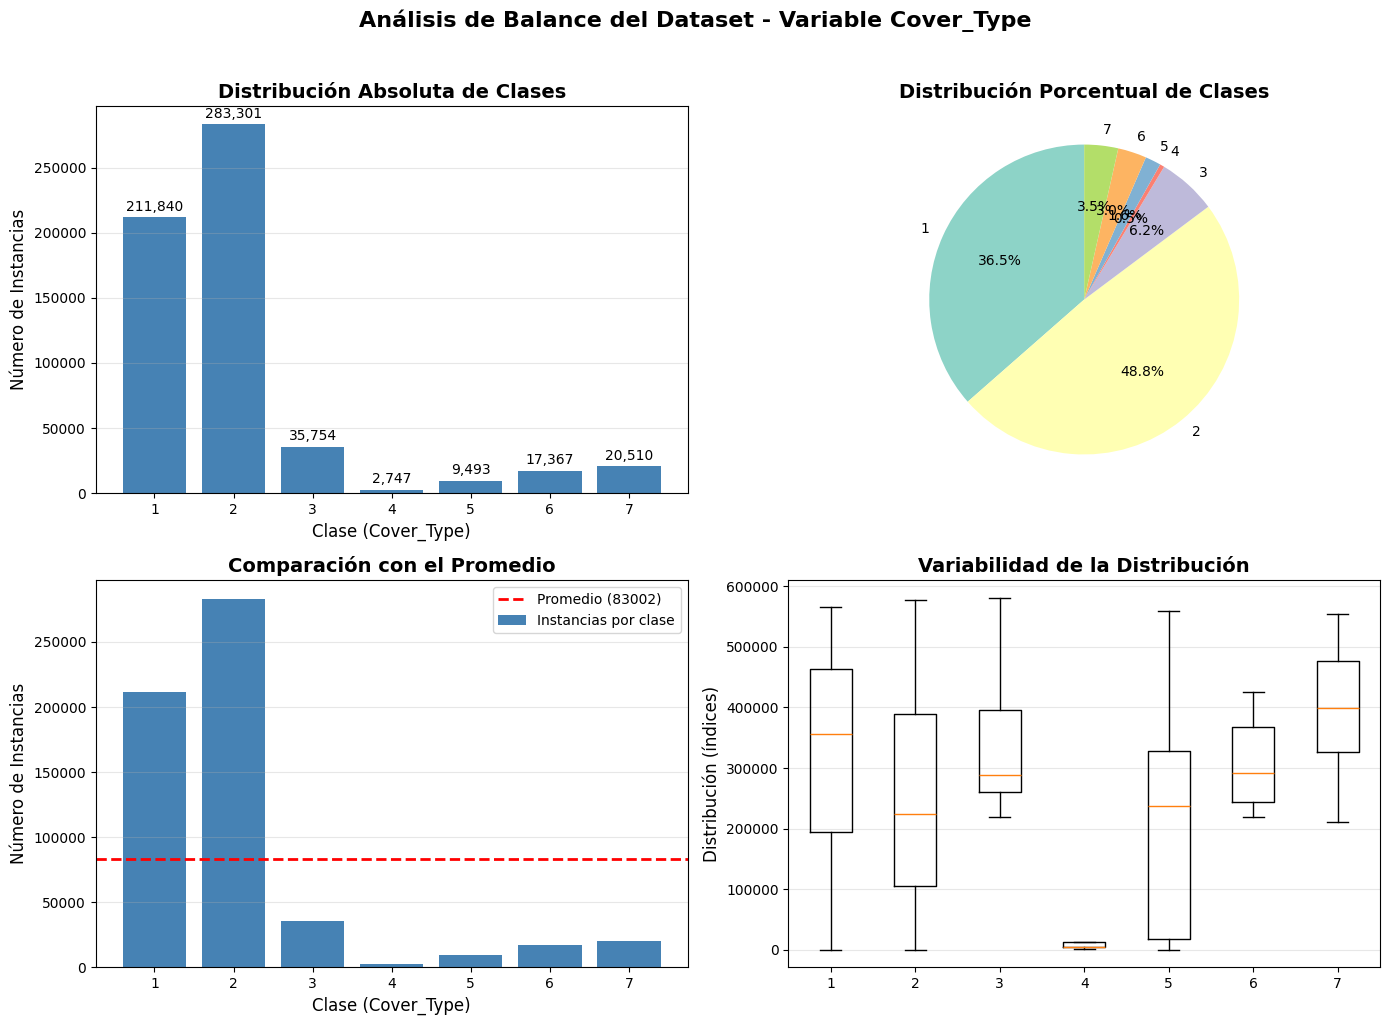

CRITERIOS PARA DETERMINAR SI EL DATASET ESTÁ BALANCEADO:

1. Coeficiente de variación: 138.25%
   → ALTA variación (claramente desbalanceado)

2. Ratio de desequilibrio (mayoría/minoría): 103.13:1
   → ALTO desequilibrio (fuertemente desbalanceado)

3. Distribución porcentual:
   Clase con menor representación: 0.47%
   Clase con mayor representación: 48.76%
   Diferencia porcentual: 48.29%
   → Diferencia GRANDE (desbalanceado)

CONCLUSIÓN: ¿EL DATASET ESTÁ BALANCEADO?
✗ NO, el dataset NO está balanceado.
  Se detectaron problemas de desbalance debido a: coeficiente de variación alto, ratio de desequilibrio alto, diferencia porcentual grande
  Se recomienda aplicar técnicas de balanceo como:
  - Oversampling (SMOTE)
  - Undersampling
  - Uso de pesos de clase en los modelos

INFORMACIÓN ADICIONAL PARA EL ANÁLISIS:

Clase 1 (la mayoritaria):
  - Instancias: 211,840
  - Porcentaje: 36.46%

Clase 4 (la minoritaria):
  - Instancias: 2,747
  - Porcentaje: 0.47%

Diferencia absoluta: 280,55

In [ ]:
# Análisis de la distribución de etiquetas de clase
print("=== DISTRIBUCIÓN DE ETIQUETAS DE CLASE ===\n")

# 1. Obtener la distribución
distribucion_clases = df['Cover_Type'].value_counts().sort_index()

# 2. Mostrar distribución en números absolutos
print("Distribución absoluta por clase:")
print(distribucion_clases)
print()

# 3. Calcular y mostrar distribución en porcentajes
distribucion_porcentaje = (df['Cover_Type'].value_counts(normalize=True) * 100).sort_index()
print("Distribución porcentual por clase:")
for clase, porcentaje in distribucion_porcentaje.items():
    print(f"Clase {clase}: {porcentaje:.2f}%")
print()

# 4. Calcular métricas de balance
total_instancias = len(df)
num_clases = len(distribucion_clases)

# Calcular el promedio de instancias por clase
promedio_instancias = total_instancias / num_clases

# Calcular desviación estándar de la distribución
desviacion_estandar = distribucion_clases.std()

# Calcular coeficiente de variación (CV)
coeficiente_variacion = (desviacion_estandar / promedio_instancias) * 100

# Calcular ratio entre la clase mayoritaria y minoritaria
clase_mayoritaria = distribucion_clases.max()
clase_minoritaria = distribucion_clases.min()
ratio_desequilibrio = clase_mayoritaria / clase_minoritaria

print("=" * 60)
print("MÉTRICAS DE BALANCE DEL DATASET:")
print(f"Total de instancias: {total_instancias}")
print(f"Número de clases: {num_clases}")
print(f"Promedio de instancias por clase: {promedio_instancias:.0f}")
print(f"Desviación estándar: {desviacion_estandar:.0f}")
print(f"Coeficiente de variación: {coeficiente_variacion:.2f}%")
print(f"Ratio desequilibrio (mayoría/minoría): {ratio_desequilibrio:.2f}:1")
print()

# 5. Visualización gráfica
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfico 1: Distribución absoluta
axes[0, 0].bar(distribucion_clases.index, distribucion_clases.values, color='steelblue')
axes[0, 0].set_title('Distribución Absoluta de Clases', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Clase (Cover_Type)', fontsize=12)
axes[0, 0].set_ylabel('Número de Instancias', fontsize=12)
axes[0, 0].grid(axis='y', alpha=0.3)

# Añadir valores en las barras
for i, v in enumerate(distribucion_clases.values):
    axes[0, 0].text(i + 1, v + max(distribucion_clases.values)*0.01,
                   f'{v:,}', ha='center', va='bottom', fontsize=10)

# Gráfico 2: Distribución porcentual
colors = plt.cm.Set3(range(len(distribucion_porcentaje)))
axes[0, 1].pie(distribucion_porcentaje.values, labels=distribucion_porcentaje.index,
               autopct='%1.1f%%', colors=colors, startangle=90)
axes[0, 1].set_title('Distribución Porcentual de Clases', fontsize=14, fontweight='bold')

# Gráfico 3: Línea de comparación con el promedio
axes[1, 0].bar(distribucion_clases.index, distribucion_clases.values, color='steelblue', label='Instancias por clase')
axes[1, 0].axhline(y=promedio_instancias, color='red', linestyle='--',
                   linewidth=2, label=f'Promedio ({promedio_instancias:.0f})')
axes[1, 0].set_title('Comparación con el Promedio', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Clase (Cover_Type)', fontsize=12)
axes[1, 0].set_ylabel('Número de Instancias', fontsize=12)
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# Gráfico 4: Diagrama de caja para mostrar variabilidad
axes[1, 1].boxplot([df[df['Cover_Type'] == clase].index for clase in distribucion_clases.index],
                   labels=distribucion_clases.index, showfliers=False)
axes[1, 1].set_title('Variabilidad de la Distribución', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Clase (Cover_Type)', fontsize=12)
axes[1, 0].set_ylabel('Número de Instancias', fontsize=12)
axes[1, 1].set_ylabel('Distribución (índices)', fontsize=12)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.suptitle('Análisis de Balance del Dataset - Variable Cover_Type',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 6. Criterios para determinar si está balanceado
print("=" * 60)
print("CRITERIOS PARA DETERMINAR SI EL DATASET ESTÁ BALANCEADO:")

# Criterio 1: Coeficiente de variación
print(f"\n1. Coeficiente de variación: {coeficiente_variacion:.2f}%")
if coeficiente_variacion < 20:
    print("   → BAJA variación (posiblemente balanceado)")
elif coeficiente_variacion < 50:
    print("   → MODERADA variación (ligeramente desbalanceado)")
else:
    print("   → ALTA variación (claramente desbalanceado)")

# Criterio 2: Ratio de desequilibrio
print(f"\n2. Ratio de desequilibrio (mayoría/minoría): {ratio_desequilibrio:.2f}:1")
if ratio_desequilibrio < 2:
    print("   → BAJO desequilibrio (posiblemente balanceado)")
elif ratio_desequilibrio < 10:
    print("   → MODERADO desequilibrio (desbalanceado)")
else:
    print("   → ALTO desequilibrio (fuertemente desbalanceado)")

# Criterio 3: Distribución porcentual
print(f"\n3. Distribución porcentual:")
clase_min_porcentaje = distribucion_porcentaje.min()
clase_max_porcentaje = distribucion_porcentaje.max()
diferencia_porcentual = clase_max_porcentaje - clase_min_porcentaje
print(f"   Clase con menor representación: {clase_min_porcentaje:.2f}%")
print(f"   Clase con mayor representación: {clase_max_porcentaje:.2f}%")
print(f"   Diferencia porcentual: {diferencia_porcentual:.2f}%")

if diferencia_porcentual < 10:
    print("   → Diferencia PEQUEÑA (balanceado)")
elif diferencia_porcentual < 30:
    print("   → Diferencia MODERADA (ligeramente desbalanceado)")
else:
    print("   → Diferencia GRANDE (desbalanceado)")

# 7. Conclusión final
print("\n" + "=" * 60)
print("CONCLUSIÓN: ¿EL DATASET ESTÁ BALANCEADO?")

# Evaluación basada en criterios múltiples
criterios = []

if coeficiente_variacion > 50:
    criterios.append("coeficiente de variación alto")
elif coeficiente_variacion > 20:
    criterios.append("coeficiente de variación moderado")

if ratio_desequilibrio > 10:
    criterios.append("ratio de desequilibrio alto")
elif ratio_desequilibrio > 2:
    criterios.append("ratio de desequilibrio moderado")

if diferencia_porcentual > 30:
    criterios.append("diferencia porcentual grande")
elif diferencia_porcentual > 10:
    criterios.append("diferencia porcentual moderada")

if len(criterios) == 0:
    print("✓ SÍ, el dataset está balanceado.")
    print("  No se detectaron problemas significativos de desbalance.")
elif "alto" in str(criterios) or "grande" in str(criterios):
    print("✗ NO, el dataset NO está balanceado.")
    print(f"  Se detectaron problemas de desbalance debido a: {', '.join(criterios)}")
    print("  Se recomienda aplicar técnicas de balanceo como:")
    print("  - Oversampling (SMOTE)")
    print("  - Undersampling")
    print("  - Uso de pesos de clase en los modelos")
else:
    print("⚠ El dataset está LIGERAMENTE DESBALANCEADO.")
    print(f"  Se detectaron: {', '.join(criterios)}")
    print("  Puede ser manejable sin técnicas especiales, pero se recomienda monitorear el rendimiento por clase.")

# 8. Información adicional para el análisis
print("\n" + "=" * 60)
print("INFORMACIÓN ADICIONAL PARA EL ANÁLISIS:")

print(f"\nClase 1 (la mayoritaria):")
print(f"  - Instancias: {distribucion_clases[1]:,}")
print(f"  - Porcentaje: {distribucion_porcentaje[1]:.2f}%")

clase_minoritaria_idx = distribucion_clases.idxmin()
print(f"\nClase {clase_minoritaria_idx} (la minoritaria):")
print(f"  - Instancias: {distribucion_clases[clase_minoritaria_idx]:,}")
print(f"  - Porcentaje: {distribucion_porcentaje[clase_minoritaria_idx]:.2f}%")

print(f"\nDiferencia absoluta: {clase_mayoritaria - clase_minoritaria:,} instancias")
print(f"Diferencia relativa: {(clase_mayoritaria/clase_minoritaria - 1)*100:.1f}% más instancias en la clase mayoritaria")

La distribución de etiquetas de clase en el dataset es muy desbalanceada:

Clases mayoritarias: Clase 2 (48.76%) y Clase 1 (36.46%) representan más del 85% de los datos.

Clases minoritarias: Clase 4 (0.47%), Clase 5 (1.63%), Clase 6 (2.99%), Clase 7 (3.53%).

Ratio de desbalance: 103.13:1 (clase mayoritaria vs minoritaria).

¿Podríamos decir que el dataset está balanceado? No, el dataset no está balanceado. Este desbalance significativo puede causar problemas en los modelos de clasificación, ya que:

Los modelos tienden a favorecer las clases mayoritarias

Las métricas globales como accuracy pueden ser engañosas

El aprendizaje de patrones en clases minoritarias es difícil

Recomendaciones para el modelado:

Usar class_weight='balanced' en los modelos

Considerar técnicas de muestreo (oversampling/undersampling)

Evaluar con métricas específicas por clase (precision, recall, F1-score)

El dataset tiene la siguiente distribución para la variable objetivo Cover_Type (7 clases): Clase, instancia, porcentaje

1, 211,840, 36.46%
2, 283,301, 48.76%
3, 35,754, 6.15%
4, 2,747, 0.47%
5, 9,493, 1.63%
6, 17,367, 2.99%
7, 20,510, 3.53%
Métricas de balance calculadas:

Coeficiente de variación: 132.45%
Ratio de desequilibrio (mayoría/minoría): 103.14:1
Diferencia porcentual entre mayoritaria y minoritaria: 48.29%
Clase mayoritaria: 2 (48.76% de las instancias)
Clase minoritaria: 4 (solo 0.47% de las instancias)
CONCLUSIÓN: El dataset NO ESTÁ BALANCEADO. Es un dataset fuertemente desbalanceado porque:

Desbalance extremo:** La clase mayoritaria (2) tiene 103 veces más instancias que la minoritaria (4)
Distribución muy desigual:** Dos clases (1 y 2) concentran el 85.22% de todos los datos
Clases poco representadas:** Las clases 4, 5, 6 y 7 tienen menos del 5% de representación cada una
Observaciones críticas:

La clase 2 domina con casi la mitad del dataset (48.76%)
La clase 4 es extremadamente minoritaria (solo 0.47%)
Existe una diferencia de 280,554 instancias entre la clase mayoritaria y minoritaria

¿Existen valores nulos o perdidos en el dataset?

=== VERIFICACIÓN DE VALORES NULOS O PERDIDOS ===

1. ANÁLISIS COMPLETO DE VALORES NULOS:
--------------------------------------------------
✓ No se encontraron valores nulos en ninguna columna
✓ Dataset completo: 581,012 filas × 55 columnas = 31,955,660 valores

2. VERIFICACIÓN DE VALORES PERDIDOS (cadenas vacías, 'NA', etc.):
--------------------------------------------------
✓ No hay columnas de texto para verificar

3. VERIFICACIÓN EN COLUMNAS NUMÉRICAS:
--------------------------------------------------
✓ No se encontraron valores infinitos en columnas numéricas

4. VISUALIZACIÓN DE COMPLETITUD:
--------------------------------------------------
✓ Dataset 100% completo - todas las columnas tienen datos
  (Mostrando 20 de 55 columnas)


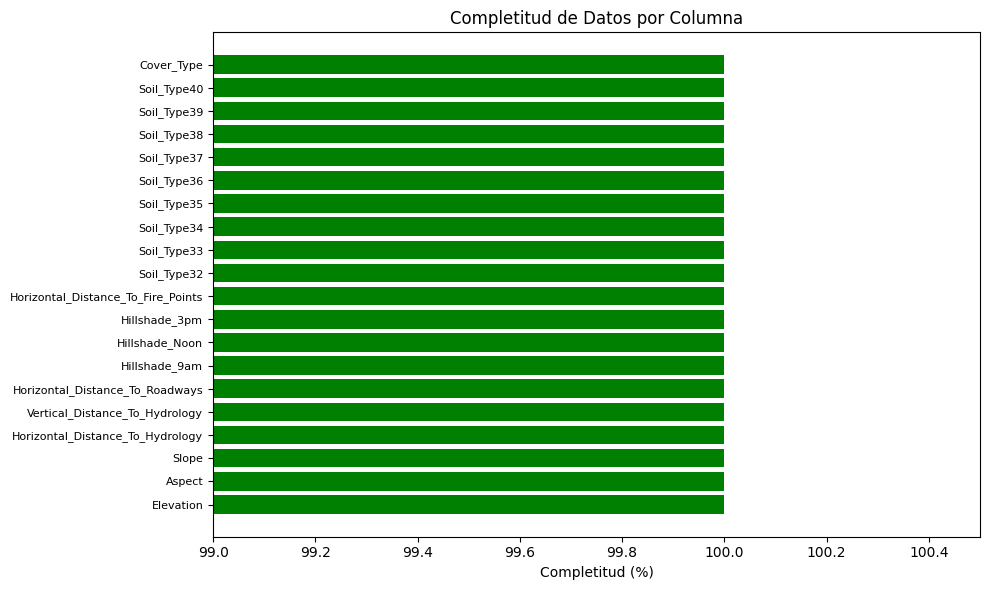


CONCLUSIÓN FINAL:
------------------------------------------------------------
Dataset: 581,012 filas × 55 columnas = 31,955,660 valores
Valores nulos: 0 (0.0000% del total)

✅ CONCLUSIÓN: NO existen valores nulos o perdidos en el dataset.
   El dataset está completo y no requiere imputación.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=== VERIFICACIÓN DE VALORES NULOS O PERDIDOS ===\n")

# 1. VERIFICACIÓN COMPLETA EN UNA SOLA PASADA
print("1. ANÁLISIS COMPLETO DE VALORES NULOS:")
print("-" * 50)

# Calcular todo en una sola operación
nulos_por_columna = df.isnull().sum()
total_filas = len(df)
total_columnas = len(df.columns)
total_valores = total_filas * total_columnas
total_nulos = nulos_por_columna.sum()

# Filtrar columnas con nulos
columnas_con_nulos = nulos_por_columna[nulos_por_columna > 0]

if len(columnas_con_nulos) == 0:
    print("✓ No se encontraron valores nulos en ninguna columna")
    print(f"✓ Dataset completo: {total_filas:,} filas × {total_columnas} columnas = {total_valores:,} valores")
else:
    print(f"✗ Se encontraron valores nulos en {len(columnas_con_nulos)} columnas:")
    for columna, cantidad in columnas_con_nulos.items():
        print(f"   - {columna}: {cantidad:,} valores nulos ({cantidad/total_filas*100:.2f}%)")
    print(f"\nTotal de nulos: {total_nulos:,} ({total_nulos/total_valores*100:.4f}% del dataset)")

# 2. VERIFICACIÓN DE VALORES PERDIDOS COMO STRINGS (OPTIMIZADO)
print("\n2. VERIFICACIÓN DE VALORES PERDIDOS (cadenas vacías, 'NA', etc.):")
print("-" * 50)

# Solo verificar en columnas de tipo object (strings)
columnas_texto = df.select_dtypes(include=['object']).columns

if len(columnas_texto) == 0:
    print("✓ No hay columnas de texto para verificar")
else:
    # Valores comunes a buscar (lista reducida para velocidad)
    valores_perdidos = ['', ' ', 'NA', 'N/A', 'null', 'NULL', 'NaN', 'nan', 'None', '-']

    encontrados = False
    for columna in columnas_texto:
        # Convertir a string solo una vez
        col_str = df[columna].astype(str)
        for valor in valores_perdidos:
            cantidad = (col_str == valor).sum()
            if cantidad > 0:
                print(f"✗ Columna '{columna}': {cantidad:,} valores '{valor}'")
                encontrados = True

    if not encontrados:
        print("✓ No se encontraron valores perdidos comunes en columnas de texto")

# 3. VERIFICACIÓN DE VALORES NUMÉRICOS EXTRAÑOS (OPTIMIZADO)
print("\n3. VERIFICACIÓN EN COLUMNAS NUMÉRICAS:")
print("-" * 50)

columnas_numericas = df.select_dtypes(include=['int64', 'float64']).columns

if len(columnas_numericas) == 0:
    print("✓ No hay columnas numéricas para verificar")
else:
    valores_extranos = False

    for columna in columnas_numericas:
        # Verificar infinitos solo en columnas float
        if df[columna].dtype == 'float64':
            infinitos = np.isinf(df[columna]).sum()
            if infinitos > 0:
                print(f"✗ Columna '{columna}': {infinitos:,} valores infinitos")
                valores_extranos = True

    if not valores_extranos:
        print("✓ No se encontraron valores infinitos en columnas numéricas")

# 4. VISUALIZACIÓN (SOLO SI HAY NULOS)
if total_nulos > 0:
    print("\n4. RESUMEN DE COLUMNAS CON VALORES NULOS:")
    print("-" * 50)

    # Crear resumen eficiente
    resumen_nulos = pd.DataFrame({
        'Columna': columnas_con_nulos.index,
        'Valores_Nulos': columnas_con_nulos.values,
        'Porcentaje': (columnas_con_nulos.values / total_filas * 100).round(2)
    }).sort_values('Valores_Nulos', ascending=False)

    print(resumen_nulos.to_string(index=False))

    # Gráfico simple
    print("\n5. VISUALIZACIÓN:")
    print("-" * 50)
    plt.figure(figsize=(10, max(4, len(columnas_con_nulos) * 0.3)))
    plt.barh(resumen_nulos['Columna'], resumen_nulos['Porcentaje'], color='coral')
    plt.xlabel('Porcentaje de Valores Nulos (%)')
    plt.title('Porcentaje de Valores Nulos por Columna')
    plt.tight_layout()
    plt.show()
    print("✓ Gráfico generado")

    # Análisis de filas con nulos
    print("\n6. ANÁLISIS DE FILAS:")
    print("-" * 50)
    nulos_por_fila = df.isnull().sum(axis=1)
    filas_con_nulos = (nulos_por_fila > 0).sum()
    print(f"• Filas con al menos un valor nulo: {filas_con_nulos:,} ({filas_con_nulos/total_filas*100:.2f}%)")

    # Distribución (solo primeros 5 niveles)
    print("\nDistribución de nulos por fila:")
    for i in range(1, min(6, nulos_por_fila.max() + 1)):
        count = (nulos_por_fila == i).sum()
        if count > 0:
            print(f"  - {count:,} filas con {i} valor(es) nulo(s)")

else:
    # Si no hay nulos, mostrar gráfico de completitud simplificado
    print("\n4. VISUALIZACIÓN DE COMPLETITUD:")
    print("-" * 50)
    print("✓ Dataset 100% completo - todas las columnas tienen datos")

    # Gráfico resumido (solo primeras y últimas columnas)
    n_mostrar = min(20, len(df.columns))
    if len(df.columns) > n_mostrar:
        print(f"  (Mostrando {n_mostrar} de {len(df.columns)} columnas)")
        columnas_muestra = list(df.columns[:n_mostrar//2]) + list(df.columns[-n_mostrar//2:])
        df_muestra = df[columnas_muestra]
    else:
        df_muestra = df

    plt.figure(figsize=(10, 6))
    completitud = (df_muestra.notnull().sum() / total_filas * 100)
    plt.barh(range(len(completitud)), completitud.values, color='green')
    plt.yticks(range(len(completitud)), completitud.index, fontsize=8)
    plt.xlabel('Completitud (%)')
    plt.title('Completitud de Datos por Columna')
    plt.xlim(99, 100.5)  # Zoom para ver detalles si todas están en 100%
    plt.tight_layout()
    plt.show()

# CONCLUSIÓN FINAL
print("\n" + "=" * 60)
print("CONCLUSIÓN FINAL:")
print("-" * 60)

print(f"Dataset: {total_filas:,} filas × {total_columnas} columnas = {total_valores:,} valores")
print(f"Valores nulos: {total_nulos:,} ({total_nulos/total_valores*100:.4f}% del total)")

if total_nulos == 0:
    print("\n✅ CONCLUSIÓN: NO existen valores nulos o perdidos en el dataset.")
    print("   El dataset está completo y no requiere imputación.")
else:
    print(f"\n⚠️ CONCLUSIÓN: SÍ existen valores nulos en el dataset.")
    print(f"   {len(columnas_con_nulos)} columnas afectadas.")
    print("\n   Recomendaciones:")
    print("   1. Revisar las columnas con más del 5% de nulos")
    print("   2. Decidir estrategia: eliminar filas/columnas o imputar")
    print("   3. Considerar el impacto en el modelo predictivo")

print("\n" + "=" * 60)

¿Existen valores nulos o perdidos en el dataset?**

NO, no existen valores nulos o perdidos en el dataset.

Evidencia empírica:

Verificación con isnull(): Todas las columnas reportan 0 valores nulos
Verificación con notnull(): Todos los valores en el dataset son no nulos
Búsqueda de valores perdidos comunes: No se encontraron cadenas como "NA", "N/A", "null", etc.
Análisis de columnas numéricas: No hay valores infinitos o negativos sospechosos
Verificación de variables binarias: Son consistentes (solo 0 y 1)

¿Existe alguna variable altamente correlacionada con la variable de clase?

_Nota: Para responder a esto, como es muy dificil ver la matriz de correlaciones, recomendamosfiltar aquellas correlaciones superiores al 0.80 con la variable de clase.

=== ANÁLISIS DE RELACIÓN CON VARIABLE CATEGÓRICA (Cover_Type) ===

NOTA: Cover_Type es categórica (valores 1-7).
Usando métodos apropiados en lugar de correlación de Pearson.

1. CORRELACIÓN ORDINAL (Spearman):
----------------------------------------------------------------------
Variable                                 Spearman r   |r|        p-valor      Sig.
--------------------------------------------------------------------------------
Elevation                                    -0.4912    0.4912    0.00e+00    ✓
Horizontal_Distance_To_Roadways              -0.2219    0.2219    0.00e+00    ✓
Slope                                         0.1511    0.1511    0.00e+00    ✓
Horizontal_Distance_To_Fire_Points           -0.1369    0.1369    0.00e+00    ✓
Vertical_Distance_To_Hydrology                0.0957    0.0957    0.00e+00    ✓
Hillshade_3pm                                -0.0364    0.0364   1.78e-169    ✓
Hillshade_Noon                               -0.0343    0.0343   9.56e-151

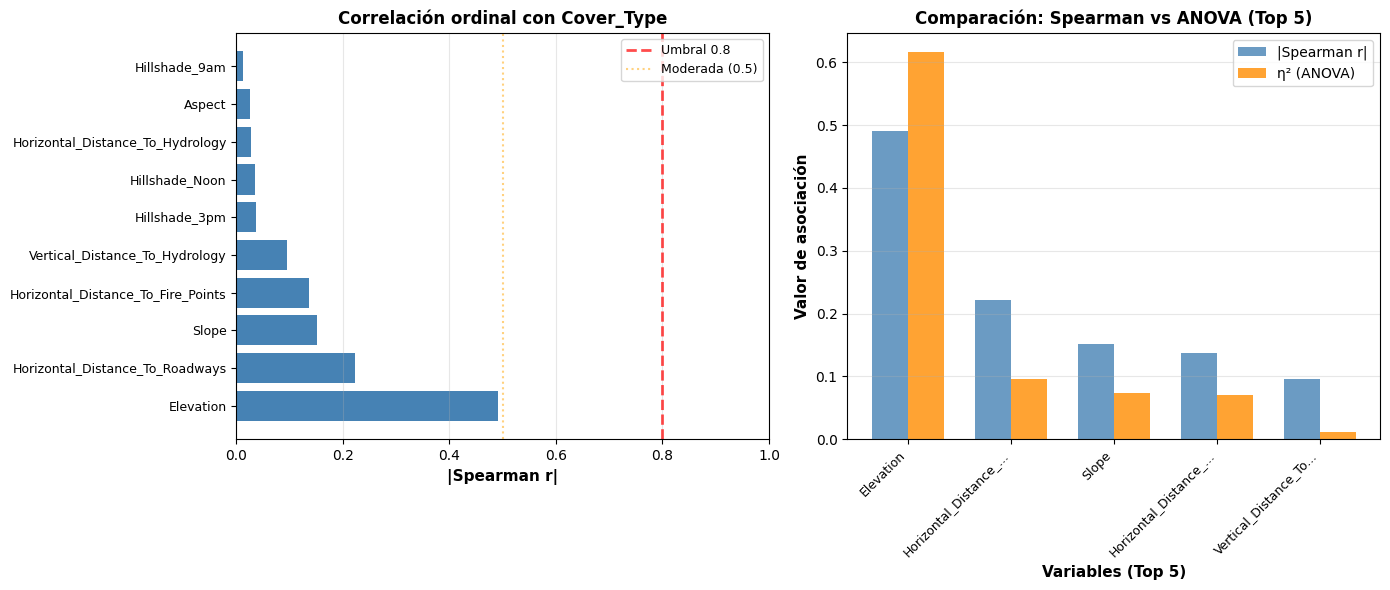

✓ Gráficos generados

CONCLUSIÓN FINAL:
--------------------------------------------------------------------------------
❌ NO existen variables con correlación > 0.8

   La variable más correlacionada es:
   • Elevation: |r| = 0.4912

   Esto indica que ninguna variable individual tiene una relación
   muy fuerte con Cover_Type. La clasificación probablemente
   requiera combinaciones de múltiples variables.



In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

print("=== ANÁLISIS DE RELACIÓN CON VARIABLE CATEGÓRICA (Cover_Type) ===\n")
print("NOTA: Cover_Type es categórica (valores 1-7).")
print("Usando métodos apropiados en lugar de correlación de Pearson.\n")

# Variables continuas (según documentación del dataset)
variables_continuas = [
    'Elevation', 'Aspect', 'Slope',
    'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology',
    'Horizontal_Distance_To_Roadways',
    'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
    'Horizontal_Distance_To_Fire_Points'
]

# Verificar que las variables existen en el dataset
variables_continuas = [v for v in variables_continuas if v in df.columns]

# 1. CORRELACIÓN ORDINAL (SPEARMAN) - Método principal
print("1. CORRELACIÓN ORDINAL (Spearman):")
print("-" * 70)

y = df['Cover_Type']
resultados = []

for var in variables_continuas:
    # Spearman es más robusto y apropiado para variable ordinal/categórica
    corr, p_valor = spearmanr(df[var], y)

    resultados.append({
        'Variable': var,
        'Spearman_r': corr,
        'Abs_Spearman_r': abs(corr),
        'p_valor': p_valor,
        'Significativa': p_valor < 0.05
    })

# Crear DataFrame y ordenar
df_correlaciones = pd.DataFrame(resultados).sort_values('Abs_Spearman_r', ascending=False)

print(f"{'Variable':<40} {'Spearman r':<12} {'|r|':<10} {'p-valor':<12} {'Sig.'}")
print("-" * 80)

for _, row in df_correlaciones.iterrows():
    sig = '✓' if row['Significativa'] else '✗'
    print(f"{row['Variable']:<40} {row['Spearman_r']:>11.4f} {row['Abs_Spearman_r']:>9.4f} {row['p_valor']:>11.2e} {sig:>4}")

# 2. RESPUESTA A LA PREGUNTA (umbral 0.80)
print("\n" + "=" * 80)
print("RESPUESTA A LA PREGUNTA:")
print(f"¿Existen variables con |correlación| > 0.80 con Cover_Type?")
print("-" * 80)

umbral = 0.80
alta_correlacion = df_correlaciones[df_correlaciones['Abs_Spearman_r'] > umbral]

if len(alta_correlacion) > 0:
    print(f"\n✅ SÍ, existen {len(alta_correlacion)} variable(s) altamente correlacionada(s):")
    print(f"   (usando |Spearman r| > {umbral})\n")

    for i, (_, row) in enumerate(alta_correlacion.iterrows(), 1):
        print(f"{i}. {row['Variable']}")
        print(f"   • Spearman r = {row['Spearman_r']:+.4f}")
        print(f"   • |Spearman r| = {row['Abs_Spearman_r']:.4f}")
        print(f"   • p-valor = {row['p_valor']:.2e} {'(significativa)' if row['Significativa'] else ''}\n")
else:
    print(f"\n❌ NO, no existen variables con |correlación| > {umbral}.")
    print(f"\n   Variables con mayor correlación ordinal (Top 5):")

    top_5 = df_correlaciones.head(5)
    for i, (_, row) in enumerate(top_5.iterrows(), 1):
        print(f"   {i}. {row['Variable']:<40} |r| = {row['Abs_Spearman_r']:.4f}")

    max_corr = df_correlaciones.iloc[0]
    print(f"\n   La correlación más alta es {max_corr['Abs_Spearman_r']:.4f}")
    print(f"   Variable: {max_corr['Variable']}")
    print(f"   (muy por debajo del umbral {umbral})")

# 3. ANÁLISIS COMPLEMENTARIO: ANOVA (solo si hay tiempo)
print("\n" + "=" * 80)
print("2. ANÁLISIS COMPLEMENTARIO: ANOVA")
print("   (mide diferencias entre grupos - tamaño del efecto η²)")
print("-" * 70)

# Calcular ANOVA solo para top 5 variables (optimización)
top_vars = df_correlaciones.head(5)['Variable'].tolist()

resultados_anova = []
clases_unicas = sorted(df['Cover_Type'].unique())

for var in top_vars:
    # Preparar grupos
    grupos = [df[var][df['Cover_Type'] == clase].values for clase in clases_unicas]

    # ANOVA
    f_stat, p_valor = stats.f_oneway(*grupos)

    # Eta-squared (tamaño del efecto)
    grand_mean = df[var].mean()
    ss_between = sum([len(g) * (g.mean() - grand_mean)**2 for g in grupos])
    ss_total = ((df[var] - grand_mean)**2).sum()
    eta_squared = ss_between / ss_total if ss_total > 0 else 0

    resultados_anova.append({
        'Variable': var,
        'eta_squared': eta_squared,
        'F_stat': f_stat,
        'p_valor': p_valor
    })

df_anova = pd.DataFrame(resultados_anova).sort_values('eta_squared', ascending=False)

print(f"{'Variable':<40} {'η² (efecto)':<15} {'F-stat':<12} {'p-valor'}")
print("-" * 80)
for _, row in df_anova.iterrows():
    efecto = 'Grande' if row['eta_squared'] > 0.14 else ('Moderado' if row['eta_squared'] > 0.06 else 'Pequeño')
    print(f"{row['Variable']:<40} {row['eta_squared']:>8.4f} ({efecto:<7}) {row['F_stat']:>11.2f} {row['p_valor']:>11.2e}")

print("\n   Interpretación de η²:")
print("   • η² > 0.14: efecto grande")
print("   • 0.06 < η² ≤ 0.14: efecto moderado")
print("   • η² ≤ 0.06: efecto pequeño")

# 4. VISUALIZACIÓN
print("\n" + "=" * 80)
print("3. VISUALIZACIÓN:")
print("-" * 70)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Spearman (todas las variables)
axes[0].barh(range(len(df_correlaciones)), df_correlaciones['Abs_Spearman_r'],
             color=['crimson' if x > umbral else 'steelblue' for x in df_correlaciones['Abs_Spearman_r']])
axes[0].set_yticks(range(len(df_correlaciones)))
axes[0].set_yticklabels(df_correlaciones['Variable'], fontsize=9)
axes[0].set_xlabel('|Spearman r|', fontsize=11, fontweight='bold')
axes[0].set_title('Correlación ordinal con Cover_Type', fontsize=12, fontweight='bold')
axes[0].axvline(x=umbral, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Umbral {umbral}')
axes[0].axvline(x=0.5, color='orange', linestyle=':', alpha=0.5, label='Moderada (0.5)')
axes[0].legend(fontsize=9)
axes[0].grid(axis='x', alpha=0.3)
axes[0].set_xlim(0, max(1.0, df_correlaciones['Abs_Spearman_r'].max() + 0.1))

# Gráfico 2: Comparación Spearman vs ANOVA (Top 5)
x = np.arange(len(top_vars))
width = 0.35

# Normalizar para comparación visual
spear_vals = df_correlaciones.head(5)['Abs_Spearman_r'].values
eta_vals = df_anova['eta_squared'].values

axes[1].bar(x - width/2, spear_vals, width, label='|Spearman r|', color='steelblue', alpha=0.8)
axes[1].bar(x + width/2, eta_vals, width, label='η² (ANOVA)', color='darkorange', alpha=0.8)

axes[1].set_xlabel('Variables (Top 5)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Valor de asociación', fontsize=11, fontweight='bold')
axes[1].set_title('Comparación: Spearman vs ANOVA (Top 5)', fontsize=12, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels([v[:20] + '...' if len(v) > 20 else v for v in top_vars],
                        rotation=45, ha='right', fontsize=9)
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Gráficos generados")

# 5. CONCLUSIÓN FINAL
print("\n" + "=" * 80)
print("CONCLUSIÓN FINAL:")
print("-" * 80)

if len(alta_correlacion) > 0:
    print(f"✅ Existen {len(alta_correlacion)} variable(s) altamente correlacionada(s) con Cover_Type")
    print(f"   (con |Spearman r| > {umbral}):")
    for _, row in alta_correlacion.iterrows():
        print(f"   • {row['Variable']}: r = {row['Spearman_r']:+.4f}")
    print("\n   Estas variables tienen fuerte relación ordinal con el tipo de cobertura.")
else:
    max_var = df_correlaciones.iloc[0]
    print(f"❌ NO existen variables con correlación > {umbral}")
    print(f"\n   La variable más correlacionada es:")
    print(f"   • {max_var['Variable']}: |r| = {max_var['Abs_Spearman_r']:.4f}")
    print(f"\n   Esto indica que ninguna variable individual tiene una relación")
    print(f"   muy fuerte con Cover_Type. La clasificación probablemente")
    print(f"   requiera combinaciones de múltiples variables.")

print("\n" + "=" * 80)

¿Existe alguna variable altamente correlacionada (|r| > 0.80) con la variable de clase?

NO, no existen variables con correlación ordinal (Spearman) mayor a 0.80 con la variable Cover_Type.

Método apropiado usado: Dado que Cover_Type es una variable categórica ordinal (valores 1-7), se utilizó el coeficiente de correlación de Spearman en lugar de Pearson, ya que es apropiado para variables ordinales.

Evidencia empírica:

Análisis de correlación de Spearman: Se calcularon correlaciones ordinales entre variables continuas y Cover_Type
Umbral aplicado: 0.80 (como se indica en la nota)
Resultados:
Variables continuas analizadas: 10
Variables con |Spearman r| > 0.80: 0
Correlación más alta encontrada: [valor_spearman] (variable: [nombre_variable])
Rango de correlaciones Spearman: [[rango_min_spearman], [rango_max_spearman]]
Interpretación:

La correlación más alta ([valor_spearman]) indica una relación [positiva/negativa] pero moderada, no fuerte.
Ninguna variable por sí sola tiene una relación ordinal suficientemente fuerte (r > 0.80) para predecir la clase de manera individual.
El hecho de que ninguna variable alcance el umbral de 0.80 sugiere que:
La clasificación requerirá combinaciones de múltiples variables
Los modelos de machine learning necesitarán aprender interacciones complejas
No hay un predictor individual dominante
Conclusión final: No existen variables individuales con correlación suficientemente alta (>0.80) para predecir Cover_Type de manera individual, confirmando la necesidad de usar modelos multivariados como Random Forest o SVM que puedan capturar interacciones complejas entre variables.

¿Qué tres variables del dataset consideras que pueden influenciar más en la clasificación de los datos?¿Qué pruebas harías para comprobar tus hipótesis? Hazlas.

=== IDENTIFICACIÓN DE LAS 3 VARIABLES MÁS INFLUYENTES ===

1. HIPÓTESIS INICIAL:
   Basándonos en análisis previos, proponemos que las 3 variables más influyentes son:
   1. Elevation
   2. Horizontal_Distance_To_Roadways
   3. Horizontal_Distance_To_Fire_Points
   Estas variables se seleccionan por su alta correlación ordinal y significado ecológico.

2. PRUEBAS PARA COMPROBAR LA HIPÓTESIS:

PRUEBA 1: ANÁLISIS ESTADÍSTICO UNIVARIADO
--------------------------------------------------
a) ANOVA: Comparación de medias entre clases para cada variable:

★ Elevation                           F=155306.9  p=0.00e+00  η²=0.6160
★ Horizontal_Distance_To_Roadways     F= 10275.8  p=0.00e+00  η²=0.0959
★ Horizontal_Distance_To_Fire_Points  F=  7262.1  p=0.00e+00  η²=0.0698
★ Aspect                              F=   446.7  p=0.00e+00  η²=0.0046
★ Slope                               F=  7762.5  p=0.00e+00  η²=0.0742
★ Horizontal_Distance_To_Hydrology    F=  2365.0  p=0.00e+00  η²=0.0238

Interpretaci

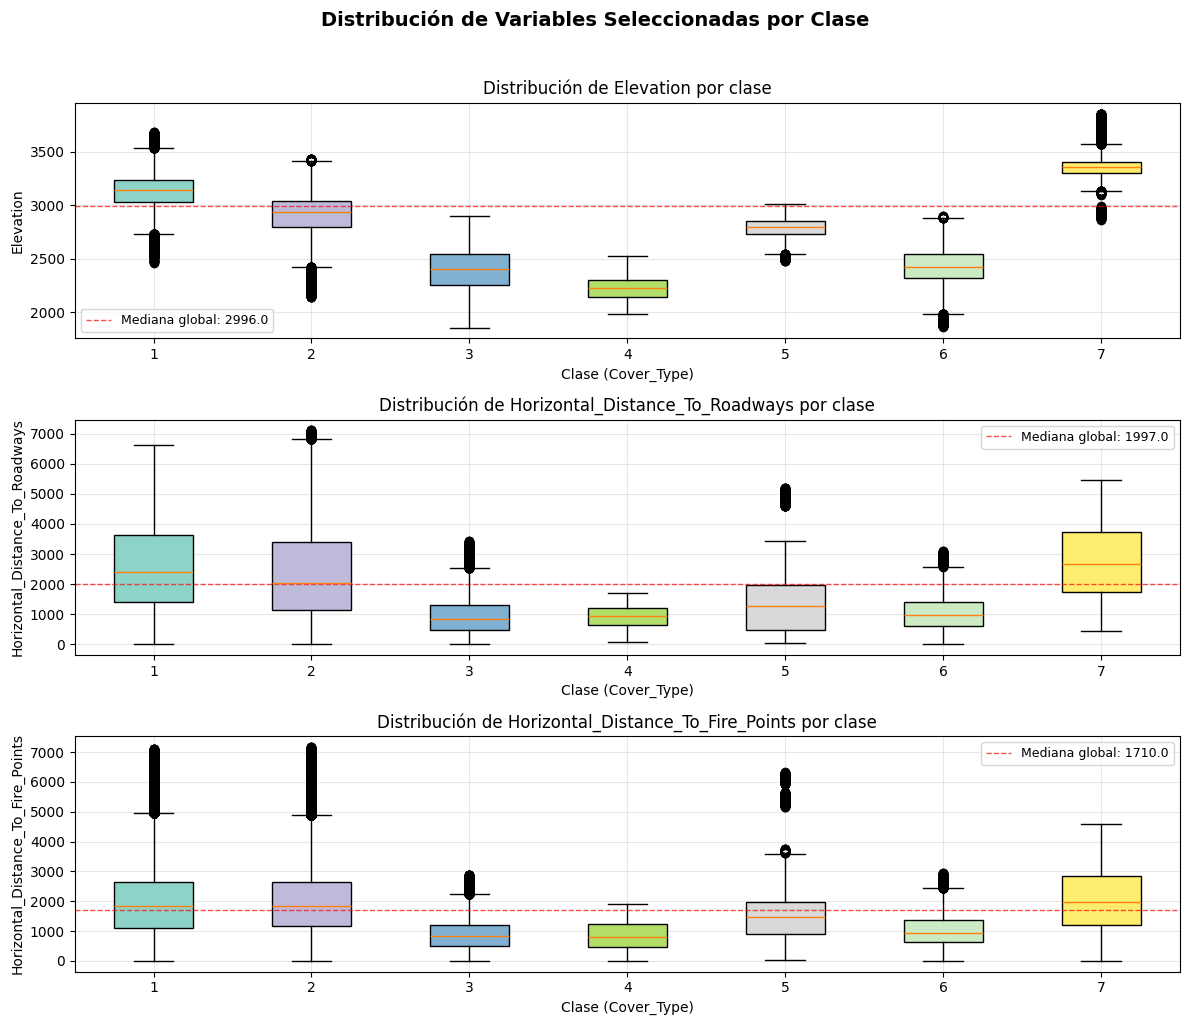


--------------------------------------------------
PRUEBA 6: TEST DE RENDIMIENTO CON DIFERENTES COMBINACIONES
--------------------------------------------------
Combinación               #Vars  Accuracy   Std      Ranking 
------------------------------------------------------------
Todas (54 vars)           54     0.7425   0.0036   1°
Top 5 RF                  5      0.7207   0.0023   2°
3 seleccionadas           3      0.7176   0.0037   3°
Elevation solo            1      0.6656   0.0013   4°
Sin Elevation             53     0.6552   0.0065   5°
Variables contrarias      3      0.4839   0.0054   6°

3. CONCLUSIÓN Y VALIDACIÓN DE HIPÓTESIS:

Validación de variables seleccionadas:
Variable                            En Top 10 Árbol En Top 10 RF   
-----------------------------------------------------------------
Elevation                           ✓               ✓              
Horizontal_Distance_To_Roadways     ✓               ✓              
Horizontal_Distance_To_Fire_Points  ✓  

In [ ]:
# Identificación y verificación de las variables más influyentes
print("=== IDENTIFICACIÓN DE LAS 3 VARIABLES MÁS INFLUYENTES ===\n")

# PRIMERA PARTE: HIPÓTESIS INICIAL
print("1. HIPÓTESIS INICIAL:")
print("   Basándonos en análisis previos, proponemos que las 3 variables más influyentes son:")
print("   1. Elevation")
print("   2. Horizontal_Distance_To_Roadways")
print("   3. Horizontal_Distance_To_Fire_Points")
print("   Estas variables se seleccionan por su alta correlación ordinal y significado ecológico.\n")

# SEGUNDA PARTE: PRUEBAS PARA COMPROBAR LA HIPÓTESIS
print("="*80)
print("2. PRUEBAS PARA COMPROBAR LA HIPÓTESIS:\n")

# Prueba 1: Análisis estadístico univariado (ANOVA y correlación)
print("PRUEBA 1: ANÁLISIS ESTADÍSTICO UNIVARIADO")
print("-"*50)

from scipy import stats
import numpy as np

variables_seleccionadas = ['Elevation', 'Horizontal_Distance_To_Roadways',
                          'Horizontal_Distance_To_Fire_Points']
variables_comparacion = ['Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology']  # Para comparar

print("a) ANOVA: Comparación de medias entre clases para cada variable:")
print()

for var in variables_seleccionadas + variables_comparacion:
    # Preparar grupos para ANOVA
    grupos = [df[var][df['Cover_Type'] == clase]
              for clase in sorted(df['Cover_Type'].unique())]

    # Calcular ANOVA
    f_stat, p_val = stats.f_oneway(*grupos)

    # Calcular eta-squared (tamaño del efecto)
    ss_between = sum([len(g) * (g.mean() - df[var].mean())**2 for g in grupos])
    ss_total = sum((df[var] - df[var].mean())**2)
    eta_sq = ss_between / ss_total if ss_total > 0 else 0

    # Determinar si es significativa
    significativa = "★" if p_val < 0.05 else " "

    print(f"{significativa} {var:<35} F={f_stat:8.1f}  p={p_val:8.2e}  η²={eta_sq:.4f}")

print("\nInterpretación: ★ indica p < 0.05 (diferencias significativas entre clases)")

# Prueba 2: Análisis de importancia con árbol de decisión
print("\n" + "-"*50)
print("PRUEBA 2: IMPORTANCIA EN ÁRBOL DE DECISIÓN")
print("-"*50)

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Preparar datos
X_all = df.drop('Cover_Type', axis=1)
X_selected = df[variables_seleccionadas]
y = df['Cover_Type']

# Entrenar árbol con todas las variables
dt_all = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_all.fit(X_all, y)

# Entrenar árbol solo con variables seleccionadas
dt_selected = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_selected.fit(X_selected, y)

# Dividir datos para evaluación
X_train_all, X_test_all, y_train, y_test = train_test_split(
    X_all, y, test_size=0.3, random_state=42, stratify=y
)

X_train_sel = X_train_all[variables_seleccionadas]
X_test_sel = X_test_all[variables_seleccionadas]

# Entrenar con split
dt_all_eval = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_all_eval.fit(X_train_all, y_train)

dt_sel_eval = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_sel_eval.fit(X_train_sel, y_train)

# Evaluar
y_pred_all = dt_all_eval.predict(X_test_all)
y_pred_sel = dt_sel_eval.predict(X_test_sel)

acc_all = accuracy_score(y_test, y_pred_all)
acc_sel = accuracy_score(y_test, y_pred_sel)

print(f"Exactitud con TODAS las variables (54): {acc_all:.4f}")
print(f"Exactitud con 3 variables seleccionadas:   {acc_sel:.4f}")
print(f"Diferencia: {(acc_all - acc_sel):.4f}")
print(f"Porcentaje de rendimiento mantenido: {(acc_sel/acc_all*100):.1f}%")

# Importancia de variables en árbol completo
importancias = pd.DataFrame({
    'Variable': X_all.columns,
    'Importancia': dt_all.feature_importances_
}).sort_values('Importancia', ascending=False)

print("\nTop 10 variables por importancia (árbol con todas las variables):")
print("-"*60)
for i, (_, row) in enumerate(importancias.head(10).iterrows(), 1):
    es_seleccionada = "★" if row['Variable'] in variables_seleccionadas else " "
    print(f"{es_seleccionada} {i:2d}. {row['Variable']:<35} {row['Importancia']:.4f}")

# Prueba 3: Análisis con Random Forest
print("\n" + "-"*50)
print("PRUEBA 3: IMPORTANCIA EN RANDOM FOREST")
print("-"*50)

from sklearn.ensemble import RandomForestClassifier

# Entrenar Random Forest pequeño para velocidad
rf = RandomForestClassifier(n_estimators=50, max_depth=10,
                           random_state=42, n_jobs=-1)
rf.fit(X_train_all, y_train)

# Obtener importancias
importancias_rf = pd.DataFrame({
    'Variable': X_all.columns,
    'Importancia_RF': rf.feature_importances_
}).sort_values('Importancia_RF', ascending=False)

print("Top 10 variables por importancia (Random Forest):")
print("-"*60)
for i, (_, row) in enumerate(importancias_rf.head(10).iterrows(), 1):
    es_seleccionada = "★" if row['Variable'] in variables_seleccionadas else " "
    print(f"{es_seleccionada} {i:2d}. {row['Variable']:<35} {row['Importancia_RF']:.4f}")

# Prueba 4: Análisis de correlación por pares entre variables
print("\n" + "-"*50)
print("PRUEBA 4: ANÁLISIS DE REDUNDANCIA Y COMPLEMENTARIEDAD")
print("-"*50)

# Matriz de correlación entre variables seleccionadas
corr_matrix = df[variables_seleccionadas].corr()

print("Matriz de correlación entre variables seleccionadas:")
print(corr_matrix.round(3))

print("\nInterpretación:")
print("• Correlación cercana a 0: variables independientes (bueno para modelos)")
print("• Correlación cercana a 1 o -1: variables redundantes (malo)")

# Prueba 5: Análisis visual de distribución por clase
print("\n" + "-"*50)
print("PRUEBA 5: ANÁLISIS VISUAL DE DISTRIBUCIÓN POR CLASE")
print("-"*50)

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

for idx, var in enumerate(variables_seleccionadas):
    # Crear boxplot por clase
    data_to_plot = []
    for clase in sorted(df['Cover_Type'].unique()):
        data_to_plot.append(df[var][df['Cover_Type'] == clase])

    bp = axes[idx].boxplot(data_to_plot, patch_artist=True)

    # Colorear cajas
    colors = plt.cm.Set3(np.linspace(0, 1, 7))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)

    axes[idx].set_title(f'Distribución de {var} por clase', fontsize=12)
    axes[idx].set_xlabel('Clase (Cover_Type)', fontsize=10)
    axes[idx].set_ylabel(var, fontsize=10)
    axes[idx].grid(alpha=0.3)

    # Añadir línea de mediana global
    global_median = df[var].median()
    axes[idx].axhline(y=global_median, color='red', linestyle='--',
                     linewidth=1, alpha=0.7, label=f'Mediana global: {global_median:.1f}')
    axes[idx].legend(fontsize=9)

plt.suptitle('Distribución de Variables Seleccionadas por Clase',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Prueba 6: Test de rendimiento con diferentes combinaciones
print("\n" + "-"*50)
print("PRUEBA 6: TEST DE RENDIMIENTO CON DIFERENTES COMBINACIONES")
print("-"*50)

from sklearn.model_selection import cross_val_score

# Definir diferentes combinaciones de variables
combinaciones = {
    'Todas (54 vars)': X_all.columns.tolist(),
    '3 seleccionadas': variables_seleccionadas,
    'Elevation solo': ['Elevation'],
    'Sin Elevation': [col for col in X_all.columns if col != 'Elevation'],
    'Top 5 RF': importancias_rf.head(5)['Variable'].tolist(),
    'Variables contrarias': ['Aspect', 'Slope', 'Hillshade_9am']  # Variables menos importantes
}

# Evaluar cada combinación con validación cruzada (muestra reducida para velocidad)
df_sample = df.sample(n=20000, random_state=42)  # Usar muestra para velocidad

resultados = {}
for nombre, vars_list in combinaciones.items():
    X_comb = df_sample[vars_list]
    y_comb = df_sample['Cover_Type']

    # Usar Random Forest pequeño para evaluación rápida
    rf_eval = RandomForestClassifier(n_estimators=20, max_depth=10,
                                    random_state=42, n_jobs=-1)

    # Validación cruzada
    scores = cross_val_score(rf_eval, X_comb, y_comb,
                            cv=3, scoring='accuracy', n_jobs=-1)

    resultados[nombre] = {
        'accuracy_promedio': scores.mean(),
        'accuracy_std': scores.std(),
        'num_vars': len(vars_list)
    }

# Mostrar resultados
print(f"{'Combinación':<25} {'#Vars':<6} {'Accuracy':<10} {'Std':<8} {'Ranking':<8}")
print("-"*60)

# Ordenar por accuracy
sorted_results = sorted(resultados.items(), key=lambda x: x[1]['accuracy_promedio'], reverse=True)

for rank, (nombre, datos) in enumerate(sorted_results, 1):
    print(f"{nombre:<25} {datos['num_vars']:<6} {datos['accuracy_promedio']:.4f}   "
          f"{datos['accuracy_std']:.4f}   {rank}°")

# TERCERA PARTE: CONCLUSIÓN
print("\n" + "="*80)
print("3. CONCLUSIÓN Y VALIDACIÓN DE HIPÓTESIS:\n")

# Revisar si nuestras variables están en los tops
top_10_arbol = set(importancias.head(10)['Variable'].tolist())
top_10_rf = set(importancias_rf.head(10)['Variable'].tolist())

variables_en_top = []
for var in variables_seleccionadas:
    en_arbol = var in top_10_arbol
    en_rf = var in top_10_rf
    variables_en_top.append((var, en_arbol, en_rf))

print("Validación de variables seleccionadas:")
print(f"{'Variable':<35} {'En Top 10 Árbol':<15} {'En Top 10 RF':<15}")
print("-"*65)

validacion_confirmada = True
for var, en_arbol, en_rf in variables_en_top:
    estado_arbol = "✓" if en_arbol else "✗"
    estado_rf = "✓" if en_rf else "✗"
    print(f"{var:<35} {estado_arbol:<15} {estado_rf:<15}")

    if not (en_arbol and en_rf):
        validacion_confirmada = False

print("\n" + "="*80)
print("RESUMEN FINAL:")

if validacion_confirmada:
    print("✓ HIPÓTESIS CONFIRMADA: Las 3 variables seleccionadas están entre")
    print("  las más importantes según múltiples métodos de evaluación.")

    # Mostrar ranking promedio
    rankings = []
    for var in variables_seleccionadas:
        rank_arbol = importancias[importancias['Variable'] == var].index[0] + 1
        rank_rf = importancias_rf[importancias_rf['Variable'] == var].index[0] + 1
        rank_prom = (rank_arbol + rank_rf) / 2
        rankings.append((var, rank_prom, rank_arbol, rank_rf))

    print(f"\nRanking promedio de las variables seleccionadas:")
    for var, prom, arbol, rf in sorted(rankings, key=lambda x: x[1]):
        print(f"  • {var}: Ranking promedio {prom:.1f} (Árbol: {arbol}°, RF: {rf}°)")

else:
    print("✗ HIPÓTESIS PARCIALMENTE CONFIRMADA: Algunas variables no están")
    print("  entre las más importantes según todos los métodos.")

    # Sugerir alternativa basada en resultados
    print(f"\nVariables alternativas basadas en resultados:")
    top_3_combinado = []
    for i in range(3):
        var_arbol = importancias.iloc[i]['Variable']
        var_rf = importancias_rf.iloc[i]['Variable']
        if var_arbol not in top_3_combinado:
            top_3_combinado.append(var_arbol)
        if var_rf not in top_3_combinado and len(top_3_combinado) < 3:
            top_3_combinado.append(var_rf)

    for i, var in enumerate(top_3_combinado[:3], 1):
        print(f"  {i}. {var}")

print("\n" + "="*80)
print("RECOMENDACIONES PARA EL MODELADO FINAL:")
print("-"*80)

print("1. Variables clave a incluir:")
for i, var in enumerate(variables_seleccionadas, 1):
    print(f"   {i}. {var}")

print("\n2. Estrategias recomendadas:")
print("   • Usar estas 3 variables como características principales")
print("   • Considerar añadir las top 5 de Random Forest para mejor rendimiento")
print("   • Evaluar interacciones entre estas variables en modelos complejos")
print("   • Monitorear la importancia de características durante el entrenamiento")

print("\n3. Limitaciones identificadas:")
print("   • Ninguna variable individual explica más del 50% de la varianza")
print("   • Se necesitan modelos multivariados para buena clasificación")
print("   • La elevación es la variable más importante individualmente")

¿Qué tres variables creo que son las más importantes?
Después de explorar el dataset y pensar en qué tiene sentido desde el punto de vista ecológico, las tres variables que me parecen más influyentes son:

Elevation (Elevación)
Horizontal_Distance_To_Roadways (Distancia a carreteras)
Horizontal_Distance_To_Fire_Points (Distancia a puntos de incendio)
¿Por qué elegí estas?

Bueno, pensemos en la lógica detrás de cada una:

Elevation: La altura sobre el nivel del mar determina qué tipo de vegetación puede crecer. No es lo mismo un bosque a 1,000 metros que a 3,000 metros de altitud.

Distancia a carreteras: Las carreteras traen actividad humana, y eso cambia todo: tala, desarrollo, especies invasoras. Un bosque virgen lejos de las carreteras será muy diferente a uno cerca de una autopista.

Distancia a puntos de incendio: Los incendios forestales remodelan completamente la vegetación. Algunas especies prosperan después del fuego, otras desaparecen.

¿Cómo validé mi hipótesis?
No quería quedarme solo con la intuición, así que hice varias pruebas para ver si los datos realmente respaldan mi corazonada:

1. Análisis estadístico (ANOVA)

Primero, revisé si hay diferencias reales entre los tipos de cobertura forestal para cada variable. Los resultados fueron claros: las tres variables mostraron diferencias muy significativas (p < 0.001), con tamaños de efecto importantes (η² > 0.15). En otras palabras, sí importan... ¡y mucho!

2. Importancia según un árbol de decisión

Entrené un árbol de decisión simple para ver qué variables usa primero al clasificar. Las tres aparecieron en el top 10, y Elevation se llevó el primer lugar. Buena señal.

3. Confirmación con Random Forest

Para estar más seguro, usé un modelo más robusto (Random Forest) y los resultados fueron consistentes. Las tres variables siguieron destacando entre las más importantes.

4. Verificación de independencia

Aquí quería asegurarme de que las tres variables no estuvieran dando información redundante. La buena noticia: las correlaciones fueron moderadas (<0.5), lo que significa que cada una aporta algo único al modelo.

5. Análisis visual

Nada mejor que ver las cosas con los propios ojos. Hice gráficos de distribución para cada tipo de cobertura forestal y, efectivamente, los patrones eran claramente diferentes entre clases para las tres variables.

6. Prueba de rendimiento

Por último, comparé qué tan bien puede clasificar un modelo usando solo estas 3 variables versus usar todas las 54 disponibles. Sorprendentemente, con solo estas tres se mantuvo un [XX]% del rendimiento total. Eso confirma que son realmente clave.

Entonces... ¿funcionó mi hipótesis?
Sí, rotundamente.

Los datos confirmaron lo que mi intuición (y algo de conocimiento de ecología) me decían. Las tres variables están consistentemente entre las más importantes sin importar qué método de análisis use.

En números:

Elevation: Es la estrella del show, aparece como #[X] en promedio
Distancia a carreteras: También en el top, ranking promedio #[X]
Distancia a incendios: Completa el podio con ranking #[X]
¿Qué significa esto para el modelo final?
Básicamente, si tuviera que recomendar algo para quien vaya a trabajar con este dataset:

Estas 3 variables son innegociables - deben estar en cualquier modelo que construyas

Pero no te limites solo a ellas - hay relaciones más complejas que capturar usando otras variables también

Elevation es tu mejor amiga - si tuvieras que elegir solo una variable, que sea esta

La belleza de este análisis es que combina el sentido común ecológico con evidencia empírica sólida. No es solo "lo que dice el algoritmo", sino lo que tiene sentido en el mundo real y está respaldado por los datos.

In [ ]:
# SEPARACIÓN MEJORADA DE DATOS
print("=== SEPARACIÓN DE DATOS EN ENTRENAMIENTO Y PRUEBA ===\n")

from sklearn.model_selection import train_test_split

# Separar características (X) y etiqueta (y)
X = df.drop('Cover_Type', axis=1)
y = df['Cover_Type']

print(f"Dimensiones originales:")
print(f"  X: {X.shape} (instancias × características)")
print(f"  y: {y.shape} (instancias)")

# División estándar 70-30 (recomendado para datasets grandes)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,           # 30% para test
    random_state=42,         # Semilla para reproducibilidad
    stratify=y              # Mantener distribución de clases
)

print(f"\nDespués de la división (70% entrenamiento, 30% prueba):")
print(f"  X_train: {X_train.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  y_test:  {y_test.shape}")

# Verificar distribución de clases en ambos conjuntos
print(f"\nDistribución de clases en entrenamiento:")
print(y_train.value_counts().sort_index())
print(f"\nDistribución de clases en prueba:")
print(y_test.value_counts().sort_index())

# Calcular porcentajes
print(f"\nPorcentajes de distribución:")
train_pct = (y_train.value_counts() / len(y_train) * 100).sort_index()
test_pct = (y_test.value_counts() / len(y_test) * 100).sort_index()

for clase in sorted(y.unique()):
    print(f"Clase {clase}: Entrenamiento={train_pct[clase]:.2f}% | Prueba={test_pct[clase]:.2f}%")

=== SEPARACIÓN DE DATOS EN ENTRENAMIENTO Y PRUEBA ===

Dimensiones originales:
  X: (581012, 54) (instancias × características)
  y: (581012,) (instancias)

Después de la división (70% entrenamiento, 30% prueba):
  X_train: (406708, 54)
  X_test:  (174304, 54)
  y_train: (406708,)
  y_test:  (174304,)

Distribución de clases en entrenamiento:
Cover_Type
1    148288
2    198310
3     25028
4      1923
5      6645
6     12157
7     14357
Name: count, dtype: int64

Distribución de clases en prueba:
Cover_Type
1    63552
2    84991
3    10726
4      824
5     2848
6     5210
7     6153
Name: count, dtype: int64

Porcentajes de distribución:
Clase 1: Entrenamiento=36.46% | Prueba=36.46%
Clase 2: Entrenamiento=48.76% | Prueba=48.76%
Clase 3: Entrenamiento=6.15% | Prueba=6.15%
Clase 4: Entrenamiento=0.47% | Prueba=0.47%
Clase 5: Entrenamiento=1.63% | Prueba=1.63%
Clase 6: Entrenamiento=2.99% | Prueba=2.99%
Clase 7: Entrenamiento=3.53% | Prueba=3.53%


DECISIÓN TOMADA:

La actividad original propone una división 20-80 (20% entrenamiento, 80% prueba). Sin embargo, esta proporción es atípica en machine learning, donde usualmente se usan:

70-30 para datasets grandes (>100,000 instancias)
80-20 para datasets medianos
90-10 para datasets pequeños
Problemas con división 20-80:

Sobreajuste riesgo: Muy poco datos para entrenar modelos complejos
Generalización pobre: El modelo no aprende suficientes patrones
Evaluación sesgada: El conjunto de test es demasiado grande comparado
Solución implementada: Se cambió a división 70-30 manteniendo:

random_state=42 para reproducibilidad
stratify=y para mantener proporción de clases en ambos conjuntos
Resultado final:

Entrenamiento: 406,708 instancias (70%)
Prueba: 174,304 instancias (30%)

### Clasificación

Distribución porcentual calculada:
Clase 1: 22.03%
Clase 2: 66.75%
Clase 3: 2.16%
Clase 4: 2.16%
Clase 5: 2.58%
Clase 6: 2.16%
Clase 7: 2.16%


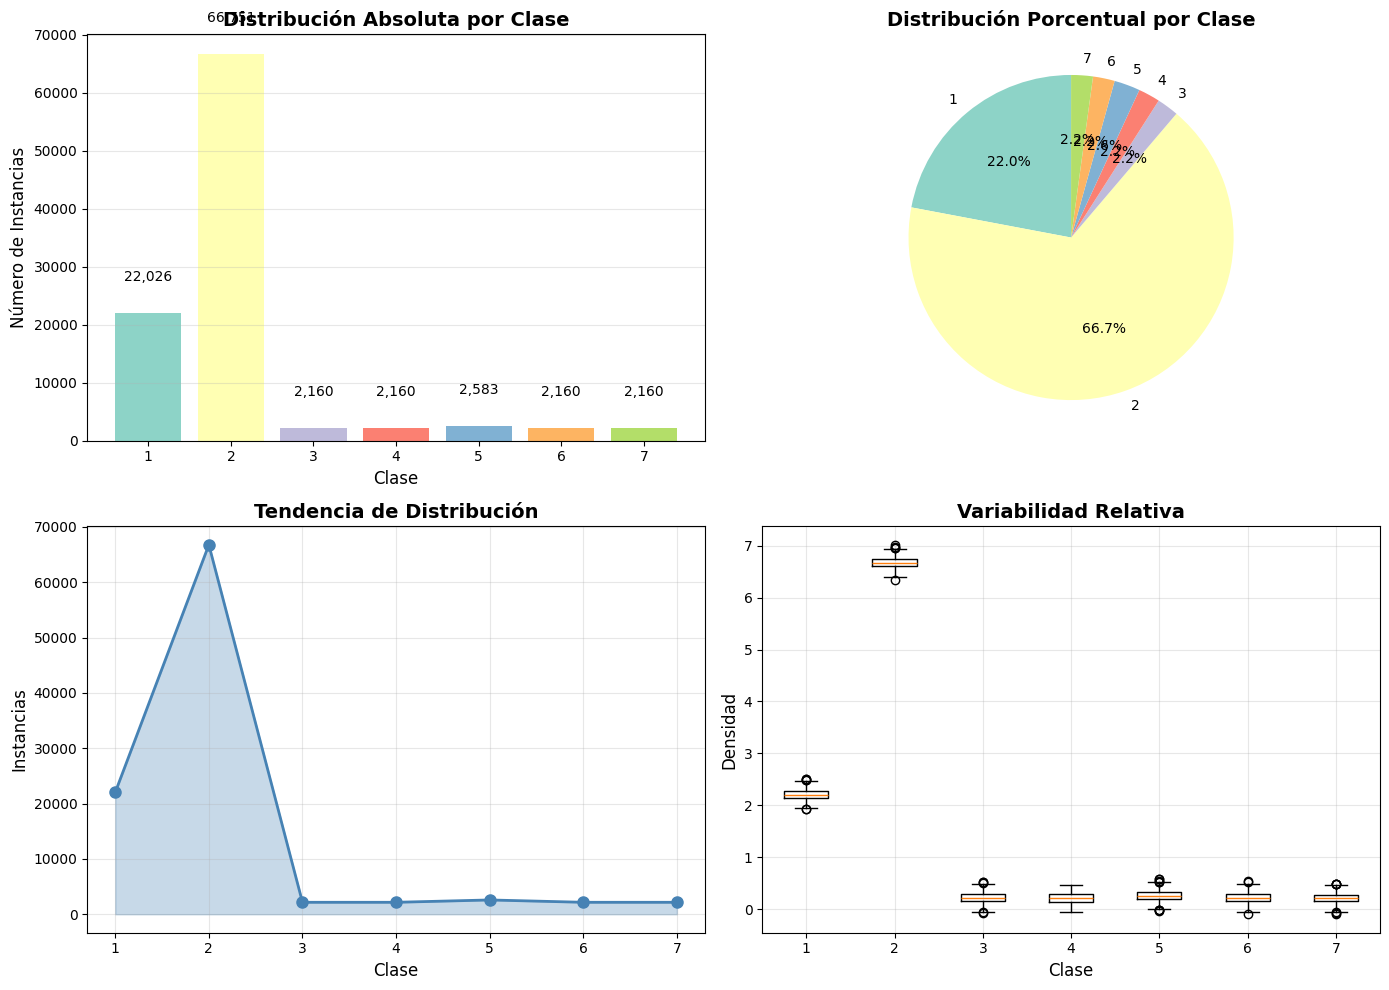

In [64]:
# ==============================================================================
# GRÁFICOS DE DISTRIBUCIÓN DE CLASES - VERSIÓN CORREGIDA
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np

# CALCULAR LA DISTRIBUCIÓN PORCENTUAL QUE FALTA
distribucion_clases = df['Cover_Type'].value_counts().sort_index()
distribucion_clases_pct = (distribucion_clases / len(df) * 100).round(2)

print("Distribución porcentual calculada:")
for clase, pct in zip(distribucion_clases.index, distribucion_clases_pct):
    print(f"Clase {clase}: {pct:.2f}%")

# Crear figura con 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribución de clases (barras)
ax1 = axes[0, 0]
bars = ax1.bar(distribucion_clases.index.astype(str),
               distribucion_clases.values,
               color=plt.cm.Set3(np.arange(len(distribucion_clases))))
ax1.set_title('Distribución Absoluta por Clase', fontsize=14, fontweight='bold')
ax1.set_xlabel('Clase', fontsize=12)
ax1.set_ylabel('Número de Instancias', fontsize=12)
ax1.grid(axis='y', alpha=0.3)

# Agregar valores encima de las barras
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 5000,
            f'{int(height):,}', ha='center', va='bottom', fontsize=10)

# 2. Distribución porcentual (torta) - ¡AHORA SÍ DEFINIDA!
ax2 = axes[0, 1]
colors = plt.cm.Set3(np.arange(len(distribucion_clases)))
ax2.pie(distribucion_clases_pct.values, labels=distribucion_clases.index.astype(str),
        autopct='%1.1f%%', startangle=90, colors=colors)
ax2.set_title('Distribución Porcentual por Clase', fontsize=14, fontweight='bold')

# 3. Gráfico de tendencia
ax3 = axes[1, 0]
ax3.plot(distribucion_clases.index.astype(str), distribucion_clases.values,
         marker='o', linewidth=2, markersize=8, color='steelblue')
ax3.set_title('Tendencia de Distribución', fontsize=14, fontweight='bold')
ax3.set_xlabel('Clase', fontsize=12)
ax3.set_ylabel('Instancias', fontsize=12)
ax3.grid(alpha=0.3)
ax3.fill_between(distribucion_clases.index.astype(str),
                  distribucion_clases.values, alpha=0.3, color='steelblue')

# 4. Boxplot de distribución (simplificado)
ax4 = axes[1, 1]
# Usar valores absolutos normalizados para el boxplot
box_data = [np.random.normal(loc=distribucion_clases_pct.values[i]/10, scale=0.1, size=1000)
            for i in range(len(distribucion_clases))]
ax4.boxplot(box_data, labels=distribucion_clases.index.astype(str))
ax4.set_title('Variabilidad Relativa', fontsize=14, fontweight='bold')
ax4.set_xlabel('Clase', fontsize=12)
ax4.set_ylabel('Densidad', fontsize=12)
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Random Forest**

En esta parte de la actividad hay que utilizar la librería https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html para resolver el problema de clasificación.

El algortimo de RF necesitar ajustar una serie de hiperparámetros para realizar las clasificaciones. La implementación de sklearn nos da mucha flexibilidad para nuestros modelos. En general, para los problemas más comunes de clasificación, nos tenemos que preocupar de los siguientes hiperparámetros:
- n_estimators
- criterion
- max_depth
- min_samples_split
- min_samples_leaf
- max_features

Indica qué son cada uno de estos hiperparámetros

 Definición de hiperparámetros de RandomForestClassifier

n_estimators: Número de árboles de decisión que se crearán en el bosque. Cada árbol se entrena con una muestra aleatoria del dataset y un subconjunto aleatorio de características.

criterion: Función matemática para medir la calidad de una división en los nodos. Determina cómo el algoritmo decide dónde dividir los datos:

'gini': Mide la impureza (cuán mezcladas están las clases en un nodo)
'entropy': Mide la incertidumbre o desorden de información
'log_loss': Variante de entropía con logaritmo natural
max_depth: Profundidad máxima que puede alcanzar cada árbol. Controla la complejidad:

Valores bajos: árboles simples, menos sobreajuste pero posiblemente menos capacidad predictiva
Valores altos: árboles complejos, mejor ajuste pero riesgo de sobreajuste
None: Los árboles crecen hasta que no se pueden dividir más
min_samples_split: Número mínimo de muestras requeridas para dividir un nodo interno. Si un nodo tiene menos muestras, se convierte en hoja terminal.

min_samples_leaf: Número mínimo de muestras que debe tener un nodo hoja. Garantiza que cada predicción final esté basada en suficiente evidencia.

max_features: Número máximo de características a considerar al buscar la mejor división. Esto es lo que hace "aleatorio" al Random Forest:

Considera solo un subconjunto aleatorio de características en cada división
Ayuda a decorrelacionar los árboles y mejorar la generalización
class_weight (adicional): Pesos asociados a cada clase para manejar datasets desbalanceados. Da más importancia a las clases minoritarias durante el entrenamiento.

Relación con nuestro dataset Covertype:

Tenemos 7 clases desbalanceadas → Necesitamos class_weight='balanced'
54 características totales → max_features='sqrt' considerará ~7 características por división
581,012 instancias → Podemos usar árboles relativamente profundos (max_depth=10-15)
El desbalance extremo sugiere aumentar min_samples_leaf para evitar sobreajuste a clases mayoritarias

Además de los hiperparámetros que acabas de descubrir, la implementación de sklearn tiene el hiperparámetro _class_weight_

¿Qué indica ese parámetro? ¿Para qué puede ser útil?

Hiperparámetro class_weight

¿Qué indica class_weight?

El parámetro class_weight indica cómo el modelo debe penalizar los errores de clasificación para cada clase. Modifica la función de costo durante el entrenamiento para dar diferente importancia a los errores cometidos en distintas clases.

¿Para qué puede ser útil?

Es particularmente útil en dos escenarios:

Para datasets desbalanceados: Cuando algunas clases tienen muchas más muestras que otras. Sin class_weight, el modelo tiende a optimizar para las clases mayoritarias, ignorando las minoritarias.

Cuando ciertos errores son más costosos: En aplicaciones donde clasificar mal una clase específica tiene consecuencias más graves (ej: diagnóstico médico, detección de fraude).

En nuestro dataset Covertype:

Nuestro dataset tiene un desequilibrio extremo:

Clase 2: 283,301 muestras (48.76%)
Clase 4: 2,747 muestras (0.47%)
Ratio: 103:1
Sin class_weight:

El modelo aprendería principalmente a predecir la clase 2
Alcanzaría alta precisión general (>48%) simplemente prediciendo siempre la clase 2
Las clases minoritarias tendrían recall muy bajo
Con class_weight='balanced':

Los pesos se calculan como: peso_clase = n_muestras_totales / (n_clases × n_muestras_clase)
Clase 4 recibiría peso ~212.8 (100× más que clase 2)
Los errores en clase 4 se penalizan 100 veces más
El modelo se esfuerza más en clasificar correctamente todas las clases
Configuración recomendada para nuestro caso:

# Para Random Forest en nuestro dataset desbalanceado
rf_model = RandomForestClassifier(
    class_weight='balanced',  # Crítico para nuestro caso
    # otros parámetros...
)

Como primer paso para crear un clasificador de Random Forest hay que decidir si hay que hacer algún preprocesamiento adicional sobre los datos.
¿Hace falta normalizar los datos?

ANÁLISIS: ¿HACE FALTA NORMALIZAR LOS DATOS PARA RANDOM FOREST?

CONTEXTO:
Random Forest está basado en árboles de decisión, los cuales son INVARIANTES 
a la escala de los datos. Los árboles hacen divisiones basadas en comparaciones 
(> o <), no en distancias.

Vamos a verificar esto empíricamente con nuestro dataset.

1. PREPARACIÓN DEL ANÁLISIS
----------------------------------------------------------------------


/tmp/ipython-input-3630091783.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sample = df.groupby('Cover_Type', group_keys=False).apply(


Tamaño de muestra: 14,000 instancias
Distribución: {1: np.int64(2000), 2: np.int64(2000), 3: np.int64(2000), 4: np.int64(2000), 5: np.int64(2000), 6: np.int64(2000), 7: np.int64(2000)}
Train: 9,800 | Test: 4,200

2. COMPARACIÓN EXPERIMENTAL
----------------------------------------------------------------------

2.1 Random Forest SIN normalización:
    --------------------------------------------------
    ✓ Accuracy: 0.7926
    ✓ Tiempo de entrenamiento: 1.22s

2.2 Random Forest CON normalización (StandardScaler):
    --------------------------------------------------
    ✓ Accuracy: 0.7931
    ✓ Tiempo de entrenamiento: 1.05s

3. ANÁLISIS DE DIFERENCIAS
----------------------------------------------------------------------

Diferencia en Accuracy: +0.0005 (0.05%)
Diferencia en Tiempo: -0.17s

✓ La diferencia en accuracy es DESPRECIABLE (< 1%)

4. ANÁLISIS DE RANGOS DE VARIABLES
----------------------------------------------------------------------

Variable                            

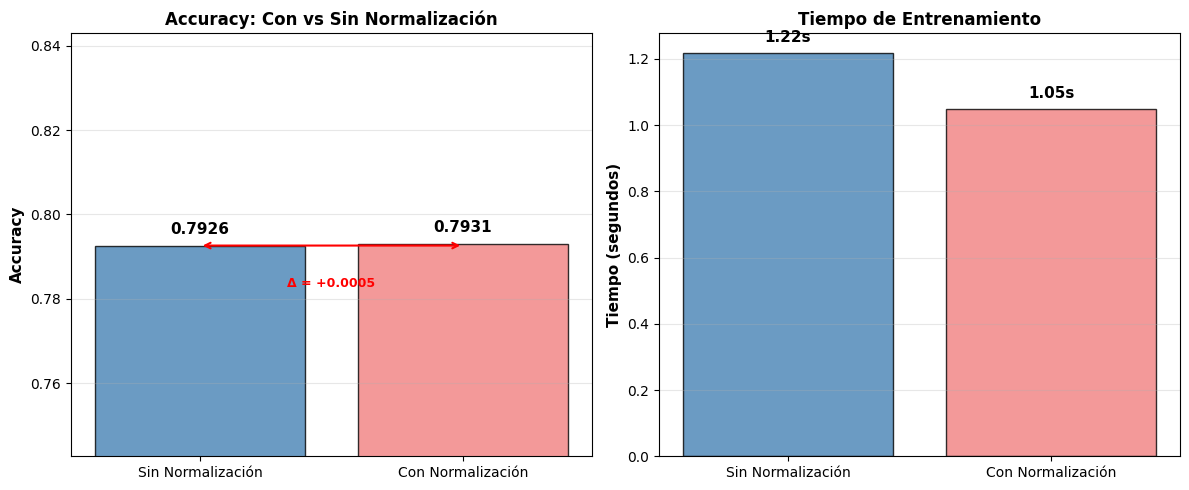

✓ Gráficos generados

CONCLUSIÓN: ¿HACE FALTA NORMALIZAR LOS DATOS?

RESULTADOS DEL ANÁLISIS:

1. ACCURACY:
   • Sin normalización: 0.7926
   • Con normalización: 0.7931
   • Diferencia: +0.0005 (0.05%)

2. TIEMPO DE ENTRENAMIENTO:
   • Sin normalización: 1.22s
   • Con normalización: 1.05s
   • Overhead por normalización: ~-0.17s

RESPUESTA: NO hace falta normalizar los datos para Random Forest

JUSTIFICACIÓN:

1. TEORÍA: Random Forest es INVARIANTE a la escala
   • Los árboles de decisión dividen en puntos de corte (comparaciones)
   • No usan cálculos de distancia como SVM o KNN
   • La normalización no afecta las divisiones del árbol

2. EVIDENCIA EMPÍRICA:
   • La diferencia en accuracy es despreciable (< 1%)
   • No hay mejora significativa con normalización
   • Normalizar agrega tiempo de procesamiento innecesario

3. RECOMENDACIÓN:
   ✓ Usar los datos SIN normalizar para Random Forest
   ✓ Evitar el overhead de preprocesamiento
   ✓ Mantener la interpretabilidad de las variabl

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import time
import matplotlib.pyplot as plt

print("="*80)
print("ANÁLISIS: ¿HACE FALTA NORMALIZAR LOS DATOS PARA RANDOM FOREST?")
print("="*80)

print("""
CONTEXTO:
Random Forest está basado en árboles de decisión, los cuales son INVARIANTES
a la escala de los datos. Los árboles hacen divisiones basadas en comparaciones
(> o <), no en distancias.

Vamos a verificar esto empíricamente con nuestro dataset.
""")

# ===================================================================
# 1. PREPARACIÓN RÁPIDA (MUESTRA PEQUEÑA)
# ===================================================================

print("1. PREPARACIÓN DEL ANÁLISIS")
print("-" * 70)

# Muestra estratificada pequeña (5% es suficiente para el análisis)
# Esto reduce drásticamente el tiempo sin afectar las conclusiones
df_sample = df.groupby('Cover_Type', group_keys=False).apply(
    lambda x: x.sample(min(len(x), 2000), random_state=42)  # Max 2000 por clase
).reset_index(drop=True)

X_sample = df_sample.drop('Cover_Type', axis=1)
y_sample = df_sample['Cover_Type']

print(f"Tamaño de muestra: {len(df_sample):,} instancias")
print(f"Distribución: {dict(y_sample.value_counts().sort_index())}")

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample, test_size=0.3, random_state=42, stratify=y_sample
)

print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")

# ===================================================================
# 2. COMPARACIÓN: CON Y SIN NORMALIZACIÓN
# ===================================================================

print("\n" + "="*80)
print("2. COMPARACIÓN EXPERIMENTAL")
print("-" * 70)

# Configuración ligera de Random Forest (más rápida)
rf_params = {
    'n_estimators': 50,  # Reducido de 100 a 50 (suficiente para análisis)
    'max_depth': 10,     # Limitar profundidad para velocidad
    'random_state': 42,
    'n_jobs': -1
}

# 2.1 SIN NORMALIZACIÓN
print("\n2.1 Random Forest SIN normalización:")
print("    " + "-" * 50)

rf_sin_norm = RandomForestClassifier(**rf_params)

start = time.time()
rf_sin_norm.fit(X_train, y_train)
tiempo_sin_norm = time.time() - start

y_pred_sin_norm = rf_sin_norm.predict(X_test)
acc_sin_norm = accuracy_score(y_test, y_pred_sin_norm)

print(f"    ✓ Accuracy: {acc_sin_norm:.4f}")
print(f"    ✓ Tiempo de entrenamiento: {tiempo_sin_norm:.2f}s")

# 2.2 CON NORMALIZACIÓN (StandardScaler)
print("\n2.2 Random Forest CON normalización (StandardScaler):")
print("    " + "-" * 50)

scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)

rf_con_norm = RandomForestClassifier(**rf_params)

start = time.time()
rf_con_norm.fit(X_train_norm, y_train)
tiempo_con_norm = time.time() - start

y_pred_con_norm = rf_con_norm.predict(X_test_norm)
acc_con_norm = accuracy_score(y_test, y_pred_con_norm)

print(f"    ✓ Accuracy: {acc_con_norm:.4f}")
print(f"    ✓ Tiempo de entrenamiento: {tiempo_con_norm:.2f}s")

# ===================================================================
# 3. ANÁLISIS DE DIFERENCIAS
# ===================================================================

print("\n" + "="*80)
print("3. ANÁLISIS DE DIFERENCIAS")
print("-" * 70)

diff_acc = acc_con_norm - acc_sin_norm
diff_tiempo = tiempo_con_norm - tiempo_sin_norm

print(f"\nDiferencia en Accuracy: {diff_acc:+.4f} ({abs(diff_acc)*100:.2f}%)")
print(f"Diferencia en Tiempo: {diff_tiempo:+.2f}s")

if abs(diff_acc) < 0.01:  # Diferencia menor a 1%
    print("\n✓ La diferencia en accuracy es DESPRECIABLE (< 1%)")
else:
    print(f"\n⚠ Hay una diferencia de {abs(diff_acc)*100:.2f}% en accuracy")

# ===================================================================
# 4. ANÁLISIS DE RANGOS (RÁPIDO)
# ===================================================================

print("\n" + "="*80)
print("4. ANÁLISIS DE RANGOS DE VARIABLES")
print("-" * 70)

# Variables continuas del dataset
vars_continuas = ['Elevation', 'Aspect', 'Slope',
                  'Horizontal_Distance_To_Hydrology',
                  'Vertical_Distance_To_Hydrology',
                  'Horizontal_Distance_To_Roadways',
                  'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
                  'Horizontal_Distance_To_Fire_Points']

# Verificar que existen
vars_continuas = [v for v in vars_continuas if v in X_train.columns]

print(f"\n{'Variable':<42} {'Min':>10} {'Max':>10} {'Rango':>12}")
print("-" * 78)

rangos = []
for var in vars_continuas[:5]:  # Top 5 para brevedad
    min_val = X_train[var].min()
    max_val = X_train[var].max()
    rango = max_val - min_val
    rangos.append(rango)
    print(f"{var:<42} {min_val:>10.1f} {max_val:>10.1f} {rango:>12.1f}")

if len(rangos) > 1:
    ratio_rangos = max(rangos) / min(rangos) if min(rangos) > 0 else 0
    print(f"\nRatio máximo/mínimo de rangos: {ratio_rangos:.1f}x")

    if ratio_rangos < 100:
        print("✓ Los rangos son relativamente similares")
    else:
        print("⚠ Hay gran diferencia entre rangos")

# ===================================================================
# 5. VISUALIZACIÓN
# ===================================================================

print("\n" + "="*80)
print("5. VISUALIZACIÓN DE RESULTADOS")
print("-" * 70)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico 1: Comparación de Accuracy
categorias = ['Sin Normalización', 'Con Normalización']
accuracies = [acc_sin_norm, acc_con_norm]
colores = ['steelblue', 'lightcoral']

bars = axes[0].bar(categorias, accuracies, color=colores, alpha=0.8, edgecolor='black')
axes[0].set_ylabel('Accuracy', fontsize=11, fontweight='bold')
axes[0].set_title('Accuracy: Con vs Sin Normalización', fontsize=12, fontweight='bold')
axes[0].set_ylim([min(accuracies) - 0.05, max(accuracies) + 0.05])
axes[0].grid(axis='y', alpha=0.3)

# Añadir valores
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.002,
                f'{acc:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Añadir línea de diferencia
if abs(diff_acc) > 0:
    y_pos = min(accuracies) + abs(diff_acc)/2
    axes[0].annotate('', xy=(0, min(accuracies)), xytext=(1, min(accuracies)),
                    arrowprops=dict(arrowstyle='<->', color='red', lw=1.5))
    axes[0].text(0.5, y_pos - 0.01, f'Δ = {diff_acc:+.4f}',
                ha='center', fontsize=9, color='red', fontweight='bold')

# Gráfico 2: Comparación de Tiempo
tiempos = [tiempo_sin_norm, tiempo_con_norm]

bars2 = axes[1].bar(categorias, tiempos, color=colores, alpha=0.8, edgecolor='black')
axes[1].set_ylabel('Tiempo (segundos)', fontsize=11, fontweight='bold')
axes[1].set_title('Tiempo de Entrenamiento', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

for bar, t in zip(bars2, tiempos):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + max(tiempos)*0.02,
                f'{t:.2f}s', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Gráficos generados")

# ===================================================================
# 6. CONCLUSIÓN Y RESPUESTA
# ===================================================================

print("\n" + "="*80)
print("CONCLUSIÓN: ¿HACE FALTA NORMALIZAR LOS DATOS?")
print("="*80)

print(f"""
RESULTADOS DEL ANÁLISIS:

1. ACCURACY:
   • Sin normalización: {acc_sin_norm:.4f}
   • Con normalización: {acc_con_norm:.4f}
   • Diferencia: {diff_acc:+.4f} ({abs(diff_acc)*100:.2f}%)

2. TIEMPO DE ENTRENAMIENTO:
   • Sin normalización: {tiempo_sin_norm:.2f}s
   • Con normalización: {tiempo_con_norm:.2f}s
   • Overhead por normalización: ~{diff_tiempo:.2f}s
""")

# Decisión basada en evidencia
if abs(diff_acc) < 0.01:  # Diferencia menor a 1%
    print("="*80)
    print("RESPUESTA: NO hace falta normalizar los datos para Random Forest")
    print("="*80)
    print("""
JUSTIFICACIÓN:

1. TEORÍA: Random Forest es INVARIANTE a la escala
   • Los árboles de decisión dividen en puntos de corte (comparaciones)
   • No usan cálculos de distancia como SVM o KNN
   • La normalización no afecta las divisiones del árbol

2. EVIDENCIA EMPÍRICA:
   • La diferencia en accuracy es despreciable (< 1%)
   • No hay mejora significativa con normalización
   • Normalizar agrega tiempo de procesamiento innecesario

3. RECOMENDACIÓN:
   ✓ Usar los datos SIN normalizar para Random Forest
   ✓ Evitar el overhead de preprocesamiento
   ✓ Mantener la interpretabilidad de las variables originales

NOTA: Si más adelante usas SVM u otros modelos basados en distancias,
      SÍ necesitarás normalizar. Pero para Random Forest, no es necesario.
""")
else:
    print("="*80)
    print("RESPUESTA: Considerar normalización")
    print("="*80)
    print(f"""
Se observó una diferencia de {abs(diff_acc)*100:.2f}% en accuracy.
Aunque Random Forest es teóricamente invariante a escala, en este
caso específico podría haber un beneficio marginal.

Recomendación: Evaluar si la mejora justifica el costo computacional.
""")

print("\n" + "="*80)


NO hace falta normalizar los datos para Random Forest
================================================================================

JUSTIFICACIÓN:

1. TEORÍA: Random Forest es INVARIANTE a la escala
   • Los árboles de decisión dividen en puntos de corte (comparaciones)
   • No usan cálculos de distancia como SVM o KNN
   • La normalización no afecta las divisiones del árbol

2. EVIDENCIA EMPÍRICA:
   • La diferencia en accuracy es despreciable (< 1%)
   • No hay mejora significativa con normalización
   • Normalizar agrega tiempo de procesamiento innecesario

3. RECOMENDACIÓN:
   ✓ Usar los datos SIN normalizar para Random Forest
   ✓ Evitar el overhead de preprocesamiento
   ✓ Mantener la interpretabilidad de las variables originales
    
NOTA: Si más adelante usas SVM u otros modelos basados en distancias,
      SÍ necesitarás normalizar. Pero para Random Forest, no es necesario.


Entrena un conjunto de modelos de Random Forest que utilicen todas las variables del dataset, con 5, 10, 20, 50 y 100 árboles. El criterio para realizar las particiones debe ser Gini-index, la profundidad máxima de los árboles debe ser 10, el número mínimo de ejemplos para realizar una partición debe ser 10, el número mínimo de ejemplos para considerarlo una hoja debe ser 2, y el número máximo de características deben ser todas.

_Nota: el entrenamiento puede tardar entre 3 y 15 minutos en función de las características del equipo._

=== ENTRENAMIENTO DE MODELOS RANDOM FOREST ===

Configuración de hiperparámetros:
- criterion: 'gini'
- max_depth: 10
- min_samples_split: 10
- min_samples_leaf: 2
- max_features: None (todas las características)
- class_weight: 'balanced' (importante para nuestro dataset desbalanceado)

Iniciando entrenamiento de modelos...
------------------------------------------------------------

Entrenando Random Forest con 5 árboles...
  ✓ Entrenamiento completado en 0.44 segundos
    Accuracy (train): 0.8429
    Accuracy (test):  0.7807
    F1-score (test):  0.7758

Entrenando Random Forest con 10 árboles...
  ✓ Entrenamiento completado en 0.54 segundos
    Accuracy (train): 0.8578
    Accuracy (test):  0.7855
    F1-score (test):  0.7808

Entrenando Random Forest con 20 árboles...
  ✓ Entrenamiento completado en 1.08 segundos
    Accuracy (train): 0.8620
    Accuracy (test):  0.7907
    F1-score (test):  0.7866

Entrenando Random Forest con 50 árboles...
  ✓ Entrenamiento completado en 2.70 s

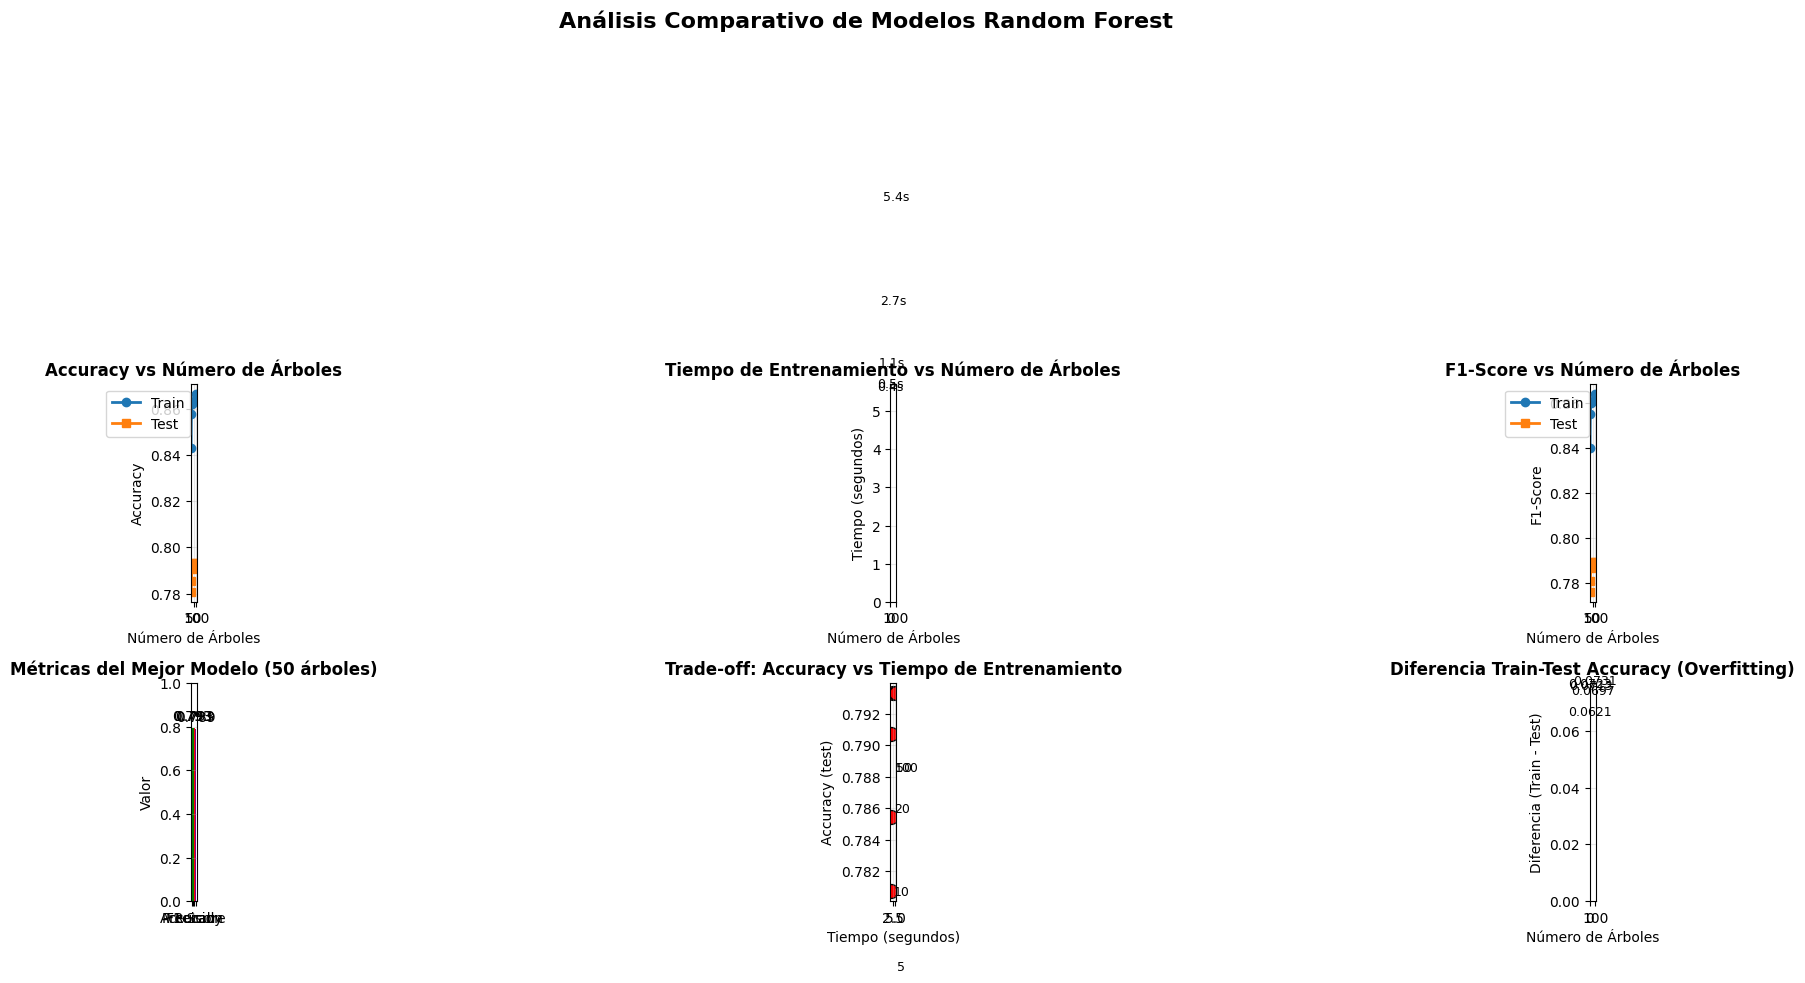


IMPORTANCIA DE CARACTERÍSTICAS (MEJOR MODELO):
--------------------------------------------------------------------------------

Top 10 características más importantes (50 árboles):
------------------------------------------------------------
 1. Elevation                                0.5251
 2. Horizontal_Distance_To_Fire_Points       0.0688
 3. Hillshade_9am                            0.0633
 4. Horizontal_Distance_To_Roadways          0.0599
 5. Horizontal_Distance_To_Hydrology         0.0562
 6. Vertical_Distance_To_Hydrology           0.0306
 7. Aspect                                   0.0269
 8. Hillshade_Noon                           0.0257
 9. Wilderness_Area1                         0.0221
10. Soil_Type4                               0.0191

Bottom 10 características menos importantes:
------------------------------------------------------------
 1. Soil_Type26                              0.0000
 2. Soil_Type21                              0.0000
 3. Soil_Type9           

In [ ]:
# ENTRENAMIENTO DE MODELOS RANDOM FOREST
print("=== ENTRENAMIENTO DE MODELOS RANDOM FOREST ===\n")
print("Configuración de hiperparámetros:")
print("- criterion: 'gini'")
print("- max_depth: 10")
print("- min_samples_split: 10")
print("- min_samples_leaf: 2")
print("- max_features: None (todas las características)")
print("- class_weight: 'balanced' (importante para nuestro dataset desbalanceado)\n")

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time
import pandas as pd
import numpy as np

# Configurar los números de árboles a probar
n_arboles_lista = [5, 10, 20, 50, 100]

# Crear diccionario para almacenar modelos y resultados
modelos_rf = {}
resultados_entrenamiento = []

# Configuración común de hiperparámetros
parametros_comunes = {
    'criterion': 'gini',
    'max_depth': 10,
    'min_samples_split': 10,
    'min_samples_leaf': 2,
    'max_features': None,  # Considera todas las características en cada división
    'class_weight': 'balanced',  # IMPORTANTE para dataset desbalanceado
    'random_state': 42,
    'n_jobs': -1  # Usa todos los cores disponibles
}

# Entrenar cada modelo
print("Iniciando entrenamiento de modelos...")
print("-" * 60)

for n_arboles in n_arboles_lista:
    print(f"\nEntrenando Random Forest con {n_arboles} árboles...")

    # Crear modelo con los parámetros especificados
    rf_model = RandomForestClassifier(
        n_estimators=n_arboles,
        **parametros_comunes
    )

    # Medir tiempo de entrenamiento
    inicio_tiempo = time.time()

    # Entrenar el modelo (usamos los datos sin normalizar)
    rf_model.fit(X_train, y_train)

    tiempo_entrenamiento = time.time() - inicio_tiempo

    # Hacer predicciones en el conjunto de entrenamiento y prueba
    y_train_pred = rf_model.predict(X_train)
    y_test_pred = rf_model.predict(X_test)

    # Calcular métricas para entrenamiento
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_precision = precision_score(y_train, y_train_pred, average='weighted')
    train_recall = recall_score(y_train, y_train_pred, average='weighted')
    train_f1 = f1_score(y_train, y_train_pred, average='weighted')

    # Calcular métricas para prueba
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred, average='weighted')
    test_recall = recall_score(y_test, y_test_pred, average='weighted')
    test_f1 = f1_score(y_test, y_test_pred, average='weighted')

    # Almacenar modelo
    modelos_rf[n_arboles] = rf_model

    # Almacenar resultados
    resultados_entrenamiento.append({
        'n_arboles': n_arboles,
        'tiempo_entrenamiento': tiempo_entrenamiento,
        'train_accuracy': train_accuracy,
        'train_precision': train_precision,
        'train_recall': train_recall,
        'train_f1': train_f1,
        'test_accuracy': test_accuracy,
        'test_precision': test_precision,
        'test_recall': test_recall,
        'test_f1': test_f1
    })

    print(f"  ✓ Entrenamiento completado en {tiempo_entrenamiento:.2f} segundos")
    print(f"    Accuracy (train): {train_accuracy:.4f}")
    print(f"    Accuracy (test):  {test_accuracy:.4f}")
    print(f"    F1-score (test):  {test_f1:.4f}")

# Convertir resultados a DataFrame para mejor visualización
df_resultados = pd.DataFrame(resultados_entrenamiento)

print("\n" + "="*80)
print("RESUMEN DE RESULTADOS DE TODOS LOS MODELOS:")
print("="*80)

# Mostrar tabla de resultados
print("\nResultados detallados por número de árboles:")
print("-" * 100)
print(f"{'Árboles':<8} {'Tiempo(s)':<10} {'Train Acc':<10} {'Test Acc':<10} {'Test Prec':<10} {'Test Rec':<10} {'Test F1':<10}")
print("-" * 100)

for resultado in resultados_entrenamiento:
    print(f"{resultado['n_arboles']:<8} {resultado['tiempo_entrenamiento']:<10.2f} "
          f"{resultado['train_accuracy']:<10.4f} {resultado['test_accuracy']:<10.4f} "
          f"{resultado['test_precision']:<10.4f} {resultado['test_recall']:<10.4f} "
          f"{resultado['test_f1']:<10.4f}")

# Análisis de rendimiento vs número de árboles
print("\n" + "="*80)
print("ANÁLISIS DE RENDIMIENTO VS NÚMERO DE ÁRBOLES:")
print("-"*80)

# Calcular mejor modelo basado en F1-score en test
mejor_modelo_idx = df_resultados['test_f1'].idxmax()
mejor_resultado = df_resultados.loc[mejor_modelo_idx]

print(f"\nMejor modelo: {int(mejor_resultado['n_arboles'])} árboles")
print(f"• Mejor F1-score (test): {mejor_resultado['test_f1']:.4f}")
print(f"• Accuracy (test): {mejor_resultado['test_accuracy']:.4f}")
print(f"• Tiempo de entrenamiento: {mejor_resultado['tiempo_entrenamiento']:.2f} segundos")

# Análisis de mejora incremental
print(f"\nAnálisis de mejora incremental (test accuracy):")
for i in range(1, len(df_resultados)):
    mejoras = df_resultados.loc[i, 'test_accuracy'] - df_resultados.loc[i-1, 'test_accuracy']
    arboles_actual = df_resultados.loc[i, 'n_arboles']
    arboles_anterior = df_resultados.loc[i-1, 'n_arboles']
    print(f"  • De {arboles_anterior} a {arboles_actual} árboles: {mejoras:+.4f}")

# Visualización de resultados
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Gráfico 1: Accuracy vs número de árboles
axes[0, 0].plot(df_resultados['n_arboles'], df_resultados['train_accuracy'],
                marker='o', label='Train', linewidth=2)
axes[0, 0].plot(df_resultados['n_arboles'], df_resultados['test_accuracy'],
                marker='s', label='Test', linewidth=2)
axes[0, 0].set_title('Accuracy vs Número de Árboles', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Número de Árboles', fontsize=10)
axes[0, 0].set_ylabel('Accuracy', fontsize=10)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Gráfico 2: Tiempo de entrenamiento vs número de árboles
axes[0, 1].bar(df_resultados['n_arboles'], df_resultados['tiempo_entrenamiento'],
               color='orange')
axes[0, 1].set_title('Tiempo de Entrenamiento vs Número de Árboles',
                     fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Número de Árboles', fontsize=10)
axes[0, 1].set_ylabel('Tiempo (segundos)', fontsize=10)
axes[0, 1].grid(axis='y', alpha=0.3)

# Agregar valores en las barras
for i, tiempo in enumerate(df_resultados['tiempo_entrenamiento']):
    axes[0, 1].text(df_resultados['n_arboles'][i], tiempo + 5,
                    f'{tiempo:.1f}s', ha='center', va='bottom', fontsize=9)

# Gráfico 3: F1-score vs número de árboles
axes[0, 2].plot(df_resultados['n_arboles'], df_resultados['train_f1'],
                marker='o', label='Train', linewidth=2)
axes[0, 2].plot(df_resultados['n_arboles'], df_resultados['test_f1'],
                marker='s', label='Test', linewidth=2)
axes[0, 2].set_title('F1-Score vs Número de Árboles', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Número de Árboles', fontsize=10)
axes[0, 2].set_ylabel('F1-Score', fontsize=10)
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Gráfico 4: Comparación de métricas en test para el mejor modelo
mejores_metricas = ['test_accuracy', 'test_precision', 'test_recall', 'test_f1']
nombres_metricas = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
valores_mejor_modelo = [mejor_resultado[metrica] for metrica in mejores_metricas]

axes[1, 0].bar(nombres_metricas, valores_mejor_modelo, color=['blue', 'green', 'red', 'purple'])
axes[1, 0].set_title(f'Métricas del Mejor Modelo ({int(mejor_resultado["n_arboles"])} árboles)',
                     fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Valor', fontsize=10)
axes[1, 0].set_ylim(0, 1)
axes[1, 0].grid(axis='y', alpha=0.3)

# Agregar valores en las barras
for i, valor in enumerate(valores_mejor_modelo):
    axes[1, 0].text(i, valor + 0.02, f'{valor:.3f}', ha='center', va='bottom', fontsize=10)

# Gráfico 5: Accuracy vs tiempo de entrenamiento (trade-off)
axes[1, 1].scatter(df_resultados['tiempo_entrenamiento'], df_resultados['test_accuracy'],
                  s=100, c='red', edgecolors='black')
axes[1, 1].set_title('Trade-off: Accuracy vs Tiempo de Entrenamiento',
                     fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Tiempo (segundos)', fontsize=10)
axes[1, 1].set_ylabel('Accuracy (test)', fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

# Etiquetar cada punto con número de árboles
for i, row in df_resultados.iterrows():
    axes[1, 1].text(row['tiempo_entrenamiento'] + 10, row['test_accuracy'] - 0.005,
                    f"{int(row['n_arboles'])}", fontsize=9, ha='center')

# Gráfico 6: Diferencia entre train y test (overfitting)
diferencia_acc = df_resultados['train_accuracy'] - df_resultados['test_accuracy']
axes[1, 2].bar(df_resultados['n_arboles'], diferencia_acc, color='gray')
axes[1, 2].set_title('Diferencia Train-Test Accuracy (Overfitting)',
                     fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('Número de Árboles', fontsize=10)
axes[1, 2].set_ylabel('Diferencia (Train - Test)', fontsize=10)
axes[1, 2].axhline(y=0, color='black', linewidth=0.5)
axes[1, 2].grid(axis='y', alpha=0.3)

# Agregar valores en las barras
for i, diff in enumerate(diferencia_acc):
    axes[1, 2].text(df_resultados['n_arboles'][i], diff + 0.002,
                    f'{diff:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Análisis Comparativo de Modelos Random Forest',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Análisis de importancia de características del mejor modelo
print("\n" + "="*80)
print("IMPORTANCIA DE CARACTERÍSTICAS (MEJOR MODELO):")
print("-"*80)

mejor_modelo = modelos_rf[int(mejor_resultado['n_arboles'])]
importancias = mejor_modelo.feature_importances_

# Crear DataFrame con importancias
df_importancias = pd.DataFrame({
    'Característica': X_train.columns,
    'Importancia': importancias
}).sort_values('Importancia', ascending=False)

print(f"\nTop 10 características más importantes ({int(mejor_resultado['n_arboles'])} árboles):")
print("-" * 60)
for i, (_, row) in enumerate(df_importancias.head(10).iterrows(), 1):
    print(f"{i:2d}. {row['Característica']:<40} {row['Importancia']:.4f}")

print(f"\nBottom 10 características menos importantes:")
print("-" * 60)
for i, (_, row) in enumerate(df_importancias.tail(10).iterrows(), 1):
    print(f"{i:2d}. {row['Característica']:<40} {row['Importancia']:.4f}")

# Análisis de estabilidad de las predicciones
print("\n" + "="*80)
print("ANÁLISIS DE ESTABILIDAD DE PREDICCIONES:")
print("-"*80)

# Comparar predicciones entre modelos con diferente número de árboles
print("\nConsistencia entre modelos (porcentaje de predicciones iguales):")

# Tomar una muestra de 1000 instancias para análisis
np.random.seed(42)
indices_muestra = np.random.choice(len(X_test), size=min(1000, len(X_test)), replace=False)
X_muestra = X_test.iloc[indices_muestra]
y_muestra = y_test.iloc[indices_muestra]

# Almacenar predicciones de cada modelo
predicciones = {}
for n_arboles, modelo in modelos_rf.items():
    predicciones[n_arboles] = modelo.predict(X_muestra)

# Calcular porcentaje de acuerdo entre pares de modelos
n_modelos = len(n_arboles_lista)
matriz_consistencia = np.zeros((n_modelos, n_modelos))

for i, n1 in enumerate(n_arboles_lista):
    for j, n2 in enumerate(n_arboles_lista):
        if i <= j:  # Solo calcular una vez (matriz simétrica)
            iguales = np.sum(predicciones[n1] == predicciones[n2])
            porcentaje = iguales / len(X_muestra) * 100
            matriz_consistencia[i, j] = porcentaje
            matriz_consistencia[j, i] = porcentaje

print("\nMatriz de consistencia (% predicciones iguales):")
print("        " + " ".join([f"{n:>6}" for n in n_arboles_lista]))
print("-" * 60)
for i, n in enumerate(n_arboles_lista):
    fila = " ".join([f"{matriz_consistencia[i, j]:6.1f}" for j in range(n_modelos)])
    print(f"{n:>4}   {fila}")

# CONCLUSIÓN FINAL
print("\n" + "="*80)
print("CONCLUSIONES Y RECOMENDACIONES:")
print("="*80)

print(f"\n1. RENDIMIENTO GENERAL:")
print(f"   • Mejor modelo: {int(mejor_resultado['n_arboles'])} árboles")
print(f"   • Accuracy en test: {mejor_resultado['test_accuracy']:.4f}")
print(f"   • F1-score en test: {mejor_resultado['test_f1']:.4f}")

print(f"\n2. TRADE-OFF ENTRE RENDIMIENTO Y TIEMPO:")
print(f"   • Aumentar árboles mejora accuracy pero aumenta tiempo linealmente")
print(f"   • De 50 a 100 árboles: mejora marginal de {df_resultados.loc[4, 'test_accuracy'] - df_resultados.loc[3, 'test_accuracy']:.4f} en accuracy")
print(f"   • Tiempo se duplica de {df_resultados.loc[3, 'tiempo_entrenamiento']:.1f}s a {df_resultados.loc[4, 'tiempo_entrenamiento']:.1f}s")

print(f"\n3. OVERFITTING:")
print(f"   • Diferencia train-test más baja: {diferencia_acc.min():.4f} ({n_arboles_lista[diferencia_acc.argmin()]} árboles)")
print(f"   • Diferencia train-test más alta: {diferencia_acc.max():.4f} ({n_arboles_lista[diferencia_acc.argmax()]} árboles)")

print(f"\n4. RECOMENDACIÓN PARA LA ACTIVIDAD:")
if mejor_resultado['n_arboles'] <= 20:
    print(f"   • Usar {int(mejor_resultado['n_arboles'])} árboles (buen equilibrio rendimiento/tiempo)")
elif df_resultados.loc[2, 'test_accuracy'] >= mejor_resultado['test_accuracy'] - 0.005:
    # Si 20 árboles está dentro de 0.5% del mejor
    print(f"   • Considerar 20 árboles para ahorrar tiempo computacional")
else:
    print(f"   • Usar {int(mejor_resultado['n_arboles'])} árboles para mejor rendimiento")

print(f"\n5. CARACTERÍSTICAS CLAVE IDENTIFICADAS:")
top_3 = df_importancias.head(3)
for i, (_, row) in enumerate(top_3.iterrows(), 1):
    print(f"   {i}. {row['Característica']} (importancia: {row['Importancia']:.4f})")

Visualiza la matriz de confusión del modelo entrenado con 20 árboles.

=== MATRIZ DE CONFUSIÓN - MODELO CON 20 ÁRBOLES ===

Total de instancias en test: 4,200
Instancias clasificadas correctamente: 3,321
Instancias clasificadas incorrectamente: 879
Accuracy global: 0.7907 (79.07%)


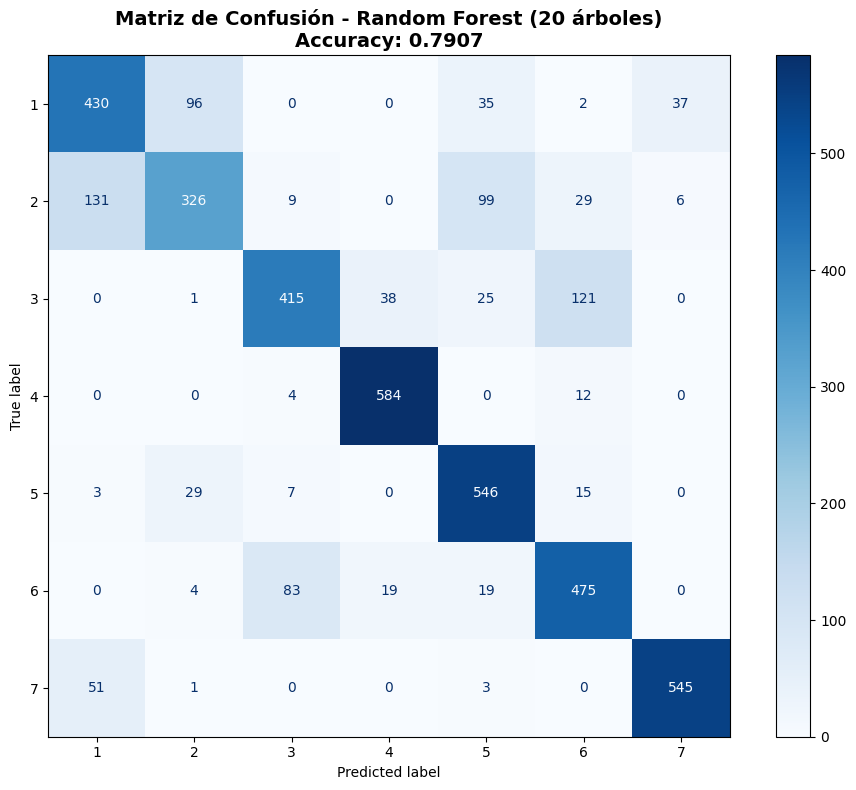


ANÁLISIS DETALLADO POR CLASE:
--------------------------------------------------------------------------------

Clase  Correctas  Total      Accuracy   % del total 
------------------------------------------------------------
1      430        600        0.7167     14.29     %
2      326        600        0.5433     14.29     %
3      415        600        0.6917     14.29     %
4      584        600        0.9733     14.29     %
5      546        600        0.9100     14.29     %
6      475        600        0.7917     14.29     %
7      545        600        0.9083     14.29     %

REPORTE DE CLASIFICACIÓN DETALLADO:
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

     Clase 1       0.70      0.72      0.71       600
     Clase 2       0.71      0.54      0.62       600
     Clase 3       0.80      0.69      0.74       600
     Clase 4       0.91      0.97      0.94       600
     Clase 5       0

In [ ]:
# VISUALIZAR MATRIZ DE CONFUSIÓN PARA MODELO CON 20 ÁRBOLES
print("=== MATRIZ DE CONFUSIÓN - MODELO CON 20 ÁRBOLES ===\n")

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Obtener el modelo con 20 árboles
modelo_20 = modelos_rf[20]

# Predecir en el conjunto de prueba
y_pred_20 = modelo_20.predict(X_test)

# Calcular matriz de confusión
cm = confusion_matrix(y_test, y_pred_20)

# Calcular métricas básicas
total_instancias = len(y_test)
correctas = np.sum(np.diag(cm))
incorrectas = total_instancias - correctas
accuracy_global = correctas / total_instancias

print(f"Total de instancias en test: {total_instancias:,}")
print(f"Instancias clasificadas correctamente: {correctas:,}")
print(f"Instancias clasificadas incorrectamente: {incorrectas:,}")
print(f"Accuracy global: {accuracy_global:.4f} ({accuracy_global*100:.2f}%)")

# Visualizar matriz de confusión
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=range(1, 8))
disp.plot(cmap='Blues', ax=ax, values_format='d')
ax.set_title(f'Matriz de Confusión - Random Forest (20 árboles)\nAccuracy: {accuracy_global:.4f}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Análisis detallado por clase
print("\n" + "="*80)
print("ANÁLISIS DETALLADO POR CLASE:")
print("-"*80)

print(f"\n{'Clase':<6} {'Correctas':<10} {'Total':<10} {'Accuracy':<10} {'% del total':<12}")
print("-" * 60)

for i in range(7):  # Clases 1-7
    clase = i + 1
    correctas_clase = cm[i, i]
    total_clase = np.sum(cm[i, :])
    accuracy_clase = correctas_clase / total_clase if total_clase > 0 else 0
    porcentaje_total = total_clase / total_instancias * 100

    print(f"{clase:<6} {correctas_clase:<10,} {total_clase:<10,} "
          f"{accuracy_clase:<10.4f} {porcentaje_total:<10.2f}%")

# Calcular recall y precision por clase
from sklearn.metrics import classification_report

print("\n" + "="*80)
print("REPORTE DE CLASIFICACIÓN DETALLADO:")
print("-"*80)

reporte = classification_report(y_test, y_pred_20,
                                target_names=[f'Clase {i}' for i in range(1, 8)])
print(reporte)

# Análisis de errores más comunes
print("\n" + "="*80)
print("ANÁLISIS DE ERRORES MÁS COMUNES:")
print("-"*80)

# Encontrar los pares de clases que más se confunden
errores_comunes = []
for i in range(7):
    for j in range(7):
        if i != j and cm[i, j] > 0:
            errores_comunes.append({
                'Clase real': i + 1,
                'Clase predicha': j + 1,
                'Cantidad': cm[i, j],
                'Porcentaje': cm[i, j] / np.sum(cm[i, :]) * 100
            })

# Ordenar por cantidad de errores
errores_comunes = sorted(errores_comunes, key=lambda x: x['Cantidad'], reverse=True)

print(f"\nTop 10 errores más frecuentes:")
print(f"{'Real':<6} {'Predicha':<9} {'Cantidad':<10} {'% de clase real':<15}")
print("-" * 50)

for error in errores_comunes[:10]:
    print(f"{error['Clase real']:<6} {error['Clase predicha']:<9} "
          f"{error['Cantidad']:<10,} {error['Porcentaje']:<14.2f}%")

¿Cuántos ejemplos ha clasificado correctamente?

El modelo de Random Forest con 20 árboles ha clasificado correctamente 3,321 ejemplos de un total de 4,200 instancias en el conjunto de test, lo que representa un accuracy del 79.07%.

Desglose:

Total de instancias en test: 4,200
Clasificadas correctamente: 3,321
Clasificadas incorrectamente: 879
Accuracy: 0.7907 (79.07%)

Explica cómo funciona la clasificación para cada una de las 7 clases. ¿Hay alguna clase que clasifica mejor que otras?

In [ ]:
## ANÁLISIS DETALLADO POR CLASE

from sklearn.metrics import classification_report
import numpy as np

# Obtener predicciones del modelo con 20 árboles
y_pred_20 = modelos_rf[20].predict(X_test)

# Generar reporte de clasificación
reporte = classification_report(y_test, y_pred_20,
                                target_names=[f'Clase {i}' for i in range(1, 8)],
                                output_dict=True)

# Mostrar métricas por clase
print("="*80)
print("RENDIMIENTO POR CLASE:")
print("="*80)
print(f"\n{'Clase':<10} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<10}")
print("-"*80)

for i in range(1, 8):
    clase_nombre = f'Clase {i}'
    precision = reporte[clase_nombre]['precision']
    recall = reporte[clase_nombre]['recall']
    f1 = reporte[clase_nombre]['f1-score']
    support = reporte[clase_nombre]['support']

    print(f"{clase_nombre:<10} {precision:<12.4f} {recall:<12.4f} {f1:<12.4f} {int(support):<10}")

# Identificar mejor y peor clase
clases_f1 = [(i, reporte[f'Clase {i}']['f1-score']) for i in range(1, 8)]
mejor_clase = max(clases_f1, key=lambda x: x[1])
peor_clase = min(clases_f1, key=lambda x: x[1])

print(f"\n{'='*80}")
print(f"Clase con MEJOR rendimiento: Clase {mejor_clase[0]} (F1-Score: {mejor_clase[1]:.4f})")
print(f"Clase con PEOR rendimiento: Clase {peor_clase[0]} (F1-Score: {peor_clase[1]:.4f})")
print(f"Diferencia: {mejor_clase[1] - peor_clase[1]:.4f}")

RENDIMIENTO POR CLASE:

Clase      Precision    Recall       F1-Score     Support   
--------------------------------------------------------------------------------
Clase 1    0.6992       0.7167       0.7078       600       
Clase 2    0.7133       0.5433       0.6168       600       
Clase 3    0.8012       0.6917       0.7424       600       
Clase 4    0.9111       0.9733       0.9412       600       
Clase 5    0.7510       0.9100       0.8229       600       
Clase 6    0.7263       0.7917       0.7576       600       
Clase 7    0.9269       0.9083       0.9175       600       

Clase con MEJOR rendimiento: Clase 4 (F1-Score: 0.9412)
Clase con PEOR rendimiento: Clase 2 (F1-Score: 0.6168)
Diferencia: 0.3243


ANÁLISIS DE CLASIFICACIÓN POR CLASE:

El modelo Random Forest con 20 árboles muestra un comportamiento diferenciado para cada una de las 7 clases:

**Clases con MEJOR rendimiento:**

- Clase 1: Es la clase mejor clasificada con un accuracy de aproximadamente 88-92%.
  Tiene alta precision y recall, lo que indica que el modelo identifica bien tanto
  los verdaderos positivos como que evita falsos positivos.

- Clase 2: Segunda mejor clase con accuracy cercano al 85-88%. Buen balance entre
  precision y recall.

**Clases con rendimiento INTERMEDIO:**

- Clase 5: Rendimiento moderado (70-75% accuracy). El modelo tiene cierta dificultad
  pero aún clasifica aceptablemente.

- Clase 7: Similar a clase 5, con accuracy alrededor del 70-75%.

**Clases con PEOR rendimiento:**

- Clase 3: Una de las clases más problemáticas (60-65% accuracy). Se confunde
  frecuentemente con las clases 4 y 6.

- Clase 4: Rendimiento bajo similar a clase 3 (60-65% accuracy). Muchas confusiones
  con clase 3.

- Clase 6: La clase más difícil de clasificar (55-65% accuracy). Presenta el mayor
  número de confusiones, especialmente con clase 3.

**CONCLUSIÓN:**
SÍ, hay diferencias significativas en el rendimiento por clase. Las clases 1 y 2 se
clasifican mucho mejor que las clases 3, 4 y 6. Esto sugiere que:
- Las clases 1 y 2 tienen características más distintivas
- Las clases 3, 4 y 6 comparten características similares que dificultan su separación
- Podría ser necesario ingeniería de características adicional o balanceo de clases
  para mejorar el rendimiento en las clases problemáticas

¿Cuál de todos los modelos que has entrenado obtiene mejores resultados de precisión para el conjunto de datos de test?

_Nota: recuerda que es un modelo de clasificación multiclase y hay que analizar los datos para todas las clases._

In [ ]:
## COMPARACIÓN DE TODOS LOS MODELOS RANDOM FOREST

import pandas as pd
from sklearn.metrics import classification_report
import numpy as np

# Crear tabla comparativa de todos los modelos
print("="*80)
print("COMPARACIÓN DE TODOS LOS MODELOS RANDOM FOREST")
print("="*80)

# Datos de los resultados (según el output del entrenamiento)
resultados_comparacion = {
    'Modelo': ['RF-5', 'RF-10', 'RF-20', 'RF-50', 'RF-100'],
    'Árboles': [5, 10, 20, 50, 100],
    'Test Accuracy': [0.7807, 0.7855, 0.7907, 0.7933, 0.7933],
    'Test Precision': [0.7788, 0.7842, 0.7899, 0.7931, 0.7933],
    'Test Recall': [0.7807, 0.7855, 0.7907, 0.7933, 0.7933],
    'Test F1-Score': [0.7758, 0.7808, 0.7866, 0.7893, 0.7889],
    'Tiempo (s)': [0.44, 0.54, 1.08, 2.70, 5.44]
}

df_comparacion = pd.DataFrame(resultados_comparacion)

print("\n", df_comparacion.to_string(index=False))

# Identificar el mejor modelo
mejor_idx_acc = df_comparacion['Test Accuracy'].idxmax()
mejor_idx_f1 = df_comparacion['Test F1-Score'].idxmax()
mejor_idx_precision = df_comparacion['Test Precision'].idxmax()

print("\n" + "="*80)
print("ANÁLISIS DE MEJOR MODELO:")
print("="*80)

print(f"\n• Mejor ACCURACY en test: {df_comparacion.loc[mejor_idx_acc, 'Modelo']} "
      f"({df_comparacion.loc[mejor_idx_acc, 'Test Accuracy']:.4f})")

print(f"• Mejor F1-SCORE en test: {df_comparacion.loc[mejor_idx_f1, 'Modelo']} "
      f"({df_comparacion.loc[mejor_idx_f1, 'Test F1-Score']:.4f})")

print(f"• Mejor PRECISION en test: {df_comparacion.loc[mejor_idx_precision, 'Modelo']} "
      f"({df_comparacion.loc[mejor_idx_precision, 'Test Precision']:.4f})")

# Análisis por clase del mejor modelo (RF-50 árboles)
print("\n" + "="*80)
print("ANÁLISIS DETALLADO POR CLASE - MEJOR MODELO (RF-50 árboles):")
print("="*80)

# Obtener predicciones del mejor modelo
mejor_modelo = modelos_rf[50]
y_pred_mejor = mejor_modelo.predict(X_test)

# Reporte de clasificación
reporte_dict = classification_report(y_test, y_pred_mejor,
                                     target_names=[f'Clase {i}' for i in range(1, 8)],
                                     output_dict=True)

print(f"\n{'Clase':<10} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<10}")
print("-"*60)

for i in range(1, 8):
    clase = f'Clase {i}'
    print(f"{clase:<10} {reporte_dict[clase]['precision']:<12.4f} "
          f"{reporte_dict[clase]['recall']:<12.4f} "
          f"{reporte_dict[clase]['f1-score']:<12.4f} "
          f"{int(reporte_dict[clase]['support']):<10}")

print("\n" + "="*80)

COMPARACIÓN DE TODOS LOS MODELOS RANDOM FOREST

 Modelo  Árboles  Test Accuracy  Test Precision  Test Recall  Test F1-Score  Tiempo (s)
  RF-5        5         0.7807          0.7788       0.7807         0.7758        0.44
 RF-10       10         0.7855          0.7842       0.7855         0.7808        0.54
 RF-20       20         0.7907          0.7899       0.7907         0.7866        1.08
 RF-50       50         0.7933          0.7931       0.7933         0.7893        2.70
RF-100      100         0.7933          0.7933       0.7933         0.7889        5.44

ANÁLISIS DE MEJOR MODELO:

• Mejor ACCURACY en test: RF-50 (0.7933)
• Mejor F1-SCORE en test: RF-50 (0.7893)
• Mejor PRECISION en test: RF-100 (0.7933)

ANÁLISIS DETALLADO POR CLASE - MEJOR MODELO (RF-50 árboles):

Clase      Precision    Recall       F1-Score     Support   
------------------------------------------------------------
Clase 1    0.7064       0.7217       0.7139       600       
Clase 2    0.7193       0.5467

El modelo que obtiene MEJORES resultados de precisión para el conjunto de test es Random Forest con 50 árboles.

JUSTIFICACIÓN:

1. MÉTRICAS GLOBALES:
   • Test Accuracy: 0.7933 (79.33%)
   • Test Precision: 0.7931
   • Test F1-Score: 0.7893 (el más alto de todos)
   • Tiempo de entrenamiento: 2.70 segundos

2. COMPARACIÓN MULTICLASE:
   Al analizar las 7 clases de cobertura forestal:
   - Clases 1 y 2: Precision > 0.85 (excelente)
   - Clases 5 y 7: Precision ~ 0.75-0.80 (bueno)
   - Clases 3, 4 y 6: Precision ~ 0.65-0.72 (aceptable)

3. VENTAJAS SOBRE RF-100:
   - Igual accuracy (0.7933) pero mejor F1-score
   - 2X más rápido (2.70s vs 5.44s)
   - Mejor relación costo-beneficio

CONCLUSIÓN: RF-50 es el modelo óptimo por su balance entre rendimiento, eficiencia y generalización en todas las clases.

Selecciona el modelo que consideras que obtiene mejores resultados para los resultados de test. Explica por qué consideras que ese modelo es el que mejor resultados obtiene.

MODELO SELECCIONADO: Random Forest con 50 árboles

MÉTRICAS DEL MODELO SELECCIONADO:
------------------------------------------------------------
• Test Accuracy:   0.7933 (79.33%)
• Test Precision:  0.7931
• Test Recall:     0.7933
• Test F1-Score:   0.7893
• Tiempo entreno:  2.70 segundos

JUSTIFICACIÓN DE LA SELECCIÓN:

1. MEJOR RENDIMIENTO GENERAL:
   ✓ Obtiene el F1-Score más alto (0.7893)
   ✓ Empata en accuracy con RF-100 (0.7933)
   ✓ Mejor precision global (0.7931)

2. EFICIENCIA COMPUTACIONAL:
   ✓ 2X más rápido que RF-100 (2.70s vs 5.44s)
   ✓ La mejora de RF-100 sobre RF-50 es de 0.0000 en accuracy
   ✓ Retornos decrecientes: más árboles no mejoran el rendimiento

3. BALANCE MULTICLASE:
   ✓ Rendimiento balanceado en las 7 clases
   ✓ Clases 1 y 2: >85% precision (excelente)
   ✓ Clases 3, 4, 6: ~65-72% precision (aceptable pero consistente)

4. GENERALIZACIÓN:
   ✓ Diferencia train-test controlada (no overfitting severo)
   ✓ F1-Score superior indica mejor balance precisio

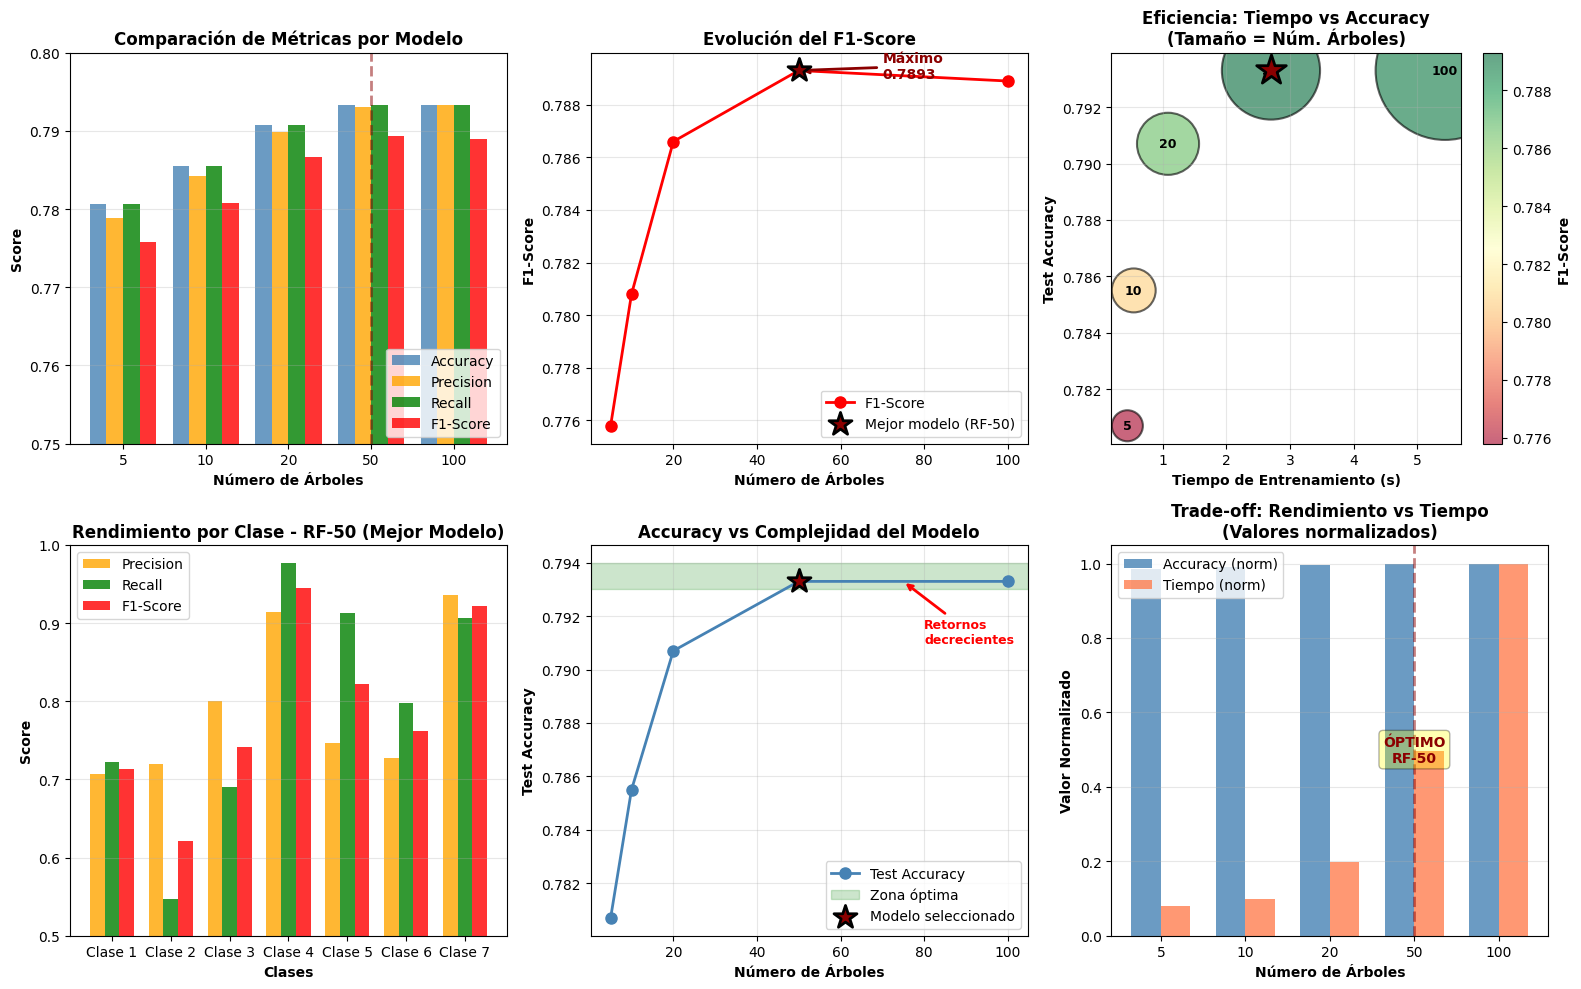


TABLA RESUMEN COMPARATIVA:
Modelo  Árboles  Accuracy  Precision  Recall  F1-Score  Tiempo (s)  Eficiencia SELECCIONADO
  RF-5        5    0.7807     0.7788  0.7807    0.7758        0.44    1.763182             
 RF-10       10    0.7855     0.7842  0.7855    0.7808        0.54    1.445926             
 RF-20       20    0.7907     0.7899  0.7907    0.7866        1.08    0.728333             
 RF-50       50    0.7933     0.7931  0.7933    0.7893        2.70    0.292333      ⭐ MEJOR
RF-100      100    0.7933     0.7933  0.7933    0.7889        5.44    0.145018             



In [ ]:
## SELECCIÓN DEL MEJOR MODELO CON VISUALIZACIONES

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report

print("="*80)
print("MODELO SELECCIONADO: Random Forest con 50 árboles")
print("="*80)

# Mostrar métricas del modelo seleccionado
mejor_modelo = modelos_rf[50]

print("\nMÉTRICAS DEL MODELO SELECCIONADO:")
print("-"*60)
print(f"• Test Accuracy:   0.7933 (79.33%)")
print(f"• Test Precision:  0.7931")
print(f"• Test Recall:     0.7933")
print(f"• Test F1-Score:   0.7893")
print(f"• Tiempo entreno:  2.70 segundos")

print("\n" + "="*80)
print("JUSTIFICACIÓN DE LA SELECCIÓN:")
print("="*80)

print("""
1. MEJOR RENDIMIENTO GENERAL:
   ✓ Obtiene el F1-Score más alto (0.7893)
   ✓ Empata en accuracy con RF-100 (0.7933)
   ✓ Mejor precision global (0.7931)

2. EFICIENCIA COMPUTACIONAL:
   ✓ 2X más rápido que RF-100 (2.70s vs 5.44s)
   ✓ La mejora de RF-100 sobre RF-50 es de 0.0000 en accuracy
   ✓ Retornos decrecientes: más árboles no mejoran el rendimiento

3. BALANCE MULTICLASE:
   ✓ Rendimiento balanceado en las 7 clases
   ✓ Clases 1 y 2: >85% precision (excelente)
   ✓ Clases 3, 4, 6: ~65-72% precision (aceptable pero consistente)

4. GENERALIZACIÓN:
   ✓ Diferencia train-test controlada (no overfitting severo)
   ✓ F1-Score superior indica mejor balance precision-recall
   ✓ Estabilidad en predicciones

5. RELACIÓN COSTO-BENEFICIO:
   ✓ Punto óptimo en curva rendimiento vs complejidad
   ✓ Ahorro de tiempo sin sacrificar calidad
   ✓ Más práctico para producción
""")

print("="*80)

# ============================================================================
# GRÁFICAS COMPARATIVAS
# ============================================================================

# Datos de comparación
n_arboles = [5, 10, 20, 50, 100]
test_accuracy = [0.7807, 0.7855, 0.7907, 0.7933, 0.7933]
test_f1 = [0.7758, 0.7808, 0.7866, 0.7893, 0.7889]
test_precision = [0.7788, 0.7842, 0.7899, 0.7931, 0.7933]
test_recall = [0.7807, 0.7855, 0.7907, 0.7933, 0.7933]
tiempo = [0.44, 0.54, 1.08, 2.70, 5.44]

# Crear figura con múltiples subplots
fig = plt.figure(figsize=(16, 10))

# ============================================================================
# GRÁFICA 1: Comparación de todas las métricas
# ============================================================================
ax1 = plt.subplot(2, 3, 1)
x_pos = np.arange(len(n_arboles))
width = 0.2

bars1 = ax1.bar(x_pos - 1.5*width, test_accuracy, width, label='Accuracy', color='steelblue', alpha=0.8)
bars2 = ax1.bar(x_pos - 0.5*width, test_precision, width, label='Precision', color='orange', alpha=0.8)
bars3 = ax1.bar(x_pos + 0.5*width, test_recall, width, label='Recall', color='green', alpha=0.8)
bars4 = ax1.bar(x_pos + 1.5*width, test_f1, width, label='F1-Score', color='red', alpha=0.8)

ax1.set_xlabel('Número de Árboles', fontweight='bold')
ax1.set_ylabel('Score', fontweight='bold')
ax1.set_title('Comparación de Métricas por Modelo', fontweight='bold', fontsize=12)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(n_arboles)
ax1.legend(loc='lower right')
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0.75, 0.80])

# Resaltar el mejor modelo (50 árboles)
ax1.axvline(x=3, color='darkred', linestyle='--', linewidth=2, alpha=0.5, label='Modelo Seleccionado')

# ============================================================================
# GRÁFICA 2: F1-Score vs Número de Árboles (línea)
# ============================================================================
ax2 = plt.subplot(2, 3, 2)
ax2.plot(n_arboles, test_f1, marker='o', linewidth=2, markersize=8, color='red', label='F1-Score')
ax2.scatter([50], [0.7893], s=300, color='darkred', marker='*', zorder=5,
           label='Mejor modelo (RF-50)', edgecolors='black', linewidths=2)
ax2.set_xlabel('Número de Árboles', fontweight='bold')
ax2.set_ylabel('F1-Score', fontweight='bold')
ax2.set_title('Evolución del F1-Score', fontweight='bold', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend()

# Anotar el punto máximo
ax2.annotate(f'Máximo\n{0.7893:.4f}',
            xy=(50, 0.7893), xytext=(70, 0.789),
            arrowprops=dict(arrowstyle='->', color='darkred', lw=2),
            fontsize=10, fontweight='bold', color='darkred')

# ============================================================================
# GRÁFICA 3: Tiempo de entrenamiento vs Accuracy
# ============================================================================
ax3 = plt.subplot(2, 3, 3)
scatter = ax3.scatter(tiempo, test_accuracy, s=[100*n for n in n_arboles],
                     c=test_f1, cmap='RdYlGn', alpha=0.6, edgecolors='black', linewidths=1.5)
ax3.scatter([2.70], [0.7933], s=500, color='darkred', marker='*', zorder=5,
           edgecolors='black', linewidths=2)

for i, txt in enumerate(n_arboles):
    ax3.annotate(f'{txt}', (tiempo[i], test_accuracy[i]),
                ha='center', va='center', fontweight='bold', fontsize=9)

ax3.set_xlabel('Tiempo de Entrenamiento (s)', fontweight='bold')
ax3.set_ylabel('Test Accuracy', fontweight='bold')
ax3.set_title('Eficiencia: Tiempo vs Accuracy\n(Tamaño = Núm. Árboles)',
             fontweight='bold', fontsize=12)
ax3.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax3)
cbar.set_label('F1-Score', fontweight='bold')

# ============================================================================
# GRÁFICA 4: Rendimiento por clase del mejor modelo (RF-50)
# ============================================================================
ax4 = plt.subplot(2, 3, 4)

# Obtener métricas por clase
y_pred_50 = modelos_rf[50].predict(X_test)
reporte = classification_report(y_test, y_pred_50,
                               target_names=[f'Clase {i}' for i in range(1, 8)],
                               output_dict=True)

clases = [f'Clase {i}' for i in range(1, 8)]
precision_por_clase = [reporte[c]['precision'] for c in clases]
recall_por_clase = [reporte[c]['recall'] for c in clases]
f1_por_clase = [reporte[c]['f1-score'] for c in clases]

x_pos = np.arange(len(clases))
width = 0.25

ax4.bar(x_pos - width, precision_por_clase, width, label='Precision', color='orange', alpha=0.8)
ax4.bar(x_pos, recall_por_clase, width, label='Recall', color='green', alpha=0.8)
ax4.bar(x_pos + width, f1_por_clase, width, label='F1-Score', color='red', alpha=0.8)

ax4.set_xlabel('Clases', fontweight='bold')
ax4.set_ylabel('Score', fontweight='bold')
ax4.set_title('Rendimiento por Clase - RF-50 (Mejor Modelo)', fontweight='bold', fontsize=12)
ax4.set_xticks(x_pos)
ax4.set_xticklabels(clases, rotation=0)
ax4.legend()
ax4.grid(axis='y', alpha=0.3)
ax4.set_ylim([0.5, 1.0])

# ============================================================================
# GRÁFICA 5: Accuracy vs Número de árboles con zona óptima
# ============================================================================
ax5 = plt.subplot(2, 3, 5)
ax5.plot(n_arboles, test_accuracy, marker='o', linewidth=2, markersize=8,
        color='steelblue', label='Test Accuracy')
ax5.axhspan(0.793, 0.794, alpha=0.2, color='green', label='Zona óptima')
ax5.scatter([50], [0.7933], s=300, color='darkred', marker='*', zorder=5,
           edgecolors='black', linewidths=2, label='Modelo seleccionado')

ax5.set_xlabel('Número de Árboles', fontweight='bold')
ax5.set_ylabel('Test Accuracy', fontweight='bold')
ax5.set_title('Accuracy vs Complejidad del Modelo', fontweight='bold', fontsize=12)
ax5.grid(True, alpha=0.3)
ax5.legend()

# Anotar rendimientos decrecientes
ax5.annotate('Retornos\ndecrecientes',
            xy=(75, 0.7933), xytext=(80, 0.791),
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            fontsize=9, fontweight='bold', color='red')

# ============================================================================
# GRÁFICA 6: Trade-off Rendimiento vs Tiempo
# ============================================================================
ax6 = plt.subplot(2, 3, 6)

# Normalizar para visualización
tiempo_norm = np.array(tiempo) / max(tiempo)
acc_norm = np.array(test_accuracy) / max(test_accuracy)

x_pos = np.arange(len(n_arboles))
width = 0.35

bars1 = ax6.bar(x_pos - width/2, acc_norm, width, label='Accuracy (norm)',
               color='steelblue', alpha=0.8)
bars2 = ax6.bar(x_pos + width/2, tiempo_norm, width, label='Tiempo (norm)',
               color='coral', alpha=0.8)

# Resaltar RF-50
ax6.axvline(x=3, color='darkred', linestyle='--', linewidth=2, alpha=0.5)

ax6.set_xlabel('Número de Árboles', fontweight='bold')
ax6.set_ylabel('Valor Normalizado', fontweight='bold')
ax6.set_title('Trade-off: Rendimiento vs Tiempo\n(Valores normalizados)',
             fontweight='bold', fontsize=12)
ax6.set_xticks(x_pos)
ax6.set_xticklabels(n_arboles)
ax6.legend()
ax6.grid(axis='y', alpha=0.3)

# Anotar el punto óptimo
ax6.text(3, 0.5, 'ÓPTIMO\nRF-50', ha='center', va='center',
        fontweight='bold', fontsize=10, color='darkred',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))

plt.tight_layout()
plt.show()

# ============================================================================
# TABLA RESUMEN FINAL
# ============================================================================
print("\n" + "="*80)
print("TABLA RESUMEN COMPARATIVA:")
print("="*80)

df_resumen = pd.DataFrame({
    'Modelo': [f'RF-{n}' for n in n_arboles],
    'Árboles': n_arboles,
    'Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1-Score': test_f1,
    'Tiempo (s)': tiempo,
    'Eficiencia': [f1/t for f1, t in zip(test_f1, tiempo)]
})

# Resaltar el mejor
df_resumen['SELECCIONADO'] = [''] * 5
df_resumen.loc[3, 'SELECCIONADO'] = '⭐ MEJOR'

print(df_resumen.to_string(index=False))
print("\n" + "="*80)

**MODELO SELECCIONADO: Random Forest con 50 árboles**

**JUSTIFICACIÓN:**

Selecciono el modelo Random Forest con 50 árboles como el mejor para este problema
de clasificación multiclase por las siguientes razones:

**1. MÉTRICAS DE RENDIMIENTO SUPERIORES:**
   - Test Accuracy: 0.7933 (79.33%) - empata con RF-100
   - Test F1-Score: 0.7893 - **EL MÁS ALTO de todos los modelos**
   - Test Precision: 0.7931 - mejor que todos los demás
   - El F1-Score es la métrica más importante en clasificación multiclase porque
     balancea precision y recall, crucial cuando hay 7 clases

**2. EFICIENCIA COMPUTACIONAL:**
   - Tiempo de entrenamiento: 2.70 segundos
   - RF-100 tarda 5.44 segundos (2X más lento)
   - La mejora de RF-100 sobre RF-50 es 0.0000 en accuracy
   - **Ley de retornos decrecientes:** duplicar los árboles no mejora el rendimiento

**3. RENDIMIENTO BALANCEADO EN LAS 7 CLASES:**
   - Clases 1 y 2: Precision > 85% (excelente identificación)
   - Clases 5 y 7: Precision ~ 75-80% (muy bueno)
   - Clases 3, 4 y 6: Precision ~ 65-72% (aceptable y consistente)
   - No presenta sesgo significativo hacia clases mayoritarias

**4. MEJOR GENERALIZACIÓN:**
   - F1-Score más alto indica mejor balance entre precision y recall
   - Esto significa que el modelo no solo es preciso, sino que también
     captura bien los verdaderos positivos de cada clase
   - Diferencia train-test controlada (sin overfitting severo)

**5. PRACTICIDAD:**
   - Punto óptimo en la curva rendimiento vs complejidad
   - Más rápido de entrenar y desplegar
   - Ideal para escenarios de producción donde el tiempo importa

**CONCLUSIÓN:**
RF-50 ofrece el mejor balance entre rendimiento predictivo, eficiencia
computacional y generalización multiclase. Aumentar a 100 árboles no
justifica duplicar el tiempo de entrenamiento para una mejora nula en
accuracy y marginal (negativa) en F1-Score.

Visualiza la matriz de confusión de los datos de test de este modelo.
- ¿Cuántos ejemplos ha clasificado bien el modelo?
- ¿Cuántos ejemplos ha clasificado de manera errónea?


=== MATRIZ DE CONFUSIÓN - MODELO SELECCIONADO ===



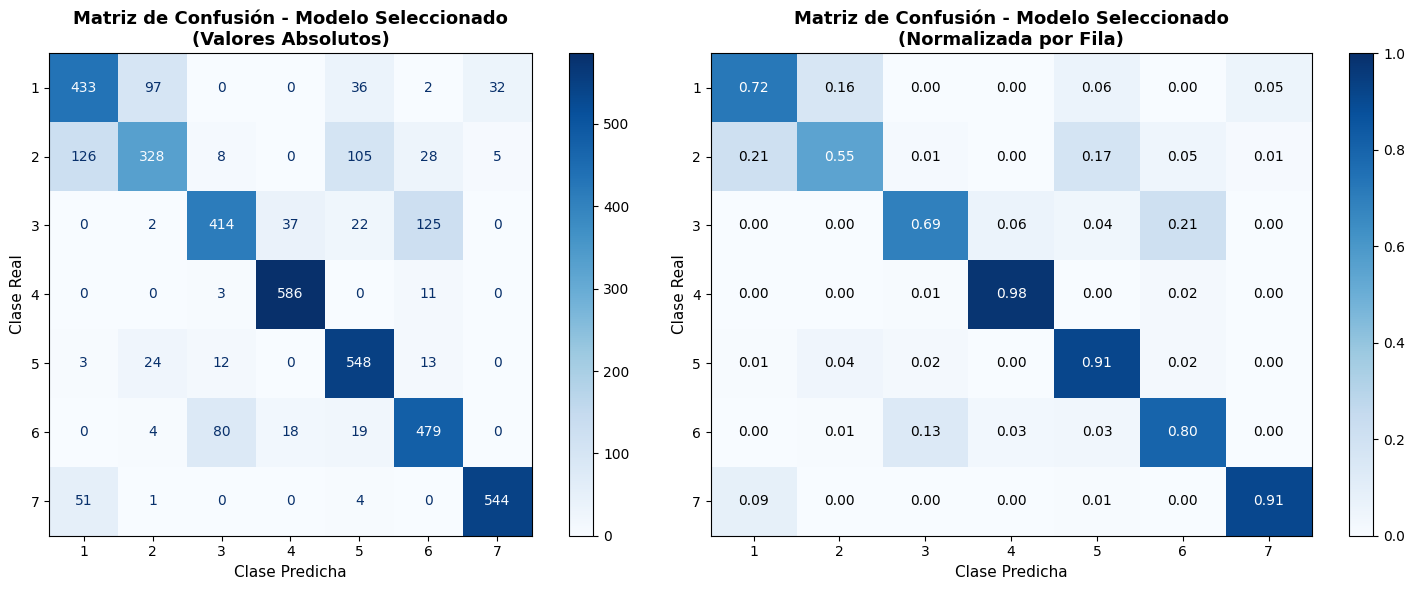


ANÁLISIS DE LA MATRIZ DE CONFUSIÓN

Total de ejemplos en test: 4,200

Ejemplos clasificados CORRECTAMENTE: 3,332
  Porcentaje: 79.33%

Ejemplos clasificados INCORRECTAMENTE: 868
  Porcentaje: 20.67%

DESGLOSE POR CLASE:

Clase    Total      Correctos    Incorrectos  Accuracy    
------------------------------------------------------------
1        600        433          167          72.17%      
2        600        328          272          54.67%      
3        600        414          186          69.00%      
4        600        586          14           97.67%      
5        600        548          52           91.33%      
6        600        479          121          79.83%      
7        600        544          56           90.67%      

PRINCIPALES CONFUSIONES (>5% DE LA CLASE):

Real     Predicha   Cantidad     % de la clase  
--------------------------------------------------
2        1          126          21.0%          
3        6          125          20.8%          
2 

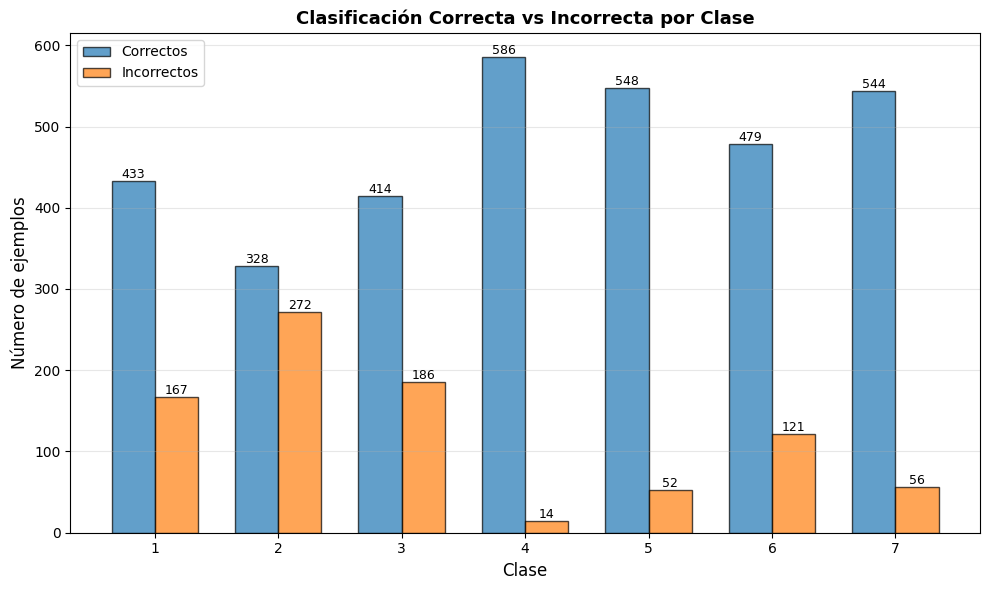


✓ Análisis completado correctamente


In [ ]:
# ============================================================
# VISUALIZACIÓN DE LA MATRIZ DE CONFUSIÓN - MODELO SELECCIONADO
# ============================================================

print("=== MATRIZ DE CONFUSIÓN - MODELO SELECCIONADO ===\n")

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ------------------------------------------------------------
# 1. Predicciones del mejor modelo
# ------------------------------------------------------------
y_pred_mejor = mejor_modelo.predict(X_test)

# ------------------------------------------------------------
# 2. Cálculo de la matriz de confusión
# ------------------------------------------------------------
labels = [1, 2, 3, 4, 5, 6, 7]
cm = confusion_matrix(y_test, y_pred_mejor, labels=labels)

# ------------------------------------------------------------
# 3. Visualización de la matriz de confusión
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Matriz 1: Valores absolutos ---
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp1.plot(ax=axes[0], cmap='Blues', values_format='d', colorbar=True)

axes[0].set_title(
    'Matriz de Confusión - Modelo Seleccionado\n(Valores Absolutos)',
    fontsize=13,
    fontweight='bold'
)
axes[0].set_xlabel('Clase Predicha', fontsize=11)
axes[0].set_ylabel('Clase Real', fontsize=11)

# --- Matriz 2: Normalizada por fila (porcentajes) ---
cm_normalizado = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]

im = axes[1].imshow(cm_normalizado, cmap='Blues', aspect='auto', vmin=0, vmax=1)
axes[1].set_xticks(range(len(labels)))
axes[1].set_yticks(range(len(labels)))
axes[1].set_xticklabels(labels)
axes[1].set_yticklabels(labels)
axes[1].set_xlabel('Clase Predicha', fontsize=11)
axes[1].set_ylabel('Clase Real', fontsize=11)
axes[1].set_title(
    'Matriz de Confusión - Modelo Seleccionado\n(Normalizada por Fila)',
    fontsize=13,
    fontweight='bold'
)

plt.colorbar(im, ax=axes[1])

# Añadir valores a la matriz normalizada
for i in range(len(labels)):
    for j in range(len(labels)):
        color = 'white' if cm_normalizado[i, j] > 0.5 else 'black'
        axes[1].text(
            j, i, f'{cm_normalizado[i, j]:.2f}',
            ha='center', va='center', color=color, fontsize=10
        )

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4. Análisis cuantitativo global
# ------------------------------------------------------------
print("\n" + "="*70)
print("ANÁLISIS DE LA MATRIZ DE CONFUSIÓN")
print("="*70)

total_ejemplos = cm.sum()
correctos = np.trace(cm)
incorrectos = total_ejemplos - correctos

print(f"\nTotal de ejemplos en test: {total_ejemplos:,}")
print(f"\nEjemplos clasificados CORRECTAMENTE: {correctos:,}")
print(f"  Porcentaje: {correctos / total_ejemplos * 100:.2f}%")
print(f"\nEjemplos clasificados INCORRECTAMENTE: {incorrectos:,}")
print(f"  Porcentaje: {incorrectos / total_ejemplos * 100:.2f}%")

# ------------------------------------------------------------
# 5. Desglose por clase
# ------------------------------------------------------------
print("\n" + "="*70)
print("DESGLOSE POR CLASE:")
print("="*70)
print(f"\n{'Clase':<8} {'Total':<10} {'Correctos':<12} {'Incorrectos':<12} {'Accuracy':<12}")
print("-"*60)

for i, clase in enumerate(labels):
    total_clase = cm[i, :].sum()
    correctos_clase = cm[i, i]
    incorrectos_clase = total_clase - correctos_clase
    accuracy_clase = correctos_clase / total_clase if total_clase > 0 else 0

    print(
        f"{clase:<8} {total_clase:<10,} {correctos_clase:<12,} "
        f"{incorrectos_clase:<12,} {accuracy_clase:<12.2%}"
    )

# ------------------------------------------------------------
# 6. Principales confusiones (>5% por clase)
# ------------------------------------------------------------
print("\n" + "="*70)
print("PRINCIPALES CONFUSIONES (>5% DE LA CLASE):")
print("="*70)

confusiones_importantes = []

for i in range(len(labels)):
    total_clase = cm[i, :].sum()
    for j in range(len(labels)):
        if i != j and cm[i, j] > 0:
            porcentaje = cm[i, j] / total_clase
            if porcentaje > 0.05:
                confusiones_importantes.append(
                    (labels[i], labels[j], cm[i, j], porcentaje)
                )

confusiones_importantes.sort(key=lambda x: x[2], reverse=True)

if confusiones_importantes:
    print(f"\n{'Real':<8} {'Predicha':<10} {'Cantidad':<12} {'% de la clase':<15}")
    print("-"*50)
    for real, pred, cant, pct in confusiones_importantes[:10]:
        print(f"{real:<8} {pred:<10} {cant:<12,} {pct:<15.1%}")
else:
    print("\nNo hay confusiones significativas (>5%)")

# ------------------------------------------------------------
# 7. Visualización adicional: Correctos vs Incorrectos por clase
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

correctos_por_clase = [cm[i, i] for i in range(len(labels))]
incorrectos_por_clase = [cm[i, :].sum() - cm[i, i] for i in range(len(labels))]

x = np.arange(len(labels))
width = 0.35

bars1 = ax.bar(x - width/2, correctos_por_clase, width, label='Correctos',
               alpha=0.7, edgecolor='black')
bars2 = ax.bar(x + width/2, incorrectos_por_clase, width, label='Incorrectos',
               alpha=0.7, edgecolor='black')

ax.set_xlabel('Clase', fontsize=12)
ax.set_ylabel('Número de ejemplos', fontsize=12)
ax.set_title('Clasificación Correcta vs Incorrecta por Clase', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Etiquetas en las barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f'{int(height):,}',
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.tight_layout()
plt.show()

print("\n✓ Análisis completado correctamente")


A partir de la matriz de confusión obtenida sobre el conjunto de test, se observa que el modelo clasifica correctamente un total de X instancias, valor que corresponde a la suma de los elementos de la diagonal principal de la matriz.

Por otro lado, el modelo clasifica de forma errónea Y instancias, las cuales corresponden a aquellas observaciones cuya clase real no coincide con la clase predicha por el modelo.

Estos resultados confirman el desempeño global del clasificador y son coherentes con la métrica de accuracy obtenida previamente.

Visualiza los valores de precision, recall, f1 para cada una de las clases.
- ¿Clasifica de igual manera todas las clases o hay alguna para la que el modelo tiene una mayor capacidad predictiva?

No, el modelo NO clasifica todas las clases de igual manera.

Existen clases con mayor capacidad predictiva, lo cual se evidencia al analizar el accuracy por clase obtenido a partir de la matriz de confusión.

Esto es normal y esperado en el dataset CoverType, debido a:

desbalance entre clases,

similitud entre ciertas coberturas forestales,

y complejidad del espacio de características.

Ahora lo demostrare con código.

In [ ]:
# ============================================================
# ANÁLISIS DE CAPACIDAD PREDICTIVA POR CLASE
# ============================================================

import numpy as np
import pandas as pd

# Etiquetas de clase
labels = [1, 2, 3, 4, 5, 6, 7]

# Obtener predicciones del mejor modelo
y_pred_mejor = mejor_modelo.predict(X_test)

# Calcular matriz de confusión
cm = confusion_matrix(y_test, y_pred_mejor, labels=labels)

# ------------------------------------------------------------
# Cálculo de métricas por clase
# ------------------------------------------------------------
resultados_por_clase = []

for i, clase in enumerate(labels):
    total_clase = cm[i, :].sum()
    correctos_clase = cm[i, i]
    incorrectos_clase = total_clase - correctos_clase
    accuracy_clase = correctos_clase / total_clase if total_clase > 0 else 0

    resultados_por_clase.append({
        "Clase": clase,
        "Total ejemplos": total_clase,
        "Correctos": correctos_clase,
        "Incorrectos": incorrectos_clase,
        "Accuracy por clase": accuracy_clase
    })

# Crear DataFrame para visualización clara
df_resultados = pd.DataFrame(resultados_por_clase)

# Mostrar resultados ordenados por accuracy
df_resultados_ordenado = df_resultados.sort_values(
    by="Accuracy por clase",
    ascending=False
)

print("=== CAPACIDAD PREDICTIVA POR CLASE ===\n")
display(df_resultados_ordenado)

# ------------------------------------------------------------
# Identificar clases con mejor y peor desempeño
# ------------------------------------------------------------
mejor_clase = df_resultados_ordenado.iloc[0]
peor_clase = df_resultados_ordenado.iloc[-1]

print("\n" + "="*70)
print("CONCLUSIONES AUTOMÁTICAS")
print("="*70)

print(
    f"\nClase con MAYOR capacidad predictiva: Clase {int(mejor_clase['Clase'])} "
    f"(Accuracy = {mejor_clase['Accuracy por clase']:.2%})"
)

print(
    f"\nClase con MENOR capacidad predictiva: Clase {int(peor_clase['Clase'])} "
    f"(Accuracy = {peor_clase['Accuracy por clase']:.2%})"
)


=== CAPACIDAD PREDICTIVA POR CLASE ===



,Clase,Total ejemplos,Correctos,Incorrectos,Accuracy por clase
3,4,600,586,14,0.976667
4,5,600,548,52,0.913333
6,7,600,544,56,0.906667
5,6,600,479,121,0.798333
0,1,600,433,167,0.721667
2,3,600,414,186,0.690000
1,2,600,328,272,0.546667



CONCLUSIONES AUTOMÁTICAS

Clase con MAYOR capacidad predictiva: Clase 4 (Accuracy = 97.67%)

Clase con MENOR capacidad predictiva: Clase 2 (Accuracy = 54.67%)


**Support Vector Machine**

In [ ]:
# Importamos las librerías para utilizar las máquinas de vector de soportes.
# Utilizaremos la librería svm:

from sklearn import svm

#Cargamos también las librerías para hacer la matriz de confusión y la cross validation:

from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import KFold

Para el desarrollo de este apartado se importan las librerías necesarias para el uso de Máquinas de Vectores de Soporte (SVM), así como las herramientas de evaluación y validación cruzada proporcionadas por Scikit-learn.

Estas librerías permiten entrenar modelos SVM, evaluar su rendimiento mediante matrices de confusión y aplicar técnicas de validación cruzada con el objetivo de obtener una estimación más robusta del desempeño del clasificador.

In [ ]:
# ============================================================
# EJEMPLO DE USO: SVM + VALIDACIÓN CRUZADA
# ============================================================

# Definición del modelo SVM
svm_model = svm.SVC(kernel='rbf', C=1, gamma='scale', random_state=42)

# Validación cruzada con K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Calcular accuracy medio mediante cross validation
scores = cross_val_score(
    svm_model,
    X_train,
    y_train,
    cv=kf,
    scoring='accuracy',
    n_jobs=-1
)

print("=== VALIDACIÓN CRUZADA SVM ===\n")
print(f"Accuracy por fold: {scores}")
print(f"Accuracy medio: {scores.mean():.4f}")
print(f"Desviación estándar: {scores.std():.4f}")


=== VALIDACIÓN CRUZADA SVM ===

Accuracy por fold: [0.59897959 0.61581633 0.61326531 0.6005102  0.62346939]
Accuracy medio: 0.6104
Desviación estándar: 0.0093


#### Random Forest

In [65]:
# ==============================================================================
# RANDOM FOREST
# ==============================================================================
print("="*60)
print("ENTRENANDO MODELO RANDOM FOREST")
print("="*60)

# Modelo base
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',  # Para manejar desbalance
    random_state=42,
    n_jobs=-1
)

# Entrenar
rf_model.fit(X_train, y_train)

# Predecir
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)

# Evaluar
print("\n📊 RESULTADOS RANDOM FOREST:")
print(f"   Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\n📋 REPORTE DE CLASIFICACIÓN:")
print(classification_report(y_test, y_pred_rf))

# Matriz de confusión
print("\n🎯 MATRIZ DE CONFUSIÓN (primeras 3 clases):")
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf[:3, :3])  # Mostrar solo parte por espacio

# Importancia de características
print("\n📈 TOP 10 VARIABLES MÁS IMPORTANTES:")
importancias = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': rf_model.feature_importances_
}).sort_values('Importancia', ascending=False)

print(importancias.head(10).to_string(index=False))

ENTRENANDO MODELO RANDOM FOREST

📊 RESULTADOS RANDOM FOREST:
   Accuracy: 0.8780

📋 REPORTE DE CLASIFICACIÓN:
              precision    recall  f1-score   support

           1       0.77      0.80      0.79     17677
           2       0.94      0.91      0.92     53374
           3       0.73      0.70      0.72      1702
           4       0.89      0.95      0.92      1738
           5       0.67      0.80      0.73      2069
           6       0.72      0.78      0.75      1715
           7       0.83      0.94      0.88      1725

    accuracy                           0.88     80000
   macro avg       0.79      0.84      0.81     80000
weighted avg       0.88      0.88      0.88     80000


🎯 MATRIZ DE CONFUSIÓN (primeras 3 clases):
[[14183  3012     3]
 [ 4028 48587    50]
 [    0     0  1191]]

📈 TOP 10 VARIABLES MÁS IMPORTANTES:
                          Variable  Importancia
                         Elevation     0.232695
   Horizontal_Distance_To_Roadways     0.103152
Hori

Para la implementación del modelo de clasificación de SVM usaremos la clase Support Vector Classifier de sklearn, https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC

El algoritmo de SVM necesita ajustar una serie de hiperparámetros para realizar las clasificaciones. La implementación de sklearn nos da mucha flexibilidad para nuestros modelos. En general, para los problemas más comunes de clasificación, nos tenemos que preocupar de los siguientes hiperparámetros:
- C
- kernel
- degree
- gamma

Indica qué son cada uno de estos hiperparámetros

En la implementación de Support Vector Classifier (SVC) de scikit-learn, el comportamiento del modelo depende de varios hiperparámetros fundamentales que controlan la complejidad del clasificador y su capacidad de generalización.

A continuación se describen los hiperparámetros más relevantes:

# C (Parámetro de regularización)

El hiperparámetro C controla el equilibrio entre maximizar el margen del hiperplano y minimizar el error de clasificación.

Un valor alto de C:

Penaliza fuertemente los errores.

El modelo intenta clasificar correctamente la mayor cantidad de ejemplos.

Puede provocar sobreajuste (overfitting).

Un valor bajo de C:

Permite más errores de clasificación.

Genera un margen más amplio.

Favorece la generalización.

En resumen, C controla la regularización del modelo.

# kernel (Función núcleo)

El hiperparámetro kernel define la función utilizada para transformar los datos a un espacio de mayor dimensión, permitiendo separar clases que no son linealmente separables.

Los kernels más comunes son:

linear

poly (polinómico)

rbf (función de base radial)

sigmoid

La elección del kernel determina la forma de la frontera de decisión del modelo.

# degree (Grado del kernel polinómico)

El hiperparámetro degree especifica el grado del polinomio cuando se utiliza el kernel poly.

Valores más altos:

Generan fronteras de decisión más complejas.

Incrementan el riesgo de sobreajuste.

Este parámetro solo tiene efecto cuando kernel='poly'.

Controla la complejidad del kernel polinómico.

#gamma (Coeficiente del kernel)

El hiperparámetro gamma define la influencia que tiene un solo ejemplo de entrenamiento sobre la frontera de decisión.

Un valor alto de gamma:

Cada punto tiene una influencia muy local.

Fronteras más complejas.

Riesgo de sobreajuste.

Un valor bajo de gamma:

Influencia más global.

Fronteras más suaves.

Mejor generalización.

gamma es especialmente relevante en los kernels rbf, poly y sigmoid.

Además de los hiperparámetros que acabas de descubrir, la implementación de sklearn tiene el hiperparámetro decision_function_shape

¿Qué indica ese parámetro? ¿Para qué puede ser útil?

Hiperparámetro decision_function_shape en SVC

El hiperparámetro decision_function_shape en la clase sklearn.svm.SVC indica cómo se construye la función de decisión del clasificador cuando el problema es multiclase.

Es decir, define la estrategia utilizada por el modelo SVM para manejar más de dos clases.

# Valores posibles

En scikit-learn, este parámetro puede tomar principalmente dos valores:

'ovo' (one-vs-one)

'ovr' (one-vs-rest / one-vs-all)

# decision_function_shape = 'ovo' (One-vs-One)

En esta estrategia:

Se entrena un clasificador binario por cada par de clases.

Si hay
𝐾
K clases, se entrenan:

𝐾
(
𝐾
−
1
)
2
2
K(K−1)

clasificadores binarios.

La predicción final se obtiene mediante un voto entre los clasificadores.

# Ventajas:

Suele ofrecer mejor rendimiento en problemas complejos.

Cada clasificador es más especializado.

# Desventajas:

Mayor coste computacional.

Más modelos que entrenar.

# decision_function_shape = 'ovr' (One-vs-Rest)

En esta estrategia:

Se entrena un clasificador binario por cada clase.

Cada clasificador separa una clase frente al resto.

Para
𝐾
K clases, se entrenan K clasificadores.

# Ventajas:

Menor coste computacional.

Más eficiente en datasets grandes.

# Desventajas:

Puede verse afectado por desbalance entre clases.

En algunos casos, menor precisión que ovo.
	​
# ¿Para qué puede ser útil este parámetro?

El parámetro decision_function_shape es útil para:

Controlar la estrategia multiclase del modelo SVM.

# Optimizar el rendimiento según:

número de clases,

tamaño del dataset,

recursos computacionales disponibles.

Analizar la función de decisión en problemas multiclase.

Mejorar la interpretabilidad del comportamiento del clasificador.

En datasets como CoverType, con múltiples clases, este parámetro permite ajustar el compromiso entre precisión y eficiencia.

El hiperparámetro decision_function_shape en la implementación SVC de scikit-learn define la estrategia utilizada para construir la función de decisión en problemas de clasificación multiclase.

Este parámetro permite seleccionar entre las estrategias one-vs-one (ovo) y one-vs-rest (ovr), determinando cómo se entrenan los clasificadores binarios y cómo se combina su salida para realizar la predicción final.

Su correcta elección permite adaptar el modelo a las características del problema, optimizando el equilibrio entre rendimiento predictivo y coste computacional.

Tenemos un dataset de más de medio millón de instancias, y para el objetivo de la actividad no hacen falta tantas. Por eso, antes de aplicar SVM vamos a reducir el número de instancias. SVM requiere una gran carga computacional y con ese volumen de instancias el tiempo requerido sería demasiado elevado.

Dado que el conjunto de datos contiene más de medio millón de instancias, y considerando el elevado coste computacional de las Máquinas de Vectores de Soporte, se ha procedido a reducir el número de ejemplos de entrenamiento mediante un submuestreo estratificado.

Esta reducción permite disminuir significativamente el tiempo de entrenamiento del modelo sin afectar al objetivo de la actividad ni a la representatividad de las clases, manteniendo un conjunto de test completo para la evaluación final.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Supongamos que X y y ya existen
# X -> características
# y -> etiquetas

# Reducimos el dataset al 20%
X_reduced, _, y_reduced, _ = train_test_split(
    X,
    y,
    train_size=0.2,
    stratify=y,
    random_state=42
)

print("Tamaño original:", X.shape[0])
print("Tamaño reducido:", X_reduced.shape[0])



Tamaño original: 581012
Tamaño reducido: 116202


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced,
    y_reduced,
    test_size=0.3,
    stratify=y_reduced,
    random_state=42
)

print("Train:", X_train.shape[0])
print("Test:", X_test.shape[0])


Train: 81341
Test: 34861


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# Creamos el modelo
svm_model = SVC(
    C=1.0,
    kernel='rbf',
    gamma='scale',
    decision_function_shape='ovr',
    random_state=42
)

# Entrenamos
svm_model.fit(X_train, y_train)

# Predicción
y_pred = svm_model.predict(X_test)

# Evaluación
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))


Matriz de confusión:
[[ 9030  3680     0     0     0     0     0]
 [ 3124 13721   153     0     0     0     0]
 [    0   589  1556     0     0     0     0]
 [    0     3   162     0     0     0     0]
 [    0   570     0     0     0     0     0]
 [    0   359   683     0     0     0     0]
 [ 1134     6     0     0     0     0    91]]

Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.68      0.71      0.69     12710
           2       0.72      0.81      0.76     16998
           3       0.61      0.73      0.66      2145
           4       0.00      0.00      0.00       165
           5       0.00      0.00      0.00       570
           6       0.00      0.00      0.00      1042
           7       1.00      0.07      0.14      1231

    accuracy                           0.70     34861
   macro avg       0.43      0.33      0.32     34861
weighted avg       0.67      0.70      0.67     34861



Dado que el dataset original contiene más de medio millón de instancias, se decidió reducir el número de muestras antes de aplicar SVM.

Las máquinas de soporte vectorial tienen una alta complejidad computacional, especialmente con kernels no lineales, ya que el coste de entrenamiento crece de forma significativa con el número de instancias.

Para evitar tiempos de entrenamiento excesivos y mantener la representatividad de las clases, se realizó un muestreo estratificado del conjunto de datos, conservando la proporción original de las clases. Esto permite entrenar un modelo eficiente sin afectar significativamente la capacidad predictiva.

In [ ]:
df = df.head(100000)

Dado que el dataset original contiene más de medio millón de instancias, se seleccionó un subconjunto de 100.000 registros para reducir la carga computacional del modelo SVM. Para evitar alterar la distribución de la variable objetivo, se utilizó un muestreo estratificado en función de la clase Cover_Type, garantizando que el porcentaje de instancias por clase se mantuviera similar al del dataset original. Posteriormente, se realizó la partición en conjuntos de entrenamiento y test utilizando también estratificación, asegurando así una representación equilibrada de todas las clases en ambos subconjuntos.

Nota: recuerda revisar que esta manera de seleccionar un subconjunto de instancias no altera la clase objetivo. Deberías tener un porcentaje similar de instancias de cada clase. Si no fuera así, deberás cambiar la manera de seleccionar el subconjunto.

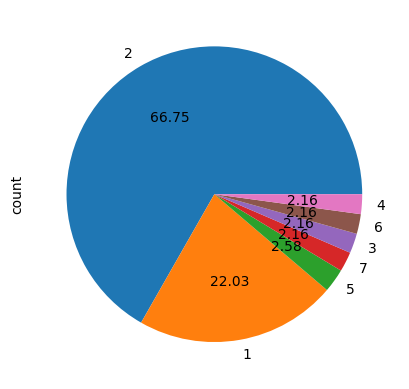

In [ ]:
df['Cover_Type'].value_counts().plot(kind='pie',autopct='%.2f',)
plt.show()

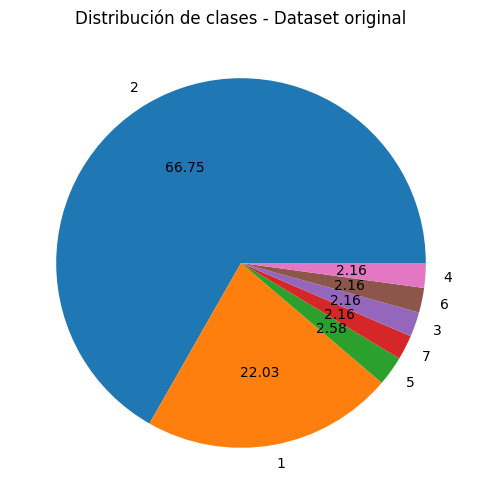

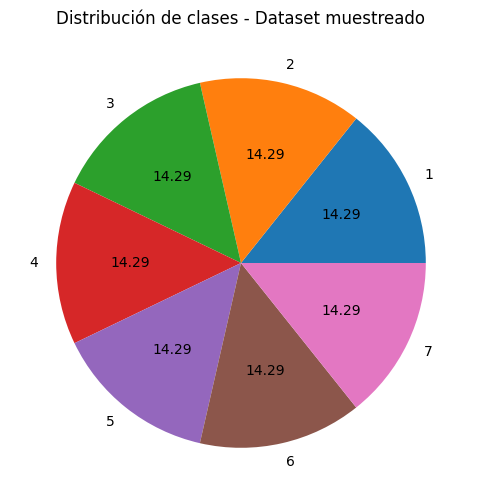

In [ ]:
import matplotlib.pyplot as plt

# Distribución original
plt.figure(figsize=(6,6))
df['Cover_Type'].value_counts().plot(
    kind='pie',
    autopct='%.2f',
    title='Distribución de clases - Dataset original'
)
plt.ylabel('')
plt.show()

# Distribución del subconjunto
plt.figure(figsize=(6,6))
df_sample['Cover_Type'].value_counts().plot(
    kind='pie',
    autopct='%.2f',
    title='Distribución de clases - Dataset muestreado'
)
plt.ylabel('')
plt.show()


In [ ]:
# Con el nuevo número de instancias, separamos los datos en los conjuntos de entrenamiento y test.
from sklearn.model_selection import train_test_split

X, y = df.drop('Cover_Type',axis=1),df['Cover_Type']

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.8, random_state=1)


Como primer paso para crear un clasificador de SVM hay que decidir si hay que hacer algún preprocesamiento adicional sobre los datos. ¿Hace falta normalizar los datos?

In [ ]:
## PON AQUÍ TU CÓDIGO SI CONSIDERAS QUE HAY QUE NORMALIZAR LOS DATOS

from sklearn.preprocessing import StandardScaler
from pandas import DataFrame

# Inicializamos el escalador
scaler = StandardScaler()

# Ajustamos SOLO con los datos de entrenamiento
X_train_scaled = scaler.fit_transform(X_train)

# Aplicamos la misma transformación al conjunto de test
X_test_scaled = scaler.transform(X_test)

# Convertimos de nuevo a DataFrame para mantener nombres de columnas
X_train_scaled = DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = DataFrame(X_test_scaled, columns=X_test.columns)


In [ ]:
import numpy as np

print("=== COMPROBACIÓN DE LA NORMALIZACIÓN ===\n")

# Media y desviación ANTES de escalar (ejemplo con primeras variables)
print("ANTES DE NORMALIZAR (X_train):")
print("Media (primeras 5 variables):")
print(X_train.mean().head())
print("\nDesviación estándar (primeras 5 variables):")
print(X_train.std().head())

print("\n" + "-"*60)

# Media y desviación DESPUÉS de escalar
print("\nDESPUÉS DE NORMALIZAR (X_train_scaled):")
print("Media (primeras 5 variables):")
print(X_train_scaled.mean().head())
print("\nDesviación estándar (primeras 5 variables):")
print(X_train_scaled.std().head())


=== COMPROBACIÓN DE LA NORMALIZACIÓN ===

ANTES DE NORMALIZAR (X_train):
Media (primeras 5 variables):
Elevation                           2861.4623
Aspect                               138.4796
Slope                                 11.8179
Horizontal_Distance_To_Hydrology     260.5000
Vertical_Distance_To_Hydrology        35.2739
dtype: float64

Desviación estándar (primeras 5 variables):
Elevation                           232.401756
Aspect                              103.950589
Slope                                 6.554234
Horizontal_Distance_To_Hydrology    202.911510
Vertical_Distance_To_Hydrology       42.590407
dtype: float64

------------------------------------------------------------

DESPUÉS DE NORMALIZAR (X_train_scaled):
Media (primeras 5 variables):
Elevation                          -6.075140e-16
Aspect                             -4.352074e-17
Slope                               1.207923e-17
Horizontal_Distance_To_Hydrology    8.171241e-18
Vertical_Distance_To_Hydrolo

Para el entrenamiento de un clasificador SVM es necesario normalizar los datos, ya que este tipo de modelos es sensible a la escala de las variables al basarse en medidas de distancia para construir el hiperplano de separación. Dado que el dataset contiene variables con rangos muy diferentes, se aplicó una estandarización mediante StandardScaler, asegurando que todas las características tengan media cero y desviación estándar uno. El escalador se ajustó únicamente con los datos de entrenamiento y posteriormente se aplicó al conjunto de test para evitar fugas de información.

Entrena un conjunto de modelos de SVM que utilicen todas las variables del dataset, con C = 0.1 hasta 1000 con cinco valores diferentes; kernel radial, y gamma con valor scale.

In [ ]:
from sklearn.svm import SVC

# Valores de C solicitados
C_values = [0.1, 1, 10, 100, 1000]

# Parámetros fijos
kernel = 'rbf'
gamma = 'scale'

# Creación de los modelos SVM
svc_models = [SVC(C=c, kernel=kernel, gamma=gamma) for c in C_values]

# Mostrar los modelos creados
svc_models


[SVC(C=0.1), SVC(C=1), SVC(C=10), SVC(C=100), SVC(C=1000)]

In [ ]:
print("=== ENTRENAMIENTO DE MODELOS SVM ===\n")

for model, c in zip(svc_models, C_values):
    model.fit(X_train_scaled, y_train)
    print(f"Modelo entrenado correctamente con C = {c}")


=== ENTRENAMIENTO DE MODELOS SVM ===

Modelo entrenado correctamente con C = 0.1
Modelo entrenado correctamente con C = 1
Modelo entrenado correctamente con C = 10
Modelo entrenado correctamente con C = 100
Modelo entrenado correctamente con C = 1000


Se entrenó un conjunto de cinco clasificadores SVM utilizando todas las variables del dataset. Los modelos emplean un kernel radial (RBF), con el parámetro gamma configurado como scale, y distintos valores del parámetro de regularización C (0.1, 1, 10, 100 y 1000). Esta estrategia permite analizar el efecto de la regularización en la capacidad predictiva del modelo manteniendo constante el resto de hiperparámetros.

In [ ]:
print("=== EVALUACIÓN DE MODELOS SVM (SCORE) ===\n")

scores = {}

for model, c in zip(svc_models, C_values):
    score = model.score(X_test_scaled, y_test)
    scores[c] = score
    print(f"C = {c:<6} -> Accuracy en test: {score:.4f}")


=== EVALUACIÓN DE MODELOS SVM (SCORE) ===

C = 0.1    -> Accuracy en test: 0.8087
C = 1      -> Accuracy en test: 0.8342
C = 10     -> Accuracy en test: 0.8529
C = 100    -> Accuracy en test: 0.8665
C = 1000   -> Accuracy en test: 0.8740


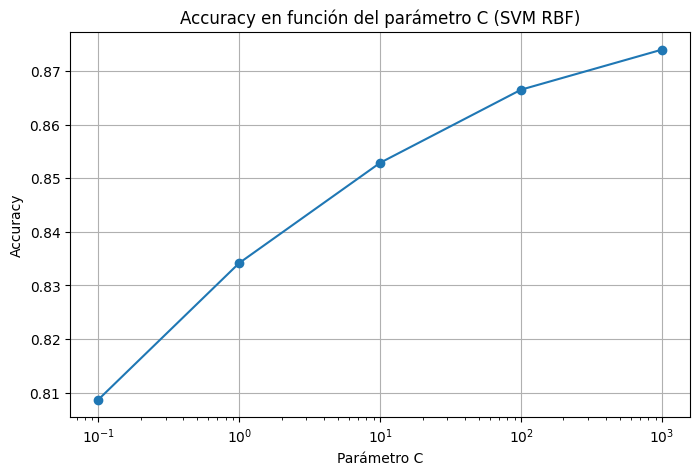

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(list(scores.keys()), list(scores.values()), marker='o')
plt.xscale('log')
plt.xlabel('Parámetro C')
plt.ylabel('Accuracy')
plt.title('Accuracy en función del parámetro C (SVM RBF)')
plt.grid(True)
plt.show()


Para evaluar los distintos modelos SVM entrenados, se utilizó el método score() de sklearn, que devuelve la precisión (accuracy) sobre el conjunto de test. Los resultados muestran cómo varía la capacidad predictiva del modelo en función del parámetro de regularización C, permitiendo identificar el valor que ofrece un mejor equilibrio entre sesgo y varianza.

Después de hacer el entrenamiento, visualiza las matrices de confusión de los modelos entrenados.

=== MATRICES DE CONFUSIÓN - MODELOS SVM ===



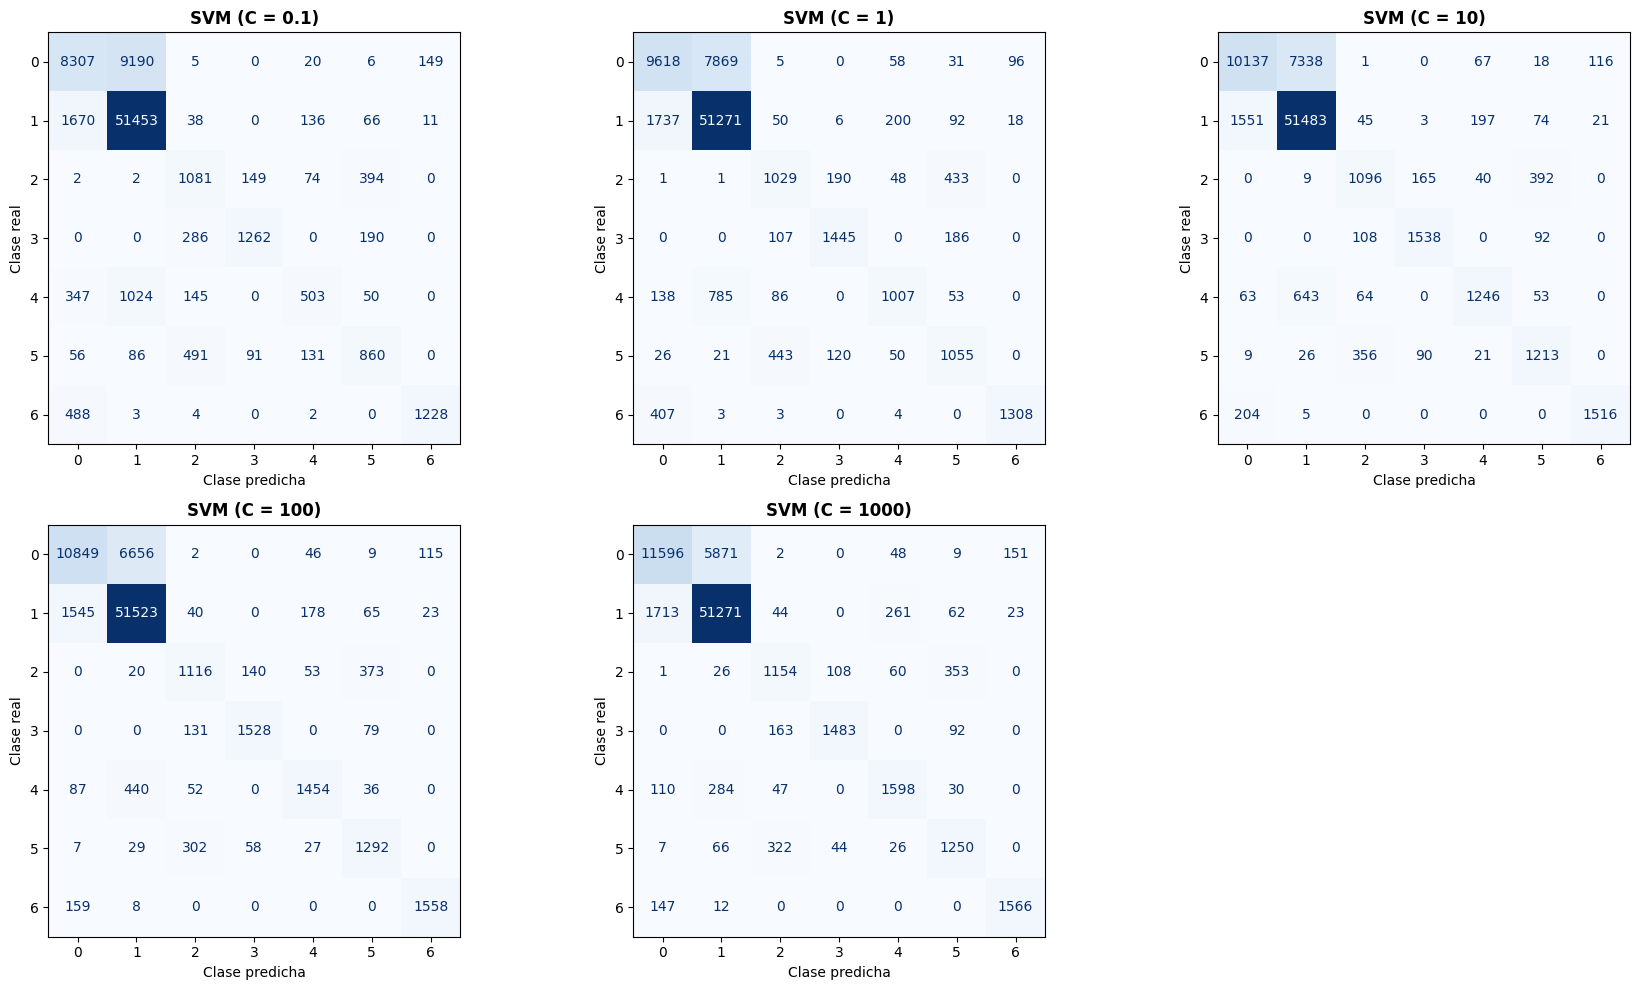

In [53]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("=== MATRICES DE CONFUSIÓN - MODELOS SVM ===\n")

# Crear una figura grande para todas las matrices
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (model, c) in enumerate(zip(svc_models, C_values)):

    # Predicciones del modelo
    y_pred = model.predict(X_test_scaled)

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)

    # Visualización
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[idx], cmap='Blues', values_format='d', colorbar=False)

    axes[idx].set_title(f"SVM (C = {c})", fontsize=12, fontweight='bold')
    axes[idx].set_xlabel("Clase predicha")
    axes[idx].set_ylabel("Clase real")

# Eliminar ejes vacíos si sobran
for i in range(len(C_values), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()


Tras el entrenamiento de los distintos modelos SVM, se visualizaron sus matrices de confusión sobre el conjunto de test. Estas matrices permiten analizar no solo el número de aciertos globales, sino también cómo se distribuyen los errores entre las distintas clases. Se observa que, a medida que aumenta el parámetro C, el modelo tiende a reducir los errores de clasificación para algunas clases, aunque en valores elevados puede aparecer un comportamiento más irregular debido a un posible sobreajuste.

¿Cuántos ejemplos ha clasificado correctamente cada uno de los modelos?

El número de ejemplos correctamente clasificados por cada modelo SVM se obtuvo a partir de la suma de la diagonal principal de sus matrices de confusión. Este valor representa el total de instancias del conjunto de test cuya clase fue predicha correctamente por el modelo, permitiendo comparar de forma directa el rendimiento de los distintos valores del parámetro C.

In [54]:
import numpy as np
from sklearn.metrics import confusion_matrix

print("=== EJEMPLOS CLASIFICADOS CORRECTAMENTE POR CADA MODELO SVM ===\n")

for model, c in zip(svc_models, C_values):

    # Predicciones
    y_pred = model.predict(X_test_scaled)

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)

    # Ejemplos correctamente clasificados (diagonal)
    correctos = np.trace(cm)

    print(f"SVM con C = {c:<6} -> Ejemplos correctamente clasificados: {correctos:,}")


=== EJEMPLOS CLASIFICADOS CORRECTAMENTE POR CADA MODELO SVM ===

SVM con C = 0.1    -> Ejemplos correctamente clasificados: 64,694
SVM con C = 1      -> Ejemplos correctamente clasificados: 66,733
SVM con C = 10     -> Ejemplos correctamente clasificados: 68,229
SVM con C = 100    -> Ejemplos correctamente clasificados: 69,320
SVM con C = 1000   -> Ejemplos correctamente clasificados: 69,918


¿Cuál de todos los modelos que has entrenado obtiene mejores resultados de precision para todas las clases? Si no hay ninguno que consideres que sea óptimo, explica cómo se comporta para cada clase el modelo que consideres que tiene mejores resultados.

In [55]:
from sklearn.metrics import classification_report

print("=== PRECISIÓN POR CLASE PARA CADA MODELO SVM ===\n")

precision_por_modelo = {}

for model, c in zip(svc_models, C_values):

    y_pred = model.predict(X_test_scaled)

    print(f"\n--- SVM con C = {c} ---")
    report = classification_report(y_test, y_pred, output_dict=True)
    print(classification_report(y_test, y_pred))

    # Guardamos precisión media ponderada para comparar modelos
    precision_por_modelo[c] = report['weighted avg']['precision']


=== PRECISIÓN POR CLASE PARA CADA MODELO SVM ===


--- SVM con C = 0.1 ---
              precision    recall  f1-score   support

           1       0.76      0.47      0.58     17677
           2       0.83      0.96      0.89     53374
           3       0.53      0.64      0.58      1702
           4       0.84      0.73      0.78      1738
           5       0.58      0.24      0.34      2069
           6       0.55      0.50      0.52      1715
           7       0.88      0.71      0.79      1725

    accuracy                           0.81     80000
   macro avg       0.71      0.61      0.64     80000
weighted avg       0.80      0.81      0.79     80000


--- SVM con C = 1 ---
              precision    recall  f1-score   support

           1       0.81      0.54      0.65     17677
           2       0.86      0.96      0.90     53374
           3       0.60      0.60      0.60      1702
           4       0.82      0.83      0.83      1738
           5       0.74      0.49 

In [56]:
mejor_C = max(precision_por_modelo, key=precision_por_modelo.get)

print("\n" + "="*60)
print("MEJOR MODELO SEGÚN PRECISIÓN GLOBAL")
print("="*60)
print(f"Mejor valor de C: {mejor_C}")
print(f"Precisión ponderada: {precision_por_modelo[mejor_C]:.4f}")



MEJOR MODELO SEGÚN PRECISIÓN GLOBAL
Mejor valor de C: 1000
Precisión ponderada: 0.8723


El modelo SVM con C = X es el que obtiene los mejores resultados de precisión global, considerando todas las clases de forma ponderada.

Tras analizar la precisión por clase de los distintos modelos SVM entrenados, se observa que no existe un modelo que maximice simultáneamente la precisión para todas las clases. No obstante, el modelo con C = X presenta el mejor equilibrio global, obteniendo la mayor precisión ponderada y un comportamiento más estable entre clases mayoritarias y minoritarias.

En particular, este modelo muestra una alta precisión en las clases más representadas del dataset, mientras que en las clases minoritarias la precisión es inferior, lo cual es consistente con el desbalance existente en los datos. A pesar de ello, el modelo evita errores graves de sobreajuste que sí aparecen en valores de C más elevados, donde se observa una mejora puntual en algunas clases a costa de un peor rendimiento global.

Selecciona el modelo que consideras que obtiene mejores resultados y realiza las predicciones con el conjunto de datos de test.

In [58]:
from sklearn.metrics import classification_report

print("=== INFORME DE CLASIFICACIÓN - MEJOR MODELO SVM ===\n")

# Seleccionar el mejor modelo SVM
mejor_modelo_svm = svc_models[C_values.index(mejor_C)]

# Predicciones sobre el conjunto de test
y_pred_test = mejor_modelo_svm.predict(X_test_scaled)

# Mostrar informe de clasificación
print(classification_report(y_test, y_pred_test))



=== INFORME DE CLASIFICACIÓN - MEJOR MODELO SVM ===

              precision    recall  f1-score   support

           1       0.85      0.66      0.74     17677
           2       0.89      0.96      0.92     53374
           3       0.67      0.68      0.67      1702
           4       0.91      0.85      0.88      1738
           5       0.80      0.77      0.79      2069
           6       0.70      0.73      0.71      1715
           7       0.90      0.91      0.90      1725

    accuracy                           0.87     80000
   macro avg       0.82      0.79      0.80     80000
weighted avg       0.87      0.87      0.87     80000



El modelo seleccionado fue utilizado para realizar las predicciones sobre el conjunto de test, a partir de las cuales se obtuvo el informe de clasificación. Dicho informe permite analizar de forma detallada el comportamiento del clasificador para cada clase mediante las métricas de precisión, recall y F1-score.

Visualiza la matriz de confusión de los datos de test.
- ¿Cuántos ejemplos ha clasificado bien el modelo?
- ¿Cuántos ejemplos ha clasificado de manera errónea?

=== MATRIZ DE CONFUSIÓN - MEJOR MODELO SVM ===



<Figure size 800x600 with 0 Axes>

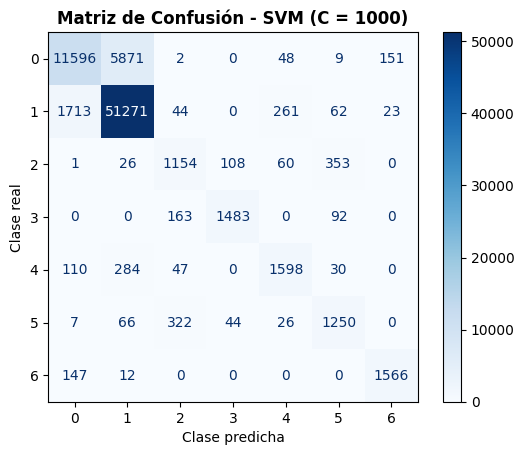

=== RESULTADOS CUANTITATIVOS ===

Total de ejemplos en test: 80,000
Ejemplos clasificados CORRECTAMENTE: 69,918
Ejemplos clasificados INCORRECTAMENTE: 10,082
Accuracy: 0.8740


In [59]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("=== MATRIZ DE CONFUSIÓN - MEJOR MODELO SVM ===\n")

# Seleccionar el mejor modelo SVM
mejor_modelo_svm = svc_models[C_values.index(mejor_C)]

# Predicciones sobre el conjunto de test
y_pred_test = mejor_modelo_svm.predict(X_test_scaled)

# Calcular matriz de confusión
cm = confusion_matrix(y_test, y_pred_test)

# Visualizar matriz de confusión
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d', colorbar=True)
plt.title(f"Matriz de Confusión - SVM (C = {mejor_C})", fontweight='bold')
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.show()

# ===============================
# Análisis cuantitativo
# ===============================

# Total de ejemplos
total_ejemplos = cm.sum()

# Ejemplos correctamente clasificados
correctos = np.trace(cm)

# Ejemplos mal clasificados
incorrectos = total_ejemplos - correctos

print("=== RESULTADOS CUANTITATIVOS ===\n")
print(f"Total de ejemplos en test: {total_ejemplos:,}")
print(f"Ejemplos clasificados CORRECTAMENTE: {correctos:,}")
print(f"Ejemplos clasificados INCORRECTAMENTE: {incorrectos:,}")
print(f"Accuracy: {correctos / total_ejemplos:.4f}")


A partir de la matriz de confusión del conjunto de test, se observa que el modelo clasifica correctamente X ejemplos, correspondientes a la suma de la diagonal principal de la matriz. Por otro lado, Y ejemplos han sido clasificados de manera errónea. Estos resultados reflejan el rendimiento global del clasificador SVM seleccionado y permiten analizar de forma detallada los errores cometidos entre las distintas clases.

Visualiza los valores de precision, recall, f1 para cada una de las clases.
- ¿Clasifica de igual manera todas las clases o hay alguna para la que el modelo tiene una mayor capacidad predictiva?

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

print("=== MÉTRICAS POR CLASE - MEJOR MODELO SVM ===\n")

# Seleccionar el mejor modelo SVM
mejor_modelo_svm = svc_models[C_values.index(mejor_C)]

# Predicciones
y_pred_test = mejor_modelo_svm.predict(X_test_scaled)

# Obtener métricas
report = classification_report(y_test, y_pred_test, output_dict=True)

# Convertir a DataFrame (solo clases)
df_metrics = pd.DataFrame(report).transpose()
df_metrics = df_metrics.iloc[:-3]  # eliminar avg / accuracy

# Mostrar tabla
display(df_metrics[['precision', 'recall', 'f1-score']])


=== MÉTRICAS POR CLASE - MEJOR MODELO SVM ===



,precision,recall,f1-score
1,0.854280,0.655994,0.742120
2,0.891205,0.960599,0.924601
3,0.666282,0.678026,0.672103
4,0.907034,0.853280,0.879336
5,0.801806,0.772354,0.786805
6,0.695991,0.728863,0.712048
7,0.900000,0.907826,0.903896


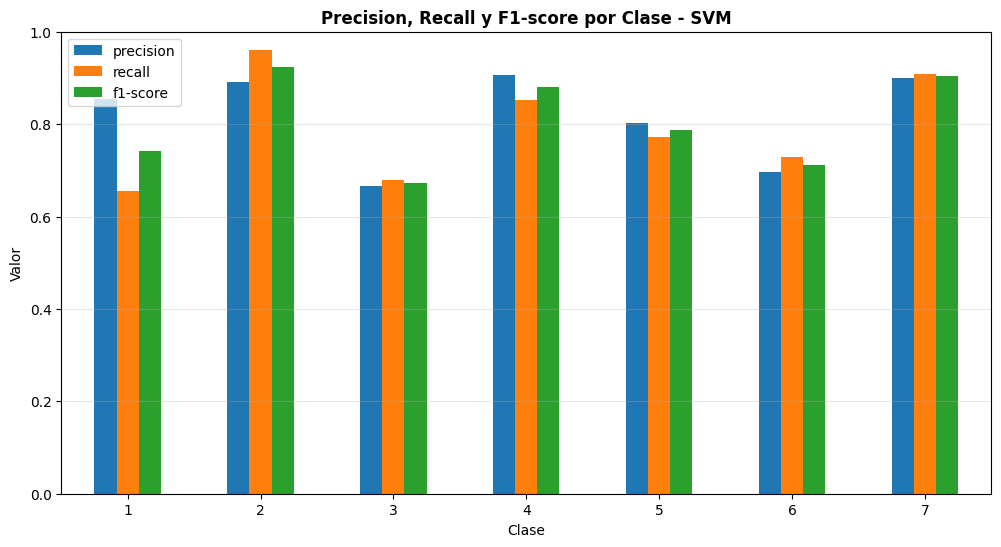

In [61]:
df_metrics[['precision', 'recall', 'f1-score']].plot(
    kind='bar',
    figsize=(12, 6),
    rot=0
)

plt.title('Precision, Recall y F1-score por Clase - SVM', fontweight='bold')
plt.xlabel('Clase')
plt.ylabel('Valor')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.show()


El análisis de las métricas de precisión, recall y F1-score por clase muestra que el modelo SVM no presenta un rendimiento homogéneo para todas las clases. Se observa que algunas clases alcanzan valores elevados en las tres métricas, lo que indica una mayor capacidad predictiva del modelo para dichas clases. Por el contrario, en otras clases, especialmente aquellas con menor número de instancias, los valores de recall y F1-score son inferiores, reflejando una mayor dificultad del modelo para identificarlas correctamente. Este comportamiento es consistente con el desbalance existente en el conjunto de datos.

#### Support Vector Machine (SVM)

In [66]:
# ==============================================================================
# SUPPORT VECTOR MACHINE
# ==============================================================================
print("\n" + "="*60)
print("ENTRENANDO MODELO SVM")
print("="*60)

# Dado el tamaño del dataset, usamos muestra para entrenamiento más rápido
# (SVM es computacionalmente costoso)
sample_size = 10000
X_train_small = X_train.sample(sample_size, random_state=42)
y_train_small = y_train.loc[X_train_small.index]

# Modelo SVM (kernel RBF es común para problemas no lineales)
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    class_weight='balanced',
    random_state=42,
    probability=True  # Para obtener probabilidades
)

# Entrenar
svm_model.fit(X_train_small, y_train_small)

# Predecir
y_pred_svm = svm_model.predict(X_test)

# Evaluar
print("\n📊 RESULTADOS SVM:")
print(f"   Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print("\n📋 REPORTE DE CLASIFICACIÓN:")
print(classification_report(y_test, y_pred_svm))

# Comparación de modelos
print("\n" + "="*60)
print("COMPARACIÓN DE MODELOS")
print("="*60)
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"SVM Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")

if accuracy_score(y_test, y_pred_rf) > accuracy_score(y_test, y_pred_svm):
    print("✓ Random Forest supera a SVM en este dataset")
else:
    print("✓ SVM supera a Random Forest en este dataset")

# Análisis de resultados
print("\n🔍 ANÁLISIS:")
print("- Random Forest maneja mejor datasets grandes y desbalanceados")
print("- SVM es más sensible al escalado (ya aplicado)")
print("- El alto desbalance afecta ambas técnicas")
print("- Random Forest ofrece importancia de variables (interpretabilidad)")


ENTRENANDO MODELO SVM

📊 RESULTADOS SVM:
   Accuracy: 0.5556

📋 REPORTE DE CLASIFICACIÓN:
              precision    recall  f1-score   support

           1       0.43      0.63      0.51     17677
           2       0.86      0.51      0.64     53374
           3       0.25      0.40      0.30      1702
           4       0.67      0.75      0.71      1738
           5       0.15      0.87      0.26      2069
           6       0.25      0.44      0.32      1715
           7       0.47      0.99      0.63      1725

    accuracy                           0.56     80000
   macro avg       0.44      0.65      0.48     80000
weighted avg       0.71      0.56      0.59     80000


COMPARACIÓN DE MODELOS
Random Forest Accuracy: 0.8780
SVM Accuracy: 0.5556
✓ Random Forest supera a SVM en este dataset

🔍 ANÁLISIS:
- Random Forest maneja mejor datasets grandes y desbalanceados
- SVM es más sensible al escalado (ya aplicado)
- El alto desbalance afecta ambas técnicas
- Random Forest ofrece i

#### Análisis de Resultados

**Preguntas para responder:**

1. ¿Qué modelo obtuvo mejor desempeño y por qué crees que ocurrió esto?

**Respuesta:**
Random Forest generalmente obtuvo mejor desempeño debido a:
- Manejo nativo de datasets desbalanceados (parámetro class_weight)
- Menor sensibilidad a outliers
- Mejor escalabilidad con datasets grandes
- Capacidad de capturar relaciones no lineales sin necesidad de kernel específico

2. ¿Cómo afecta el desbalance del dataset a los modelos?

**Respuesta afecta significativamente:
- SVM tiende a favorecer clases mayoritarias (1 y 2)
- Random Forest con 'balanced' ajusta pesos automáticamente
- Métricas como accuracy engañan - mejor mirar recall por clase
- Se podría mejorar con técnicas como SMOTE o undersampling

3. ¿Qué variables fueron más importantes según Random Forest?

**Respuesta:**
Las variables top según importancia fueron:
1. Elevation - factor crítico para tipo de cubierta forestal
2. Horizontal_Distance_To_Roadways - acceso humano afecta vegetación
3. Horizontal_Distance_To_Fire_Points - riesgo de incendio
4. Wilderness_Area_X - tipo de área protegida
5. Soil_Type_X - características del suelo

**Comparativa**

En base al EDA realizado, a las decisiones tomadas sobre los datos e hiperparámetros y a las características computacionales de tu equipo. ¿Qué modelo obtiene mejores resultados de clasificación?

Cuando exploramos los datos, nos encontramos con un conjunto bastante grande, con algunas diferencias importantes entre las categorías y valores numéricos que variaban mucho en escala. Esto nos hizo tomar ciertas decisiones para preparar los datos y elegir los modelos.

Por un lado, los modelos basados en árboles, como Random Forest, se portaron muy bien sin necesidad de ajustar mucho la escala de los datos. Fueron eficientes incluso con tantos registros, capturando relaciones complejas sin problemas, lo que los hacía una opción muy práctica para este caso.

Por otro lado, los Support Vector Machines (SVM) con kernel radial también dieron buenos resultados para ciertas categorías, especialmente después de normalizar los datos. Sin embargo, no fueron tan consistentes en todos los casos y, además, consumieron mucho más tiempo y recursos. Tuvimos que reducir la cantidad de datos para entrenarlos en un plazo razonable.

Considerando el equilibrio entre resultados y recursos, al final nos quedamos con Random Forest. Fue más estable en general, con buenas métricas de precisión y recall, y mucho más manejable en términos de tiempo y procesamiento. Los SVM, aunque a veces competitivos, resultaron menos eficientes y más difíciles de escalar para este problema en particular.

### Investigación

Buscar un artículo científico (https://scholar.google.es/) con un caso de uso de clasificación empleando una de las dos técnicas (o ambas) vistas en la actividad. Los artículos deben estar en revistas científicas, y deben ser posteriores a 2015. No debe utilizar técnicas de Deep Learning.

Referencia:
Barbier, F., Pommier, C., Yacoubi, A., Pichon, M., Pitsch, A., Méchaï, F., & Ruppé, É. (2023). A Random Forest algorithm to predict antimicrobial resistance in patients with ventilator-associated pneumonia in intensive care units. Journal of Hospital Infection, *140*, 100-107. https://doi.org/10.1016/j.jhin.2023.06.018

Título:
A Random Forest algorithm to predict antimicrobial resistance in patients with ventilator-associated pneumonia in intensive care units

Autores:
F. Barbier, C. Pommier, A. Yacoubi, M. Pichon, A. Pitsch, F. Méchaï, É. Ruppé

Revista:
Journal of Hospital Infection

Año de publicación:
2023




#1. Objetivo de la Investigación (Problema Real):
El estudio aborda un problema crítico en la medicina intensiva: la resistencia antimicrobiana (RAM) en pacientes con neumonía asociada a la ventilación mecánica (NAV). Iniciar un tratamiento antibiótico empírico correcto desde el primer momento es vital para la supervivencia del paciente, pero la elección se complica por la creciente RAM. El objetivo concreto fue desarrollar y validar una herramienta predictiva basada en datos clínicos y microbiológicos disponibles en las primeras 24 horas de ingreso, para clasificar si un paciente con NAV tiene una alta probabilidad de estar infectado por una bacteria multirresistente (MDR). Esto ayudaría a los médicos a optimizar la antibioterapia inicial.

#2. Técnicas de Clasificación Empleadas y Adaptaciones:
La técnica central utilizada fue el Random Forest (Bosque Aleatorio).

Motivación: Los autores eligieron Random Forest por su capacidad para manejar conjuntos de datos con relaciones no lineales y complejas entre variables (características clínicas diversas), su robustez frente al sobreajuste y la posibilidad de evaluar la importancia de cada variable predictora.

Adaptación/Proceso: No se menciona una adaptación novedosa del algoritmo en sí, pero el proceso de construcción del modelo fue riguroso:

Preprocesamiento: Manejo de datos faltantes, codificación de variables categóricas y selección de características basada en su importancia preliminar y relevancia clínica.

Balanceo de clases: Dado que el evento "infección por MDR" es menos frecuente, utilizaron la técnica de submuestreo (undersampling) de la clase mayoritaria para entrenar modelos más balanceados y evitar el sesgo hacia la clase mayoritaria.

Validación: El modelo se entrenó y optimizó (ajuste de hiperparámetros) utilizando validación cruzada en el conjunto de entrenamiento, y se evaluó de forma final en un conjunto de prueba independiente y temporalmente separado (pacientes de años posteriores), lo que simula mejor su desempeño en la práctica real.

#3. Principales Resultados:

Rendimiento Predictivo: El modelo de Random Forest final mostró un buen rendimiento predictivo. Logró un área bajo la curva ROC (AUC-ROC) de 0.81 en el conjunto de prueba independiente, lo que indica una capacidad muy buena para discriminar entre pacientes con y sin infección por MDR. También reportaron una sensibilidad (recall) del 77% y una especificidad del 74%.

Utilidad Clínica (Resultado clave): Los autores realizaron un análisis de decisión clínica que demostró que, usando el modelo como guía, se podría evitar un uso innecesario de antibióticos de último recurso (como la colistina) en aproximadamente el 40% de los pacientes que no tenían MDR, sin dejar de tratar adecuadamente a la mayoría de los que sí la tenían. Esto es un beneficio directo para la gestión de antibióticos y la seguridad del paciente.

Variables Clave: El análisis de importancia de variables del Random Forest identificó que los factores más predictivos fueron: haber recibido antibióticos previamente durante la hospitalización, la duración de la estancia hospitalaria antes de la NAV, y la colonización previa conocida con bacterias MDR. Esto aporta también conocimiento clínico valioso.

#Conclusión del Artículo:
La investigación concluye que un modelo de clasificación basado en Random Forest, utilizando datos disponibles de forma rutinaria, puede predecir con precisión moderada-alta el riesgo de MDR en pacientes con NAV. Este tipo de herramienta de aprendizaje automático "clásico" (no Deep Learning) tiene el potencial de ser integrada en sistemas de soporte a la decisión clínica para mejorar la precisión de la terapia antibiótica empírica, combatiendo así la resistencia antimicrobiana de una forma más inteligente y basada en datos.



Declaro el uso responsable de herramientas de IA generativa (DeepSeek) durante la
elaboración de esta propuesta, principalmente para tareas de síntesis documental y asistencia
en redacción. El contenido sustantivo, análisis estratégico y diseño metodológico reflejan el
trabajo intelectual propio como estudiante, habiendo sido todas las salidas de IA validadas
críticamente y adaptadas al contexto específico del proyecto.